c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


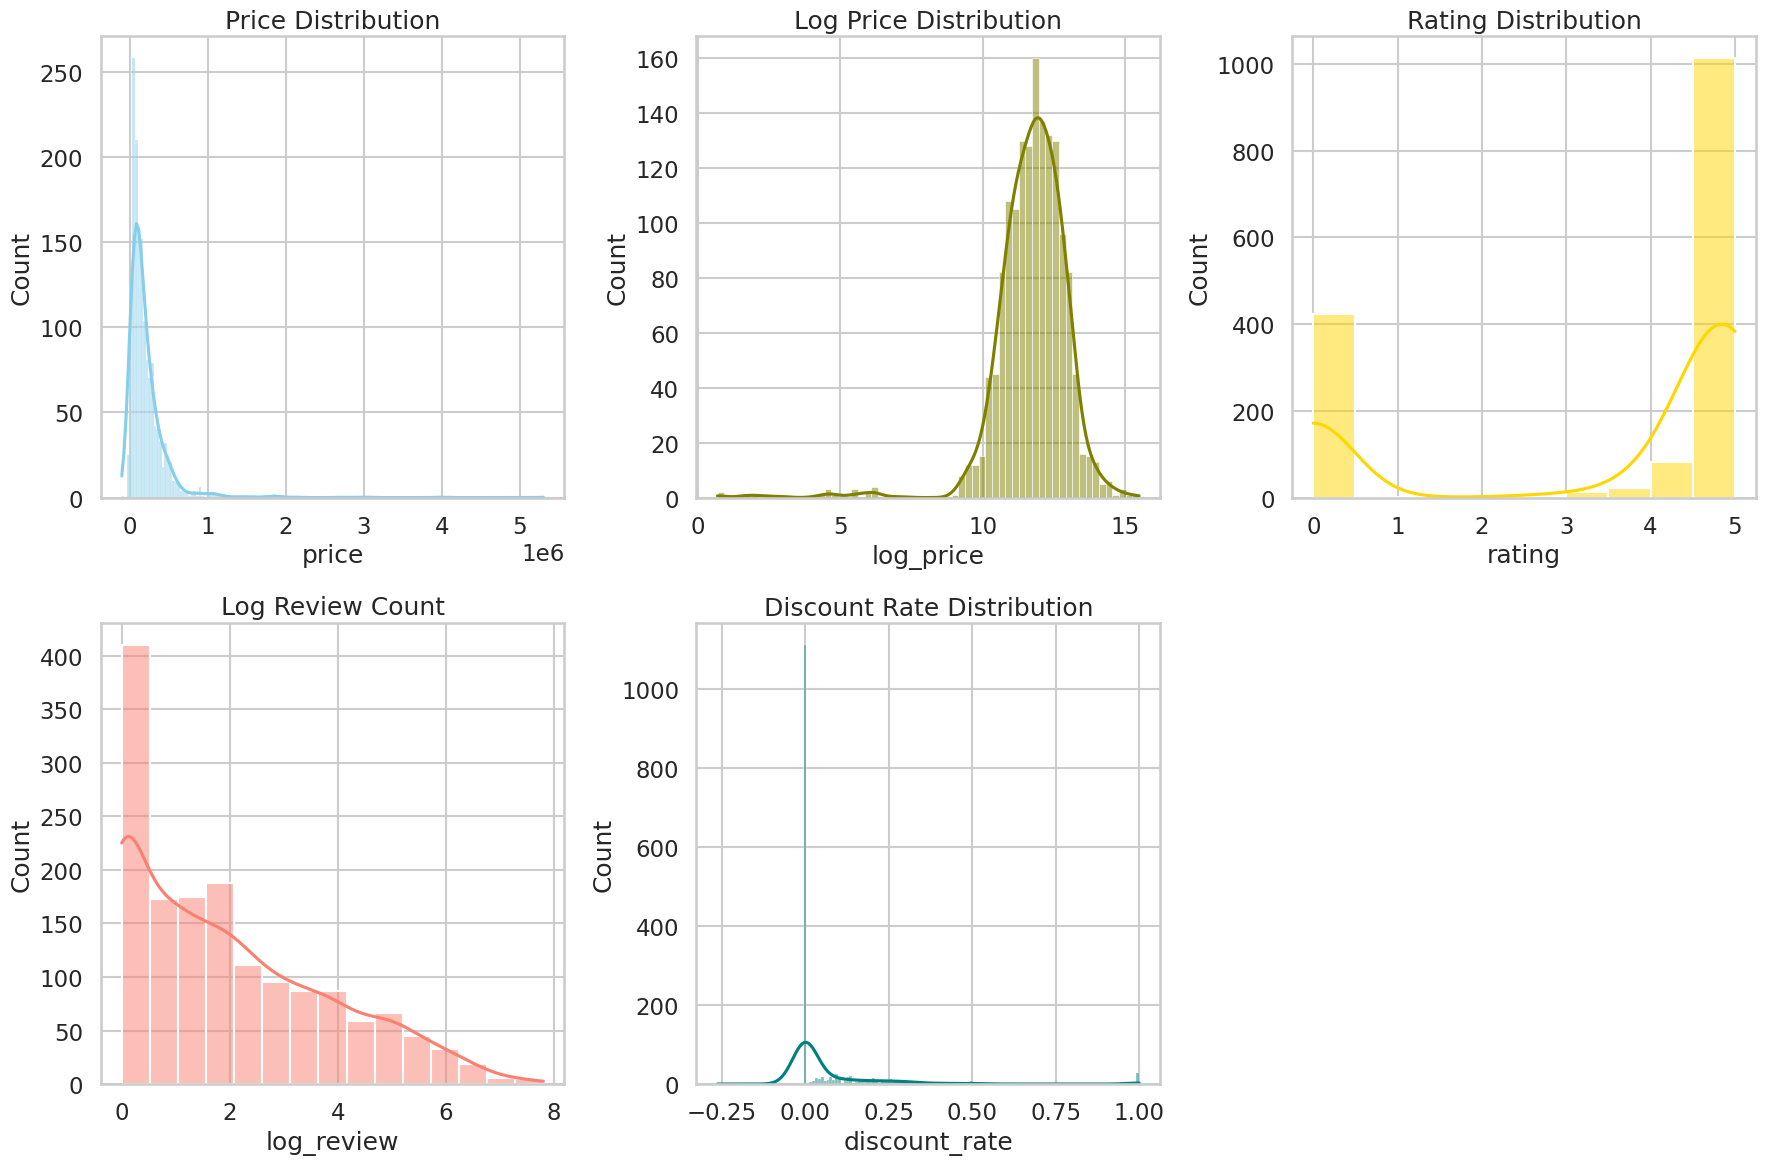

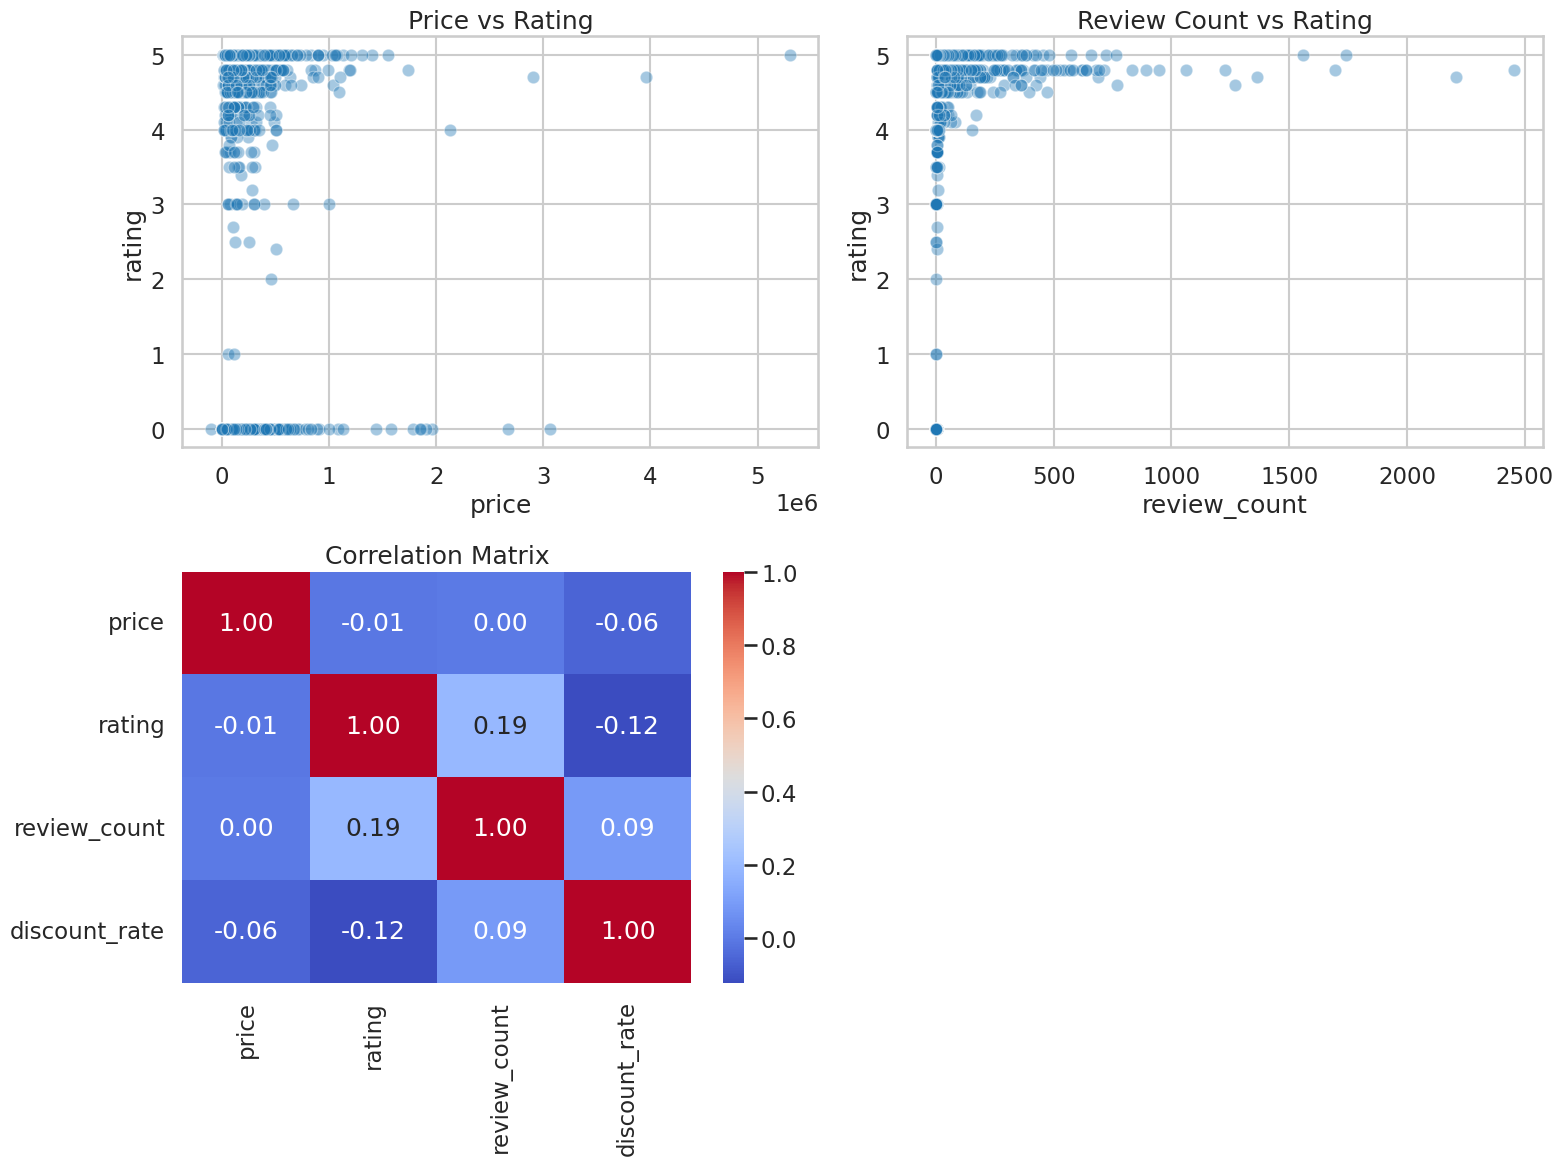

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2773604702.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='Blues_r')


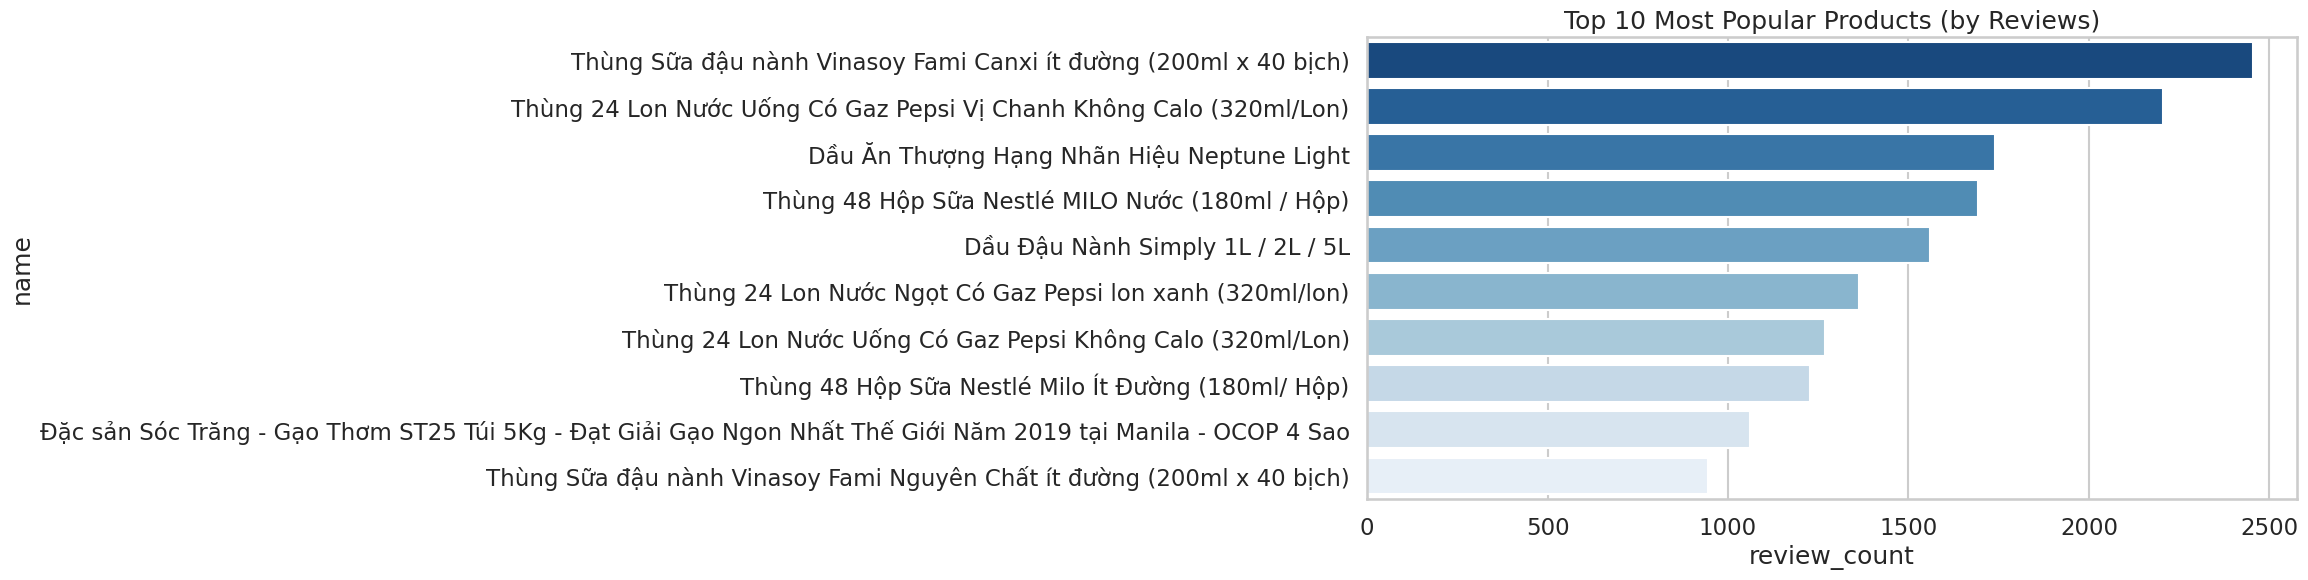

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2773604702.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2773604702.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = filtered_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2773604702.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg

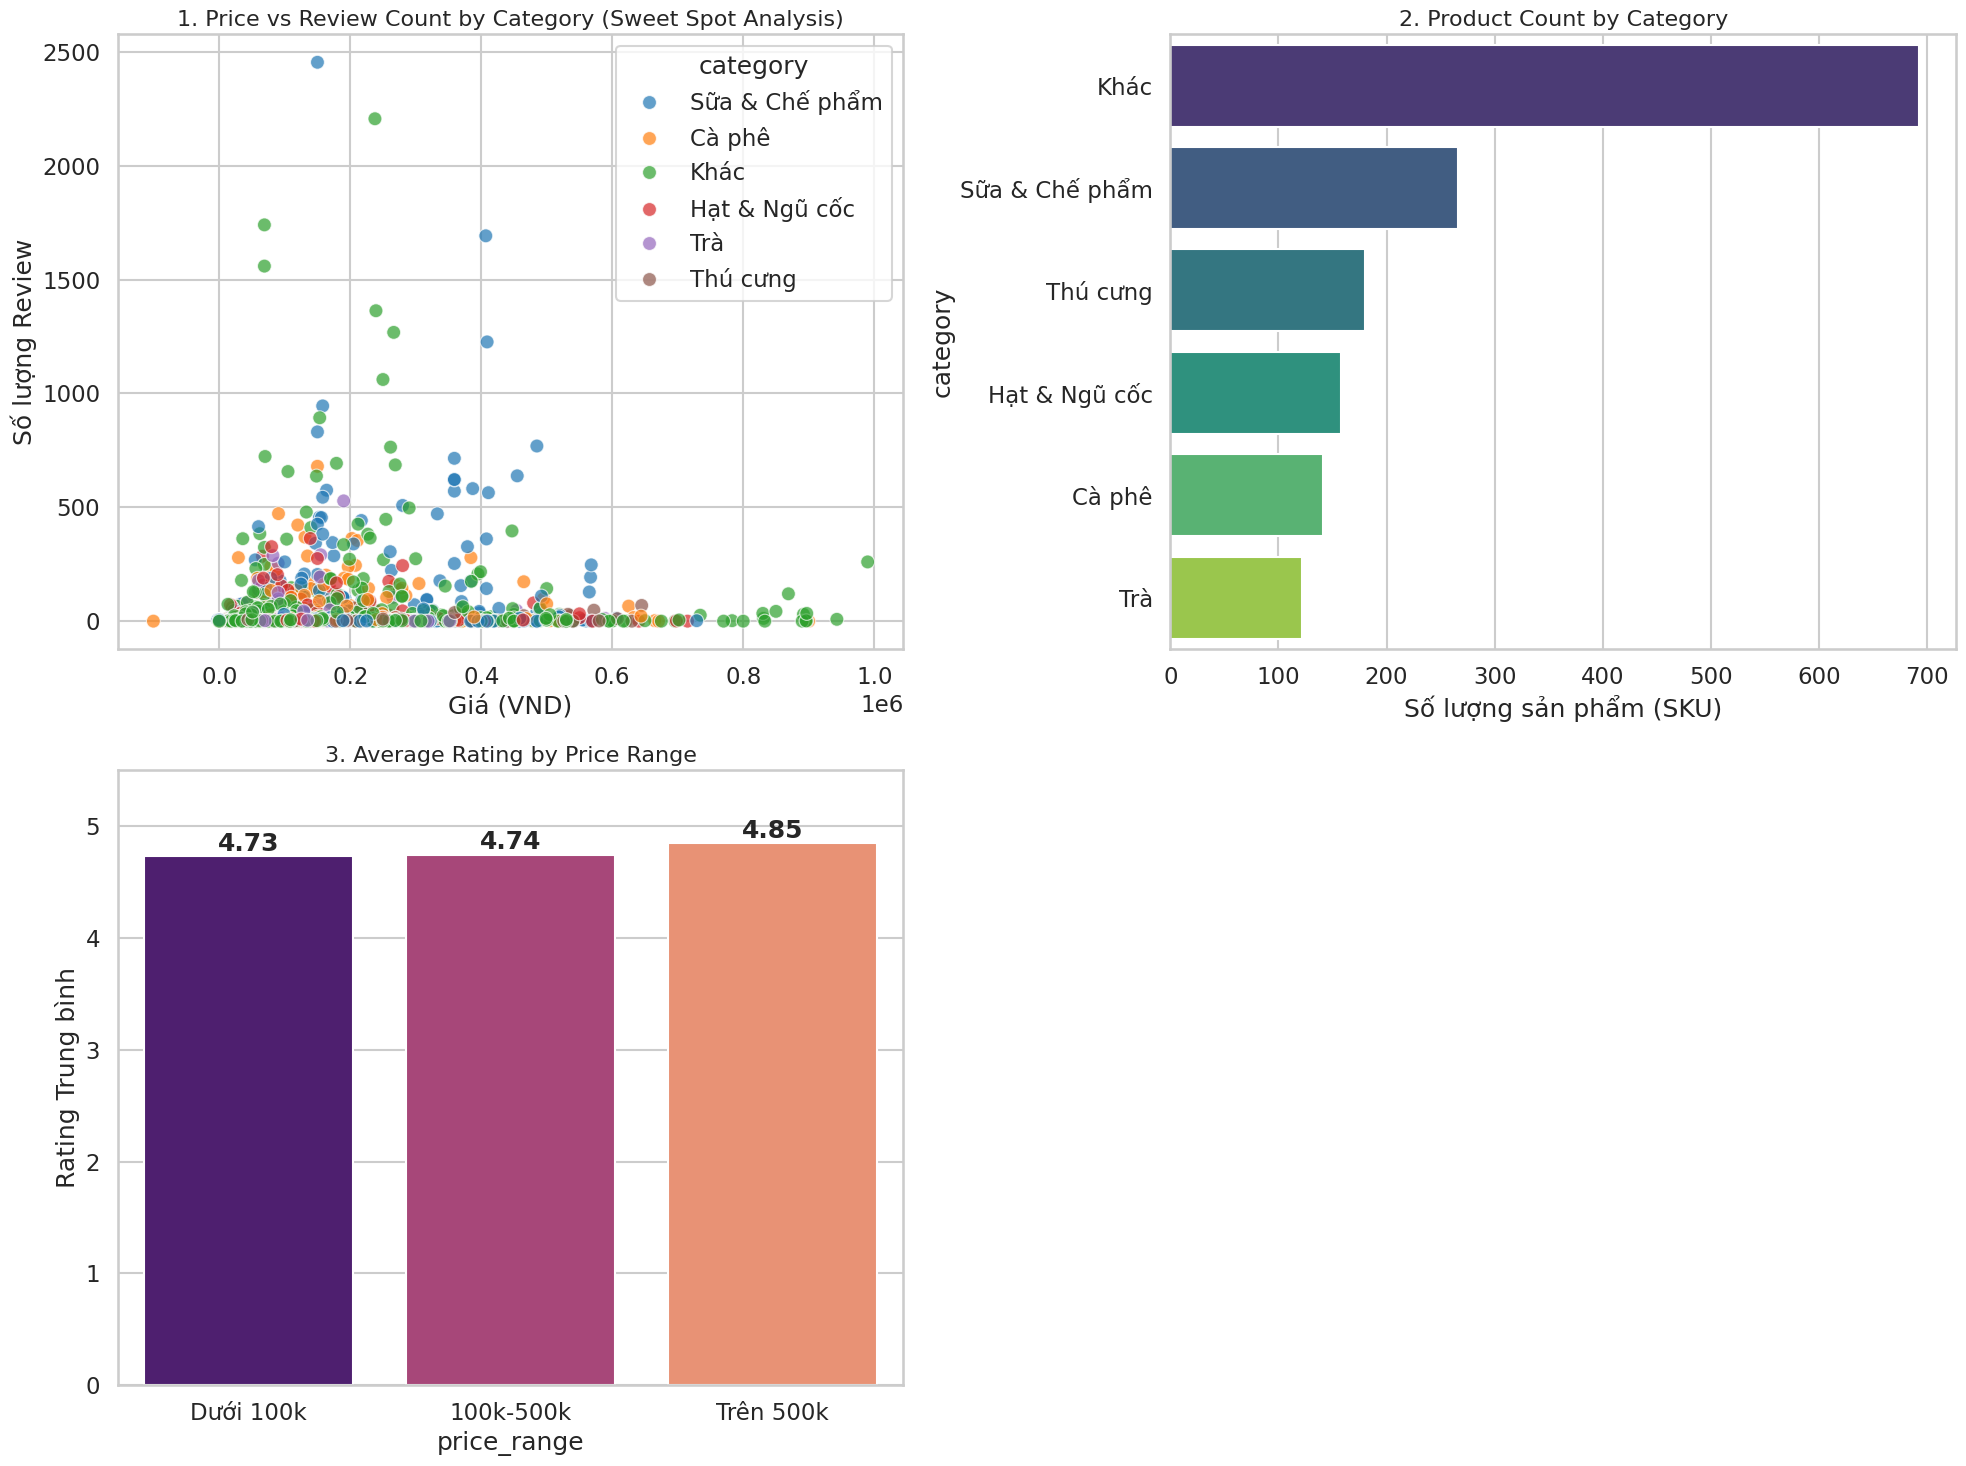

Hoàn tất xử lý và vẽ Dashboard phân tích chi tiết.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans' # Đảm bảo hiển thị tốt ký tự

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
df = pd.read_csv('D:/BCSE2023/Đồ án chuyên ngành/data_final/tiki_bach_hoa_online_cleaned_final.csv')

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# Hàm phân loại ngành hàng dựa trên từ khóa trong tên sản phẩm
def categorize_product(name):
    name = str(name).lower()
    if any(k in name for k in ['sữa', 'milo', 'nestlé', 'vinamilk']): return 'Sữa & Chế phẩm'
    if any(k in name for k in ['cà phê', 'cafe', 'nescafé', 'trung nguyên']): return 'Cà phê'
    if any(k in name for k in ['mèo', 'chó', 'pet', 'pedigree', 'royal canin']): return 'Thú cưng'
    if any(k in name for k in ['hạt', 'ngũ cốc', 'granola', 'điều', 'hạnh nhân']): return 'Hạt & Ngũ cốc'
    if any(k in name for k in ['trà', 'tea', 'phúc long']): return 'Trà'
    return 'Khác'

df['category'] = df['name'].apply(categorize_product)

# Phân khúc giá (Price Binning)
bins = [0, 100000, 500000, float('inf')]
labels = ['Dưới 100k', '100k-500k', 'Trên 500k']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. VẼ CÁC BIỂU ĐỒ PHÂN BỔ (CŨ)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Price Distribution')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='olive')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='gold')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='salmon')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='teal')
plt.title('Discount Rate Distribution')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. VẼ BIỂU ĐỒ TƯƠNG QUAN VÀ TOP SẢN PHẨM (CŨ)
# ---------------------------------------------------------
plt.figure(figsize=(16, 12))

# Scatter plots
plt.subplot(2, 2, 1)
sns.scatterplot(x='price', y='rating', data=df, alpha=0.4)
plt.title('Price vs Rating')

plt.subplot(2, 2, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.4)
plt.title('Review Count vs Rating')

# Heatmap
plt.subplot(2, 2, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Most Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='Blues_r')
plt.title('Top 10 Most Popular Products (by Reviews)')
plt.show()

# ---------------------------------------------------------
# 4. VẼ 3 BIỂU ĐỒ CHIẾN LƯỢC BỔ SUNG (MỚI)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review Count theo Ngành hàng (Xác định "Sweet Spot")
plt.subplot(2, 2, 1)
# Giới hạn giá < 1 triệu để biểu đồ không bị loãng do sản phẩm yến sào/quà tặng cao cấp
sns.scatterplot(data=df[df['price'] < 1000000], x='price', y='review_count', hue='category', alpha=0.7, s=100)
plt.title('1. Price vs Review Count by Category (Sweet Spot Analysis)', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu số lượng sản phẩm theo Ngành hàng
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('2. Product Count by Category', fontsize=16)
plt.xlabel('Số lượng sản phẩm (SKU)')

# Biểu đồ 3: Rating trung bình theo Phân khúc giá
plt.subplot(2, 2, 3)
# Lọc sản phẩm có rating > 0 và review > 2 để đảm bảo tính khách quan
filtered_df = df[(df['rating'] > 0) & (df['review_count'] > 2)]
avg_rating_price = filtered_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='magma')
# Ghi chú con số lên đầu cột
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Average Rating by Price Range', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

print("Hoàn tất xử lý và vẽ Dashboard phân tích chi tiết.")

2. Chăm sóc da mặt

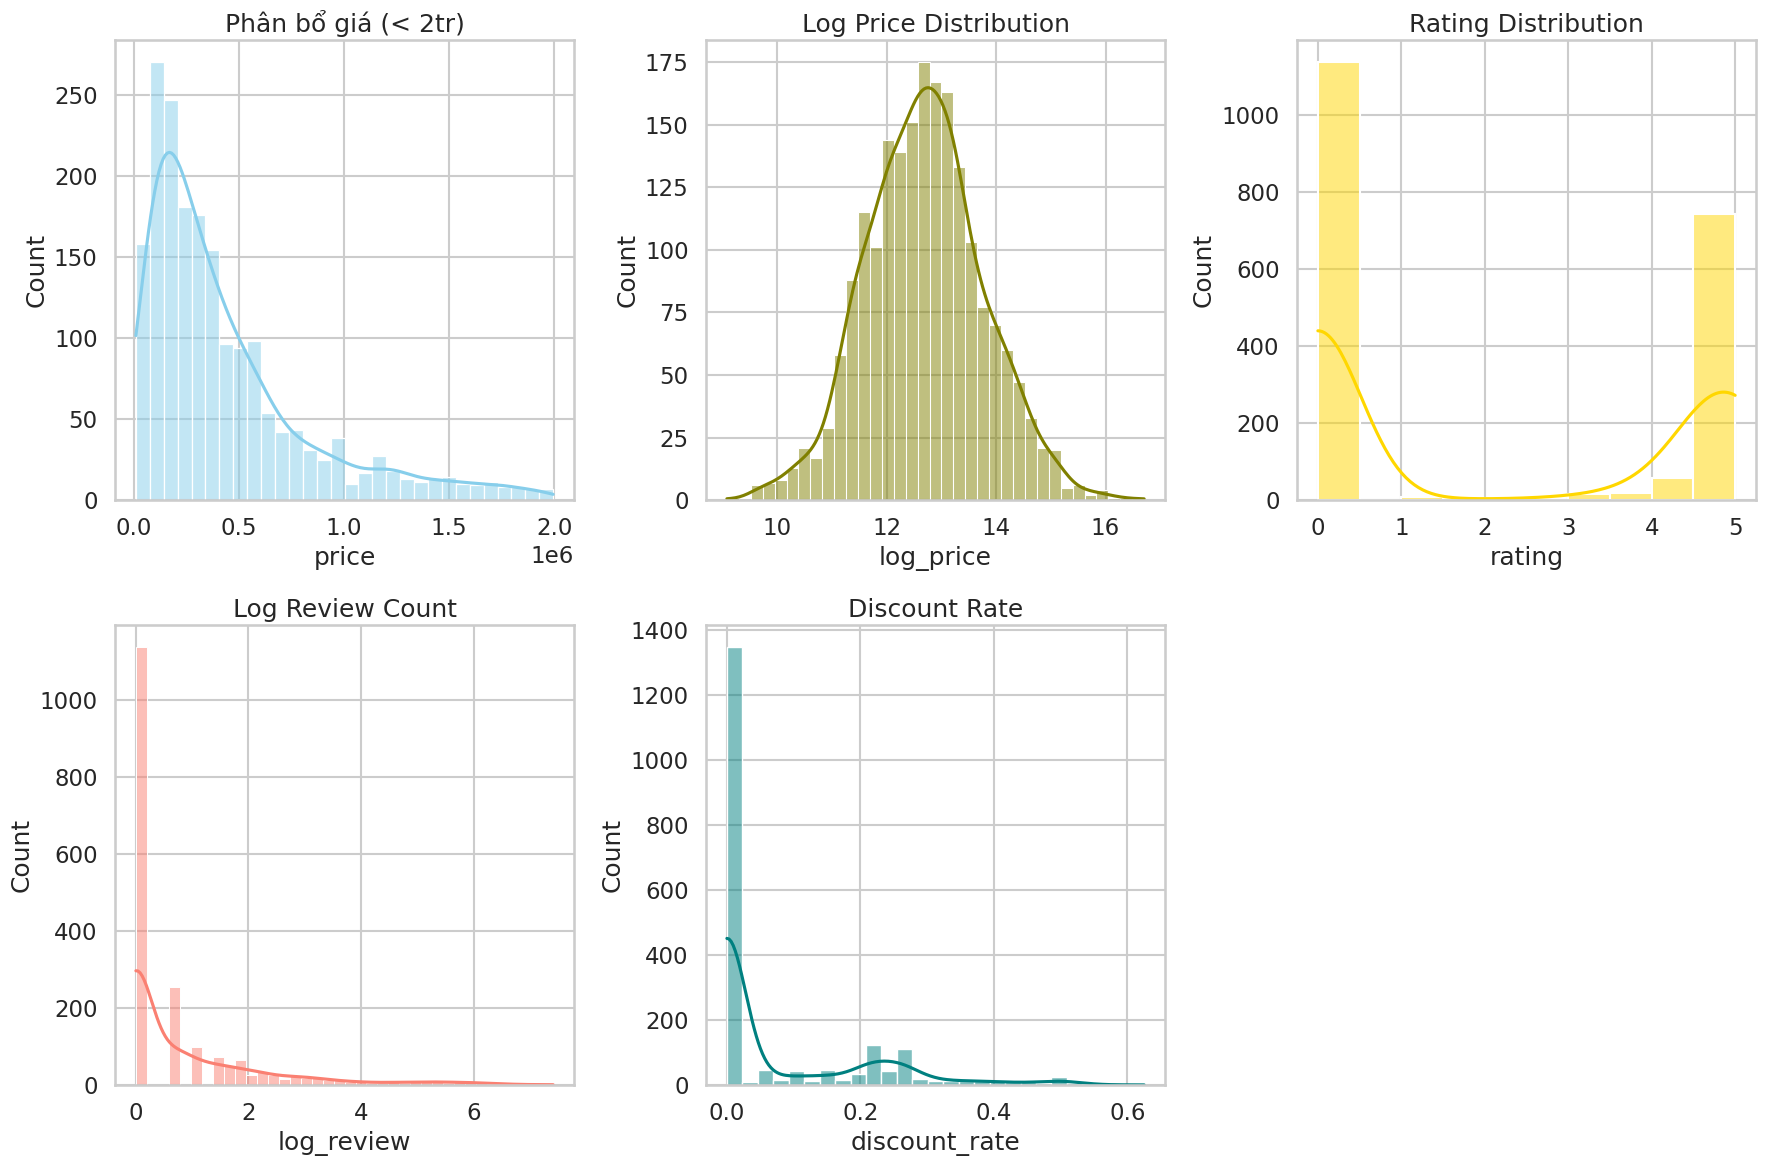

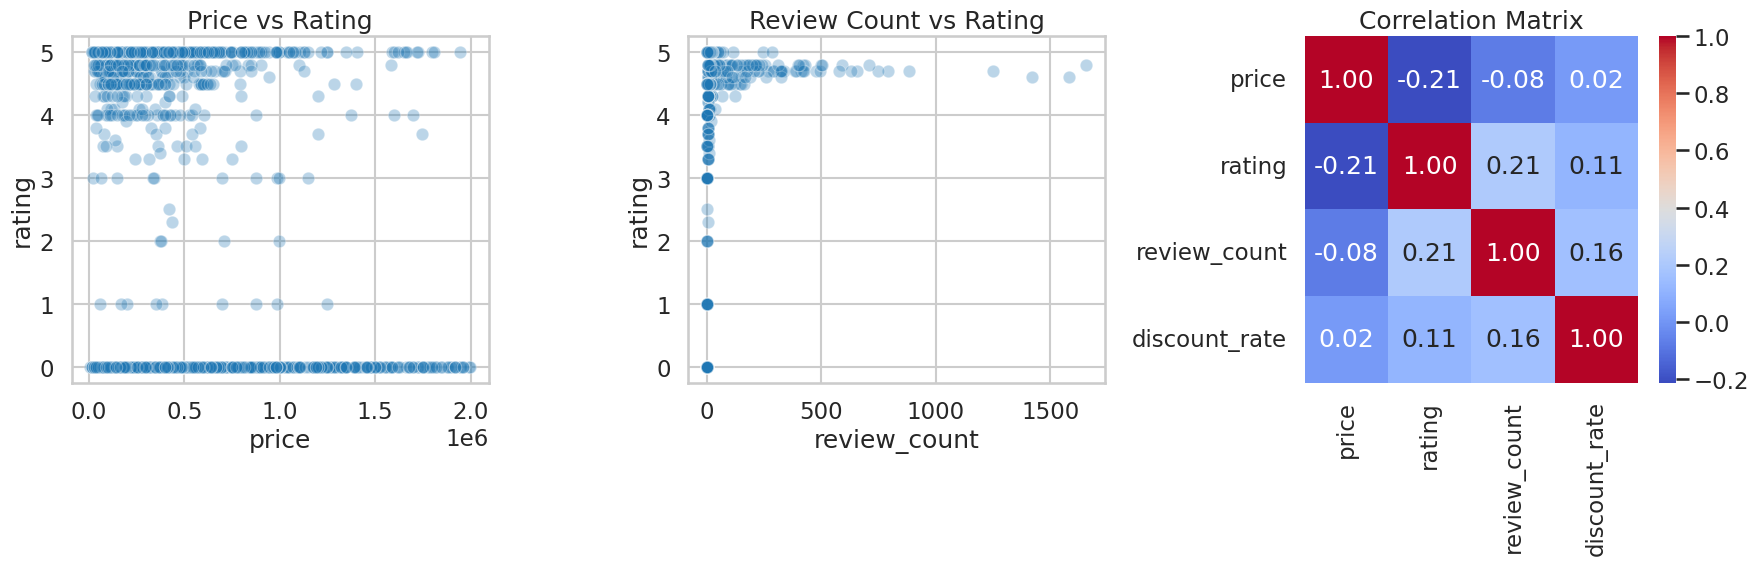

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\4193385860.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='magma')


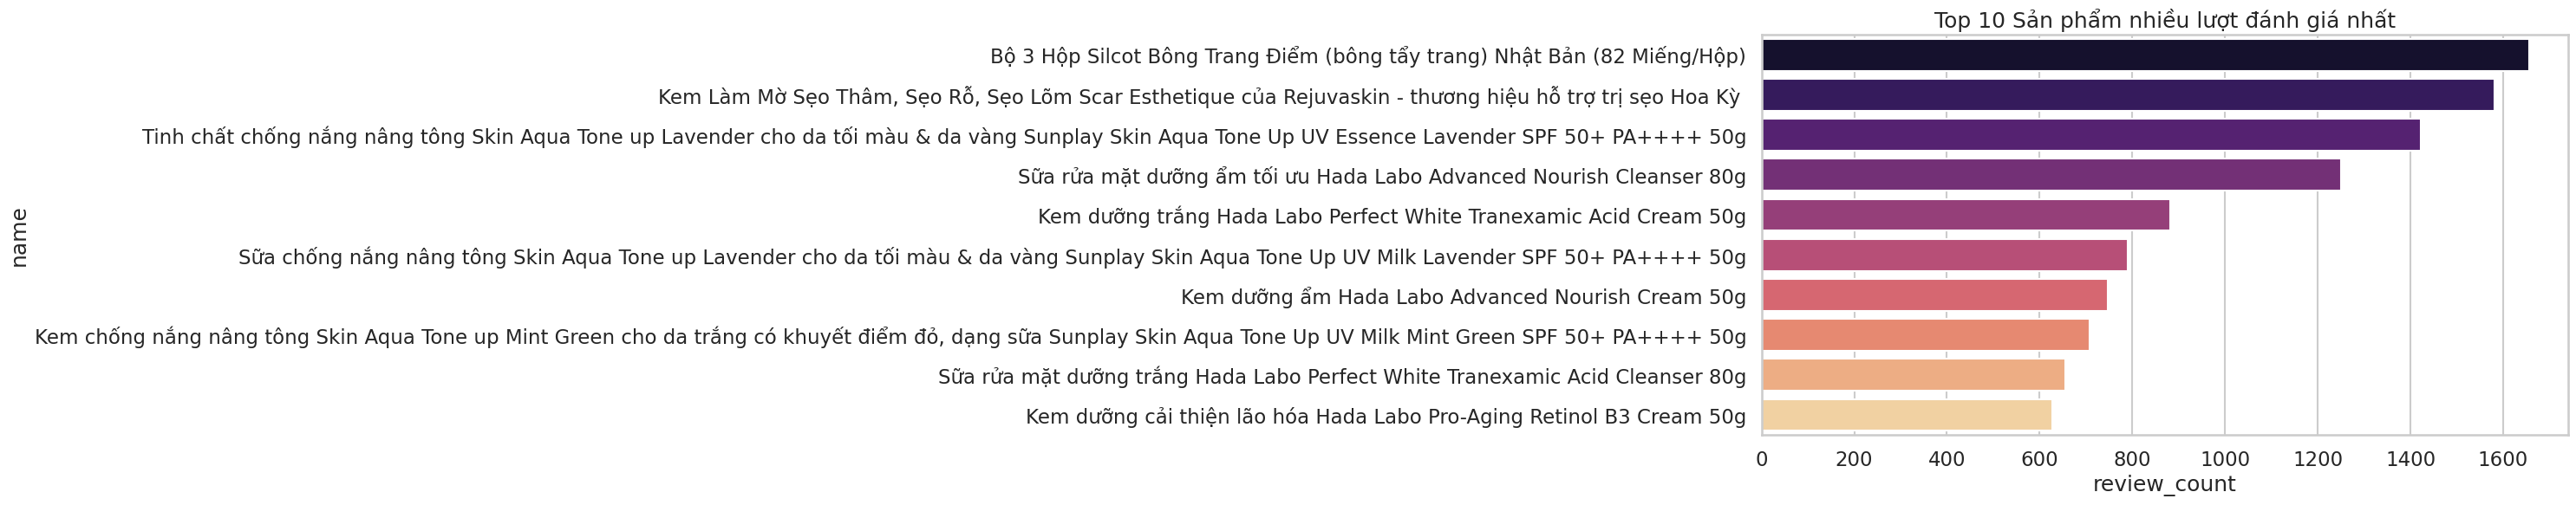

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\4193385860.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\4193385860.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_rating_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\4193385860.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data

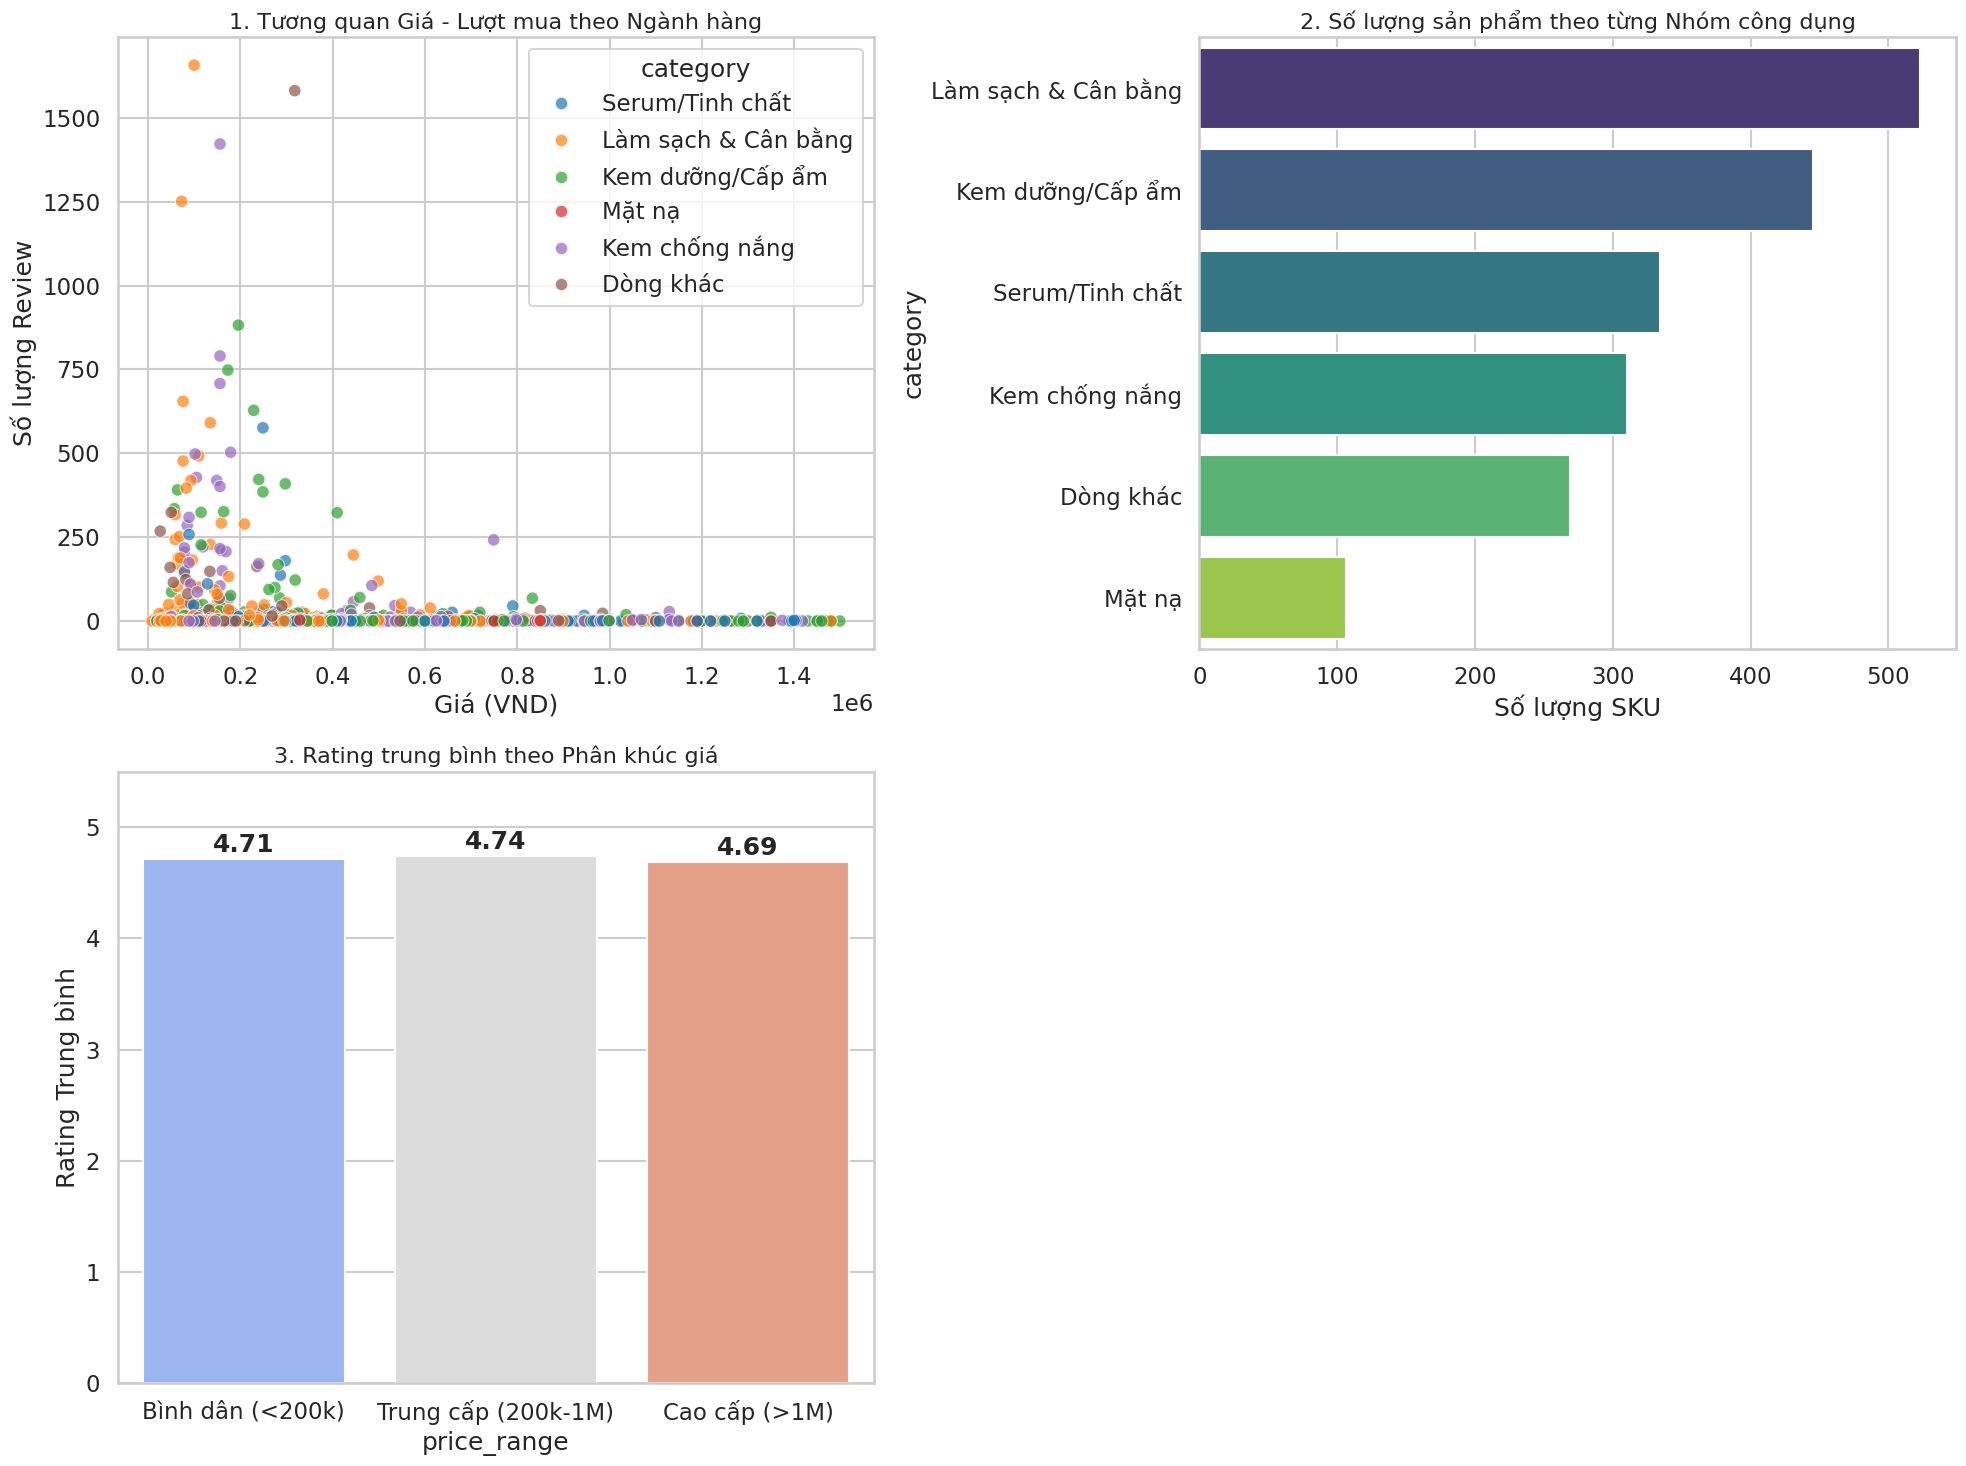

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
# Thay đổi đường dẫn đến file của bạn
file_path = 'tiki_cham_soc_da_mat_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH MỸ PHẨM ---
def categorize_skincare(name):
    name = str(name).lower()
    if any(k in name for k in ['chống nắng', 'sun', 'spf']): return 'Kem chống nắng'
    if any(k in name for k in ['serum', 'tinh chất', 'essence']): return 'Serum/Tinh chất'
    if any(k in name for k in ['rửa mặt', 'tẩy trang', 'cleansing', 'toner']): return 'Làm sạch & Cân bằng'
    if any(k in name for k in ['kem dưỡng', 'ẩm', 'cream', 'gel']): return 'Kem dưỡng/Cấp ẩm'
    if any(k in name for k in ['mặt nạ', 'mask']): return 'Mặt nạ'
    return 'Dòng khác'

df['category'] = df['name'].apply(categorize_skincare)

# Phân khúc giá mới (Dành cho mỹ phẩm)
bins = [0, 200000, 1000000, float('inf')]
labels = ['Bình dân (<200k)', 'Trung cấp (200k-1M)', 'Cao cấp (>1M)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df[df['price'] < 2000000]['price'], kde=True, color='skyblue')
plt.title('Phân bổ giá (< 2tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='olive')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='gold')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='salmon')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='teal')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 2000000], alpha=0.3)
plt.title('Price vs Rating')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3)
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='magma')
plt.title('Top 10 Sản phẩm nhiều lượt đánh giá nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (NÂNG CAO)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review Count theo Nhóm (Tìm "Best Sellers" của từng ngành)
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 1500000], x='price', y='review_count', hue='category', alpha=0.7, s=80)
plt.title('1. Tương quan Giá - Lượt mua theo Ngành hàng', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu Ngành hàng (Treemap Style Bar)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('2. Số lượng sản phẩm theo từng Nhóm công dụng', fontsize=16)
plt.xlabel('Số lượng SKU')

# Biểu đồ 3: Chất lượng (Rating) trung bình theo Phân khúc giá
plt.subplot(2, 2, 3)
# Lọc bỏ các sản phẩm chưa có review để số liệu rating chính xác
valid_rating_df = df[df['review_count'] > 5]
avg_rating_price = valid_rating_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='coolwarm')
# Ghi số liệu lên đầu cột
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

3. Điện gia dụng

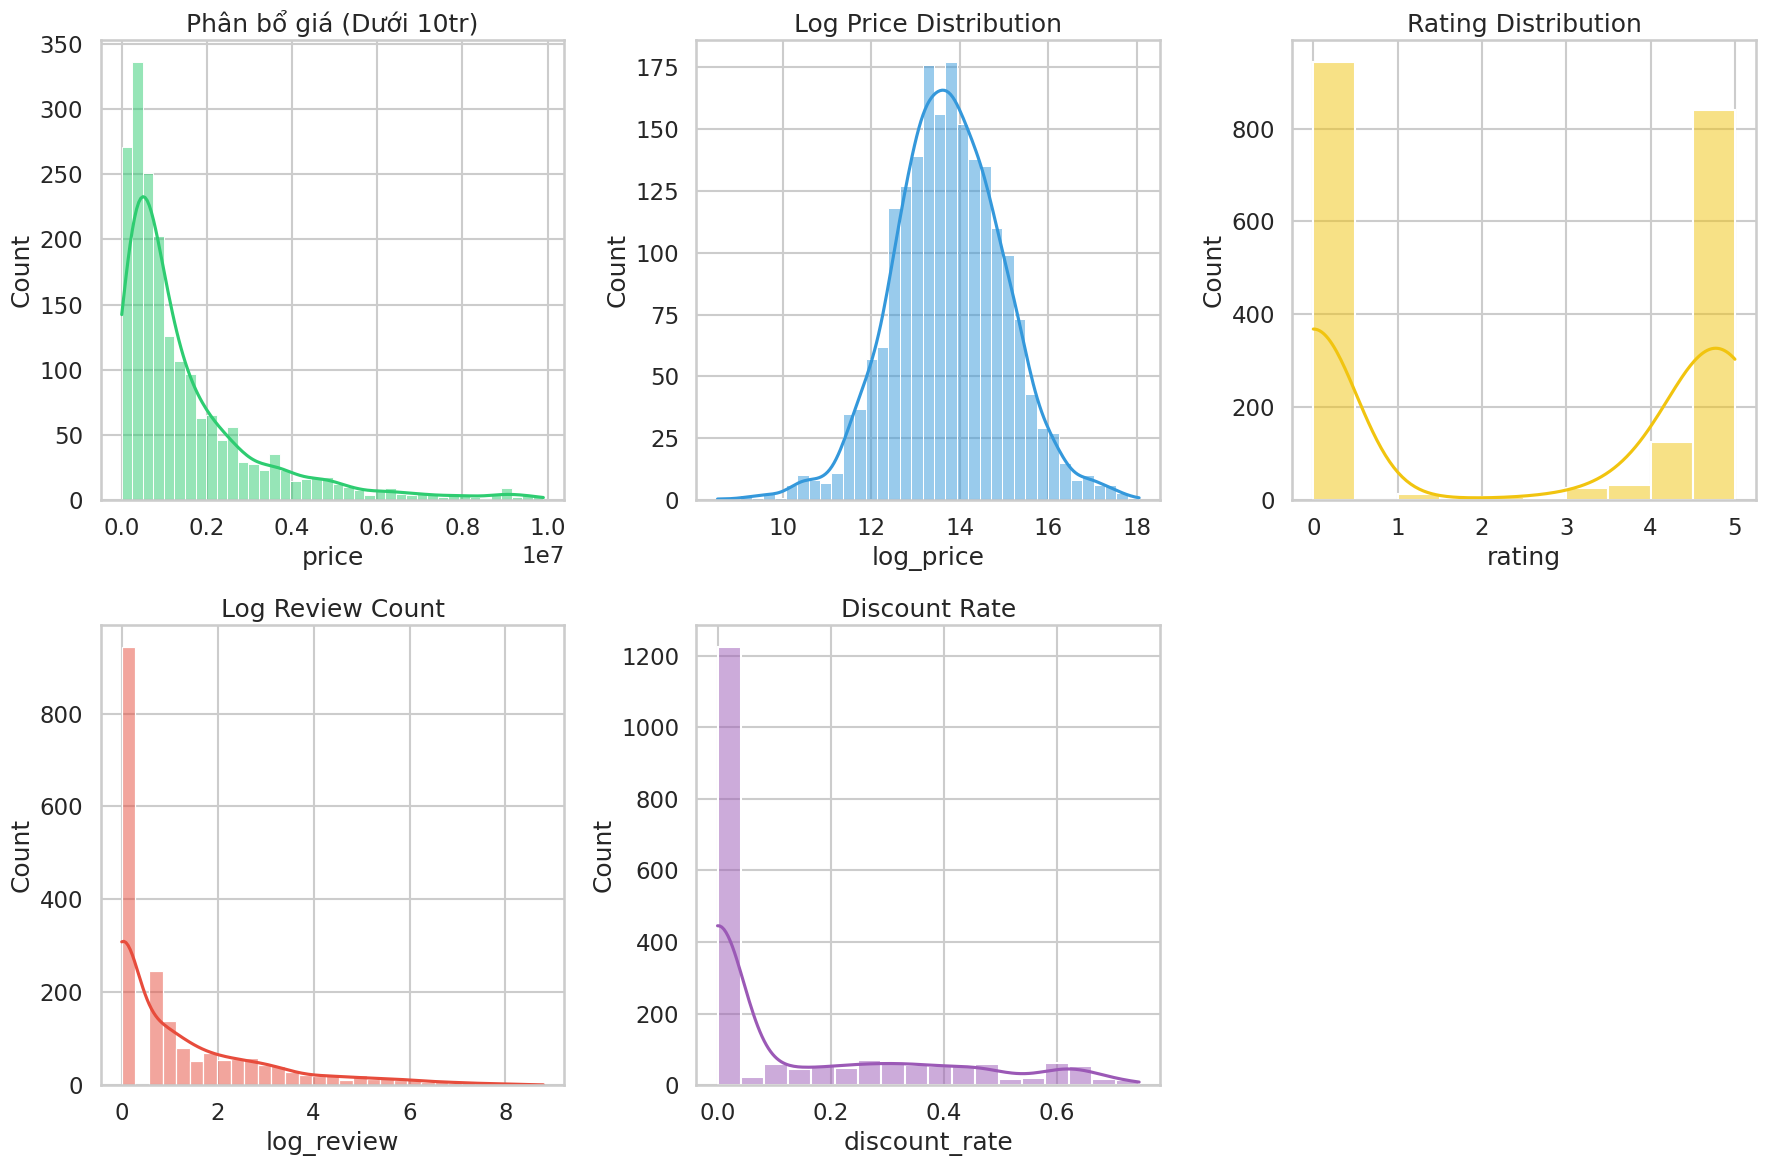

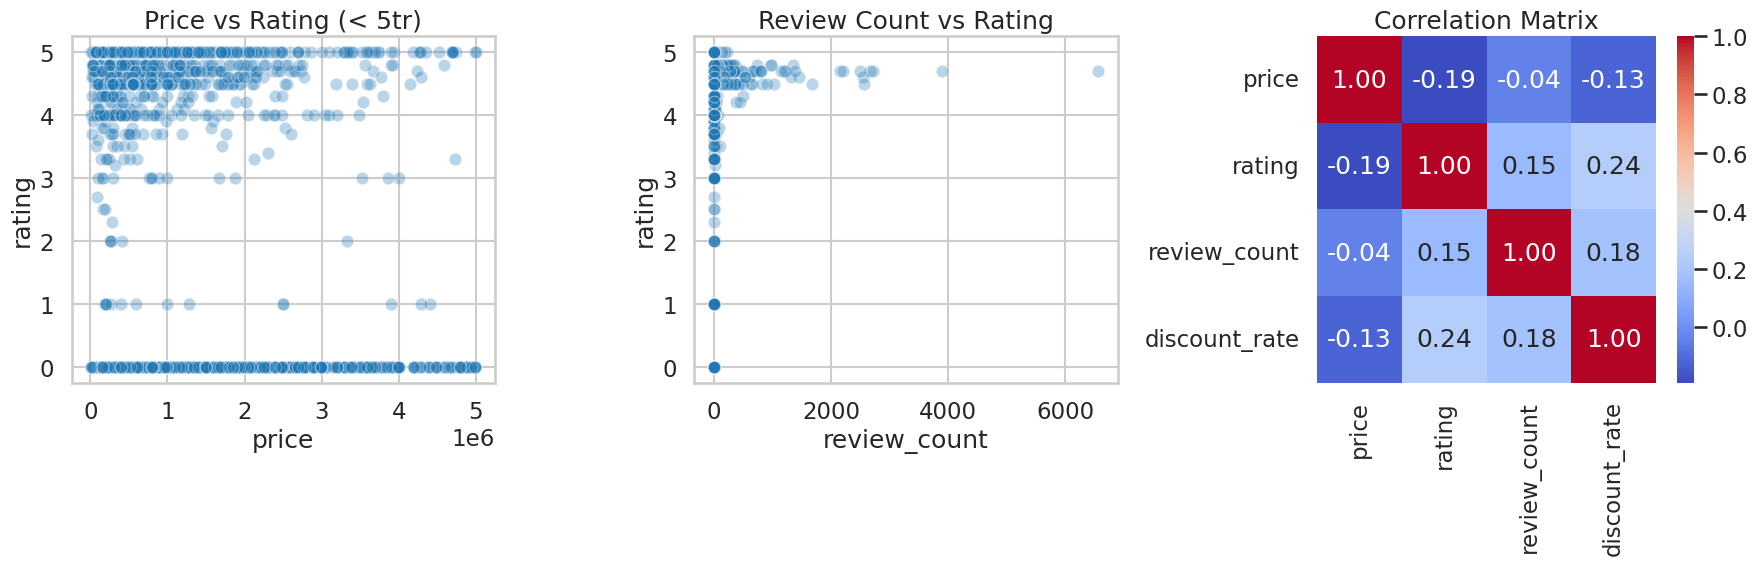

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1596228014.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='viridis')


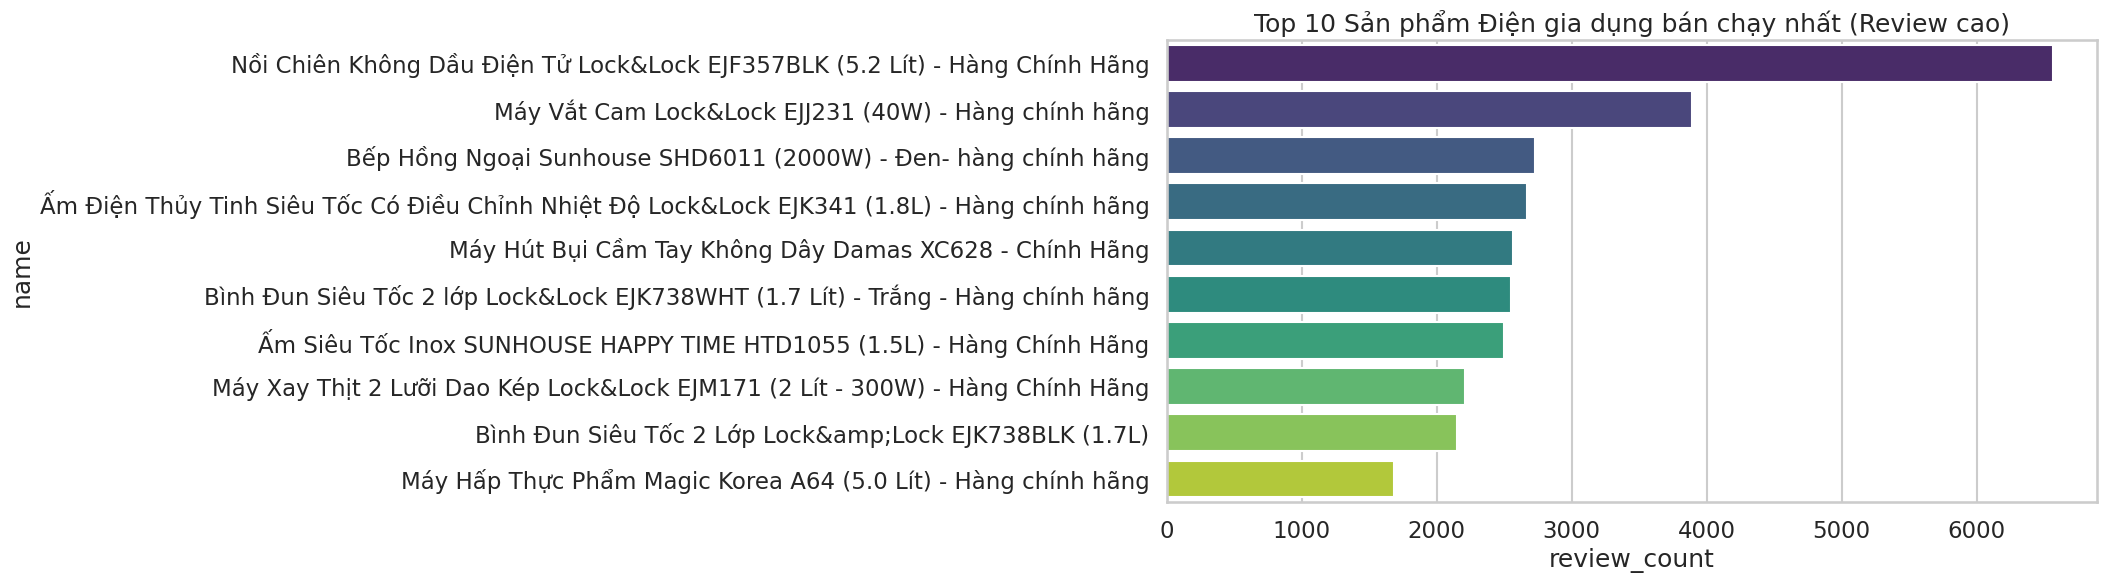

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1596228014.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='Spectral')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1596228014.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1596228014.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_r

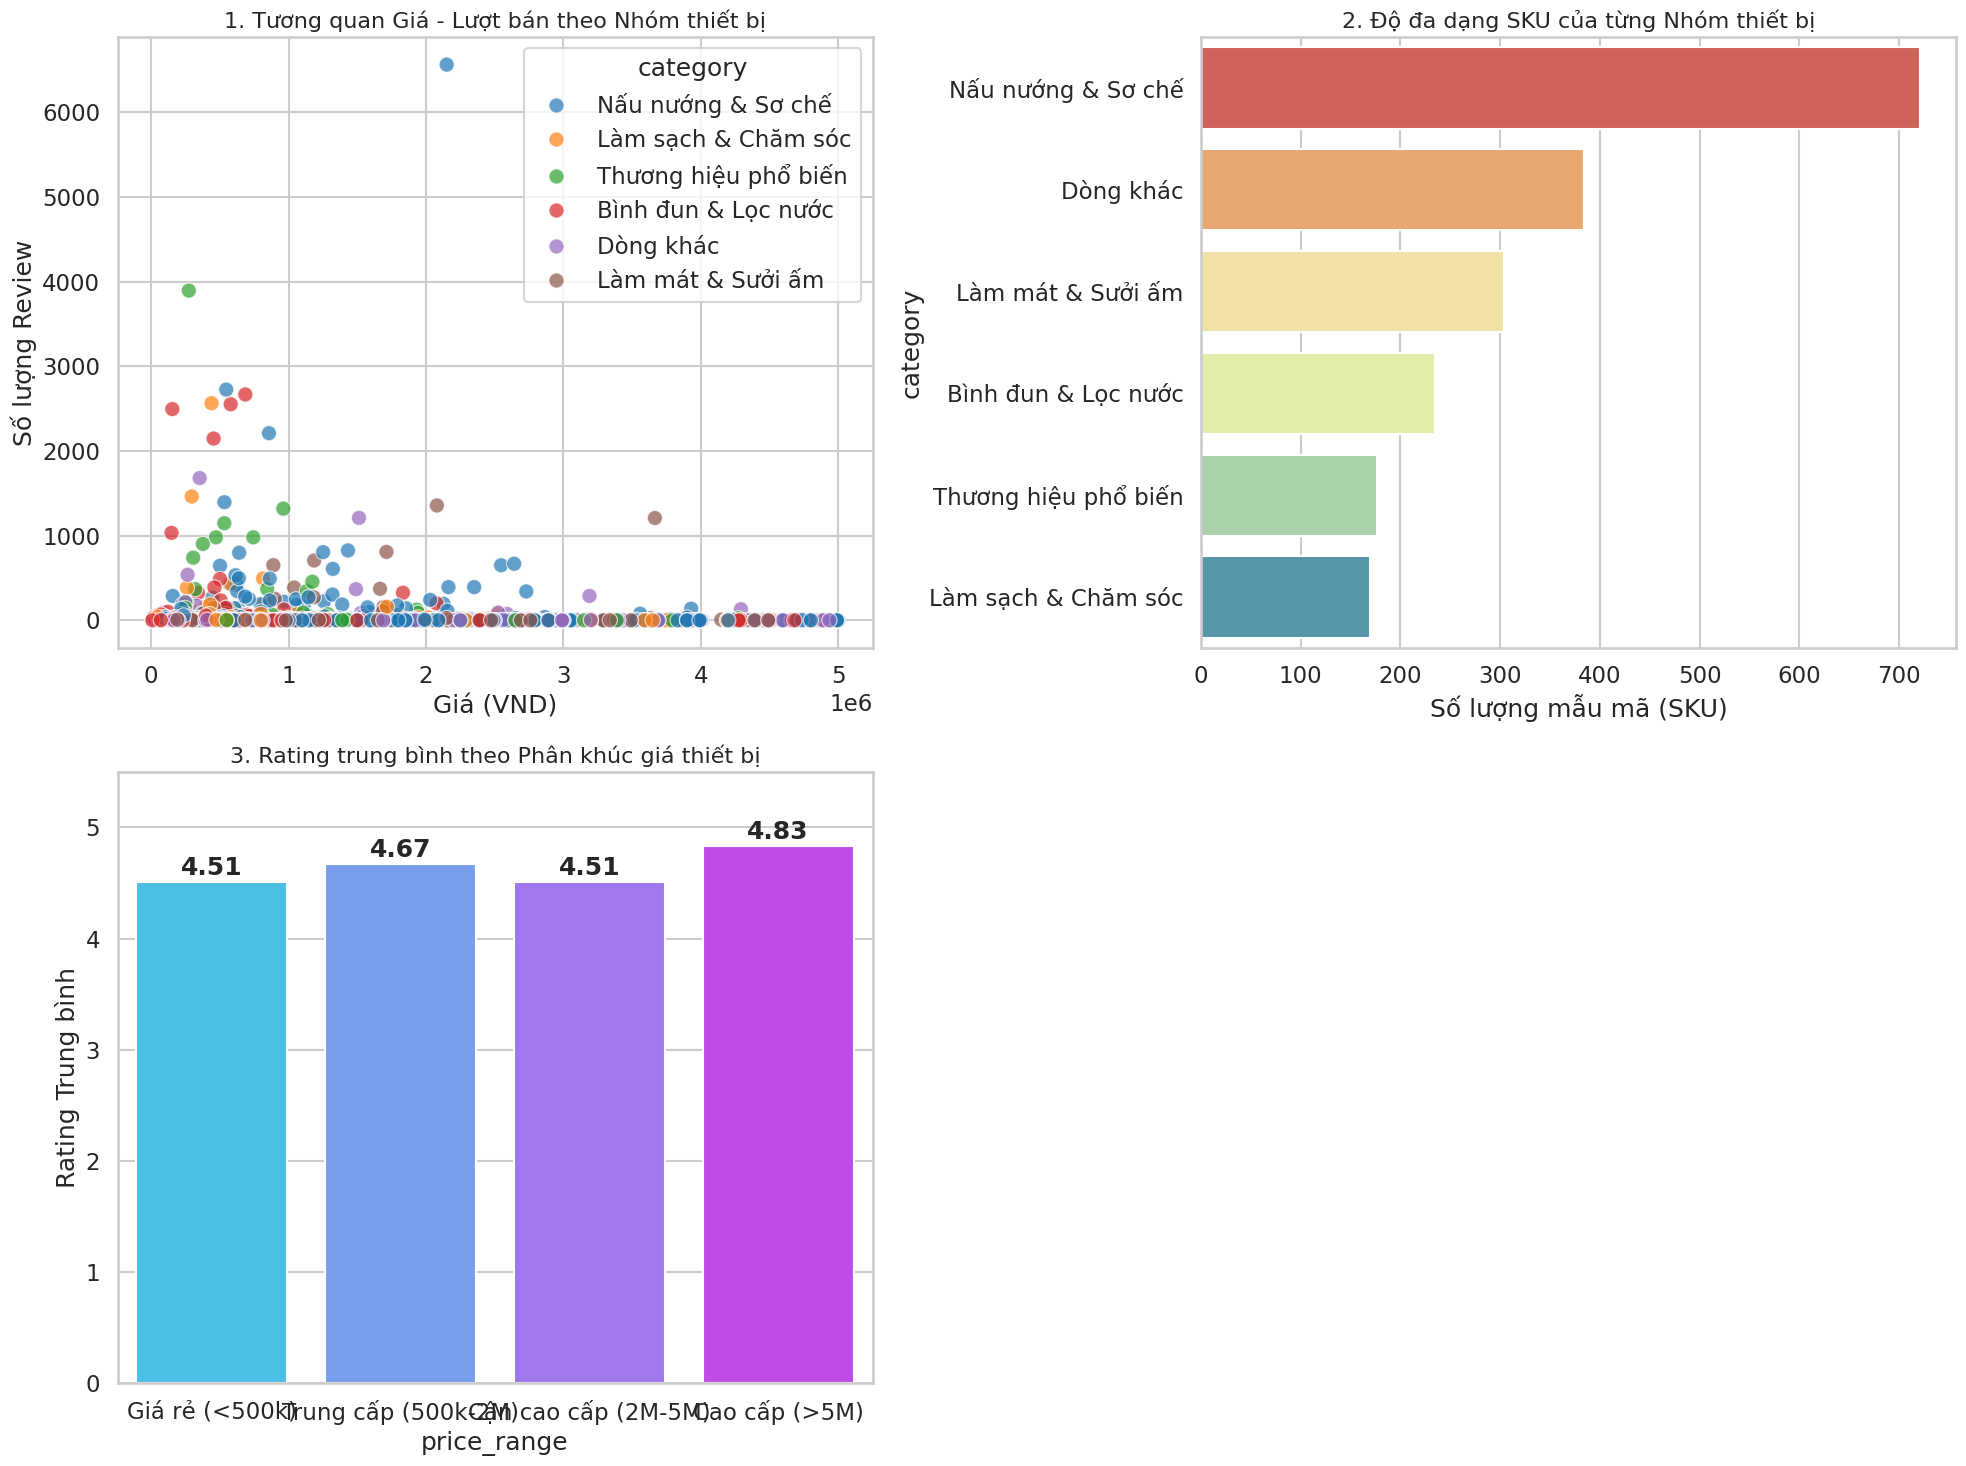

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện chuẩn Dashboard
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_dien_gia_dung_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH ĐIỆN GIA DỤNG ---
def categorize_home_appliance(name):
    name = str(name).lower()
    if any(k in name for k in ['nồi', 'bếp', 'lò nướng', 'chiên', 'đánh trứng', 'xay']): return 'Nấu nướng & Sơ chế'
    if any(k in name for k in ['quạt', 'sưởi', 'điều hòa', 'lọc không khí']): return 'Làm mát & Sưởi ấm'
    if any(k in name for k in ['bình', 'ấm', 'lọc nước', 'đun']): return 'Bình đun & Lọc nước'
    if any(k in name for k in ['bàn ủi', 'hút bụi', 'vệ sinh']): return 'Làm sạch & Chăm sóc'
    if any(k in name for k in ['philips', 'lock', 'sunhouse', 'panasonic', 'bear', 'elmich']): return 'Thương hiệu phổ biến'
    return 'Dòng khác'

df['category'] = df['name'].apply(categorize_home_appliance)

# Phân khúc giá mới (Dành cho đồ điện gia dụng)
bins = [0, 500000, 2000000, 5000000, float('inf')]
labels = ['Giá rẻ (<500k)', 'Trung cấp (500k-2M)', 'Cận cao cấp (2M-5M)', 'Cao cấp (>5M)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
# Giới hạn giá 10tr để thấy rõ phân bổ chính
sns.histplot(df[df['price'] < 10000000]['price'], kde=True, color='#2ecc71')
plt.title('Phân bổ giá (Dưới 10tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='#3498db')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='#f1c40f')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='#e74c3c')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='#9b59b6')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 5000000], alpha=0.3)
plt.title('Price vs Rating (< 5tr)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3)
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='viridis')
plt.title('Top 10 Sản phẩm Điện gia dụng bán chạy nhất (Review cao)')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (ĐÁNH GIÁ CHUYÊN SÂU)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Nhóm (Tìm "Thị trường ngách" và "Thị trường đại chúng")
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 5000000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Tương quan Giá - Lượt bán theo Nhóm thiết bị', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu SKU theo Nhóm công dụng
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='Spectral')
plt.title('2. Độ đa dạng SKU của từng Nhóm thiết bị', fontsize=16)
plt.xlabel('Số lượng mẫu mã (SKU)')

# Biểu đồ 3: Rating trung bình theo Phân khúc giá (Check sự hài lòng của khách hàng)
plt.subplot(2, 2, 3)
# Lọc các sản phẩm có ít nhất 1 đánh giá để chính xác
valid_df = df[df['review_count'] > 0]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='cool')
# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá thiết bị', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

4. Đồng hồ trang sức

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3314914476.py:63: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


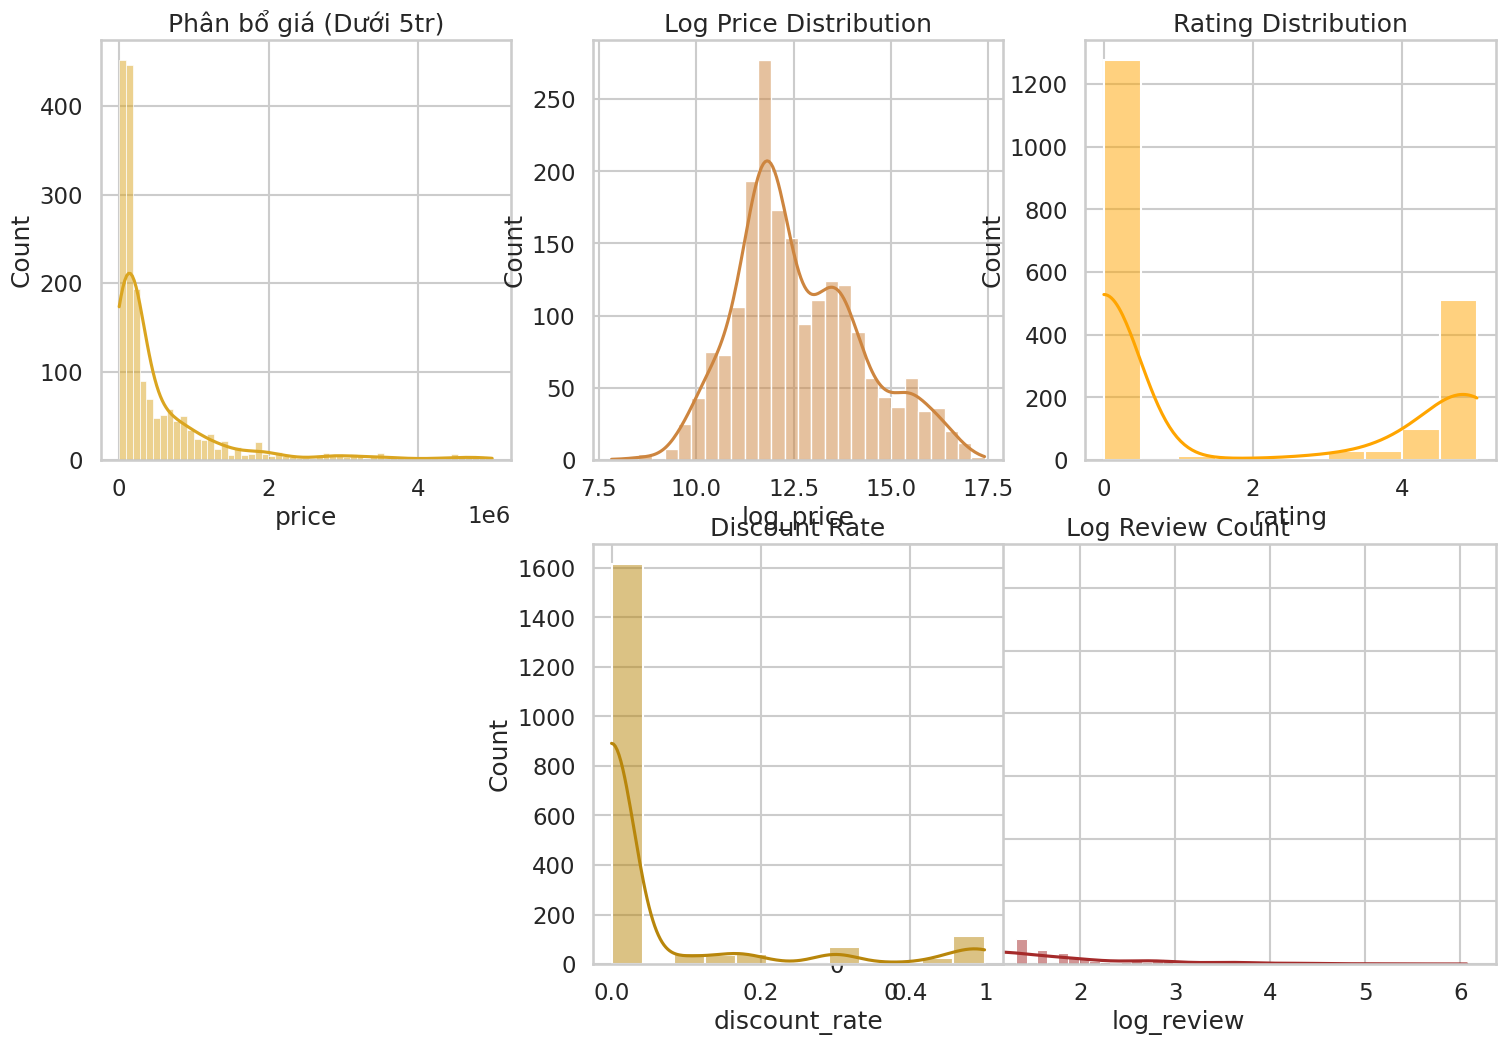

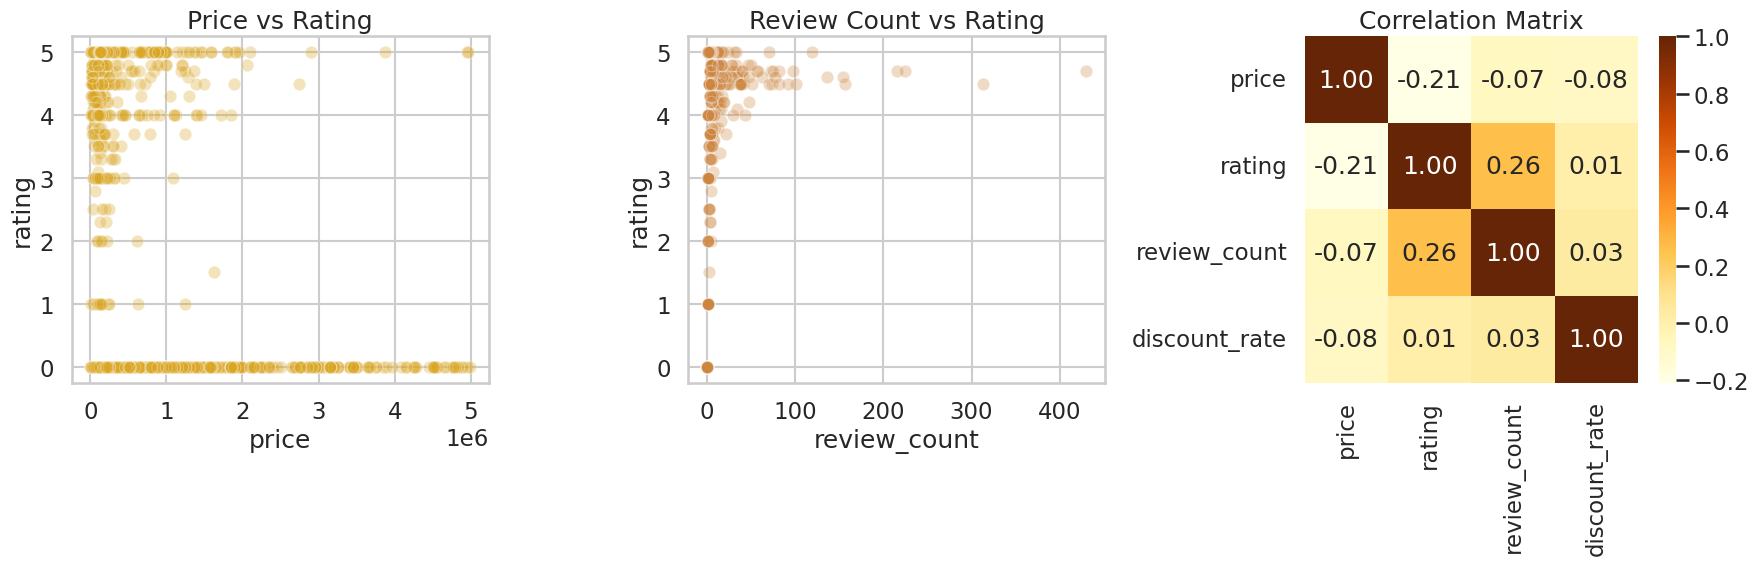

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3314914476.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='YlOrBr_r')


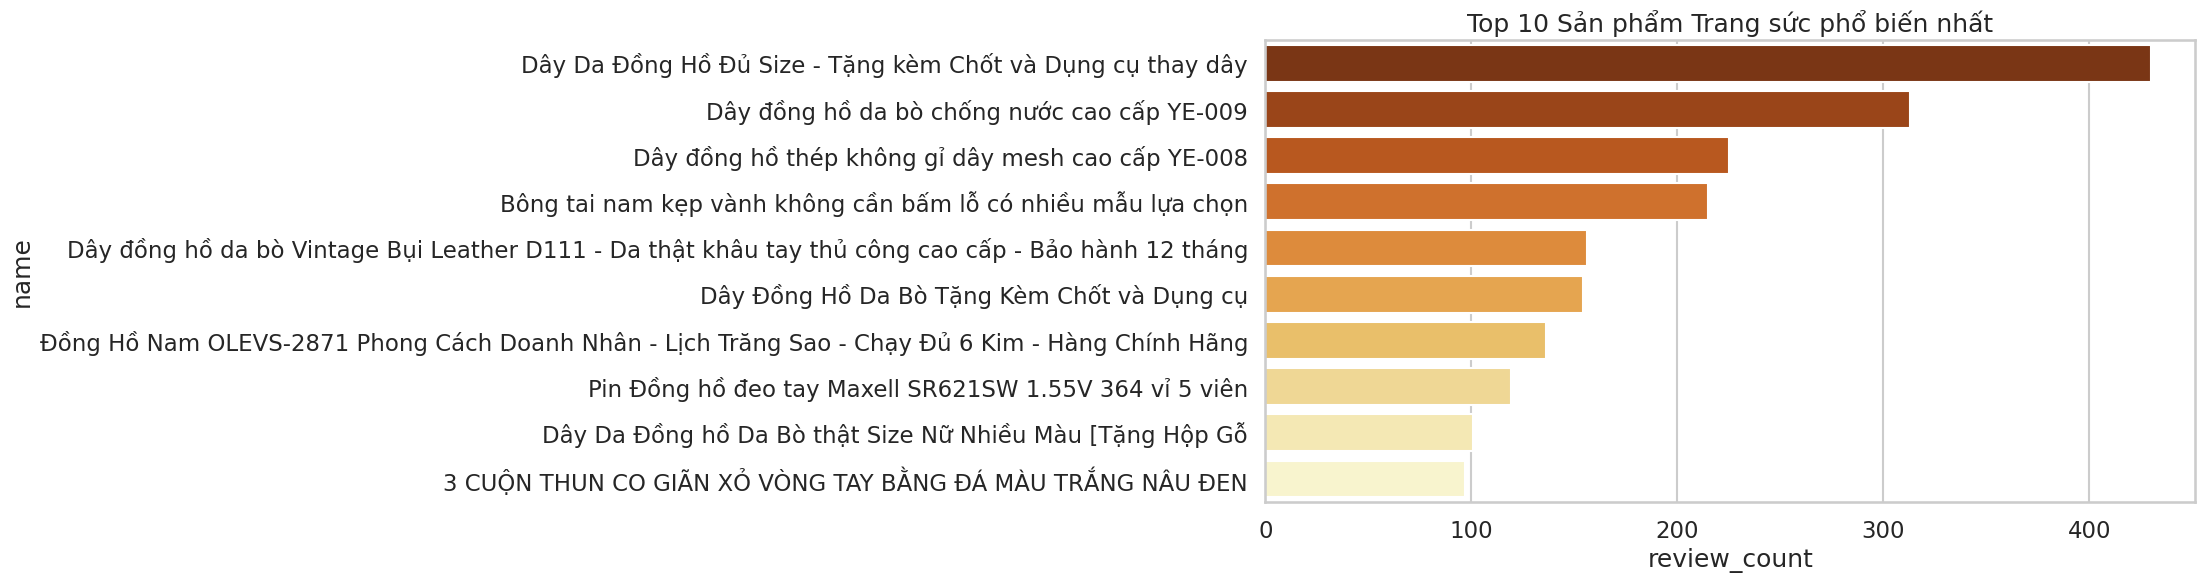

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3314914476.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='copper')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3314914476.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3314914476.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_rat

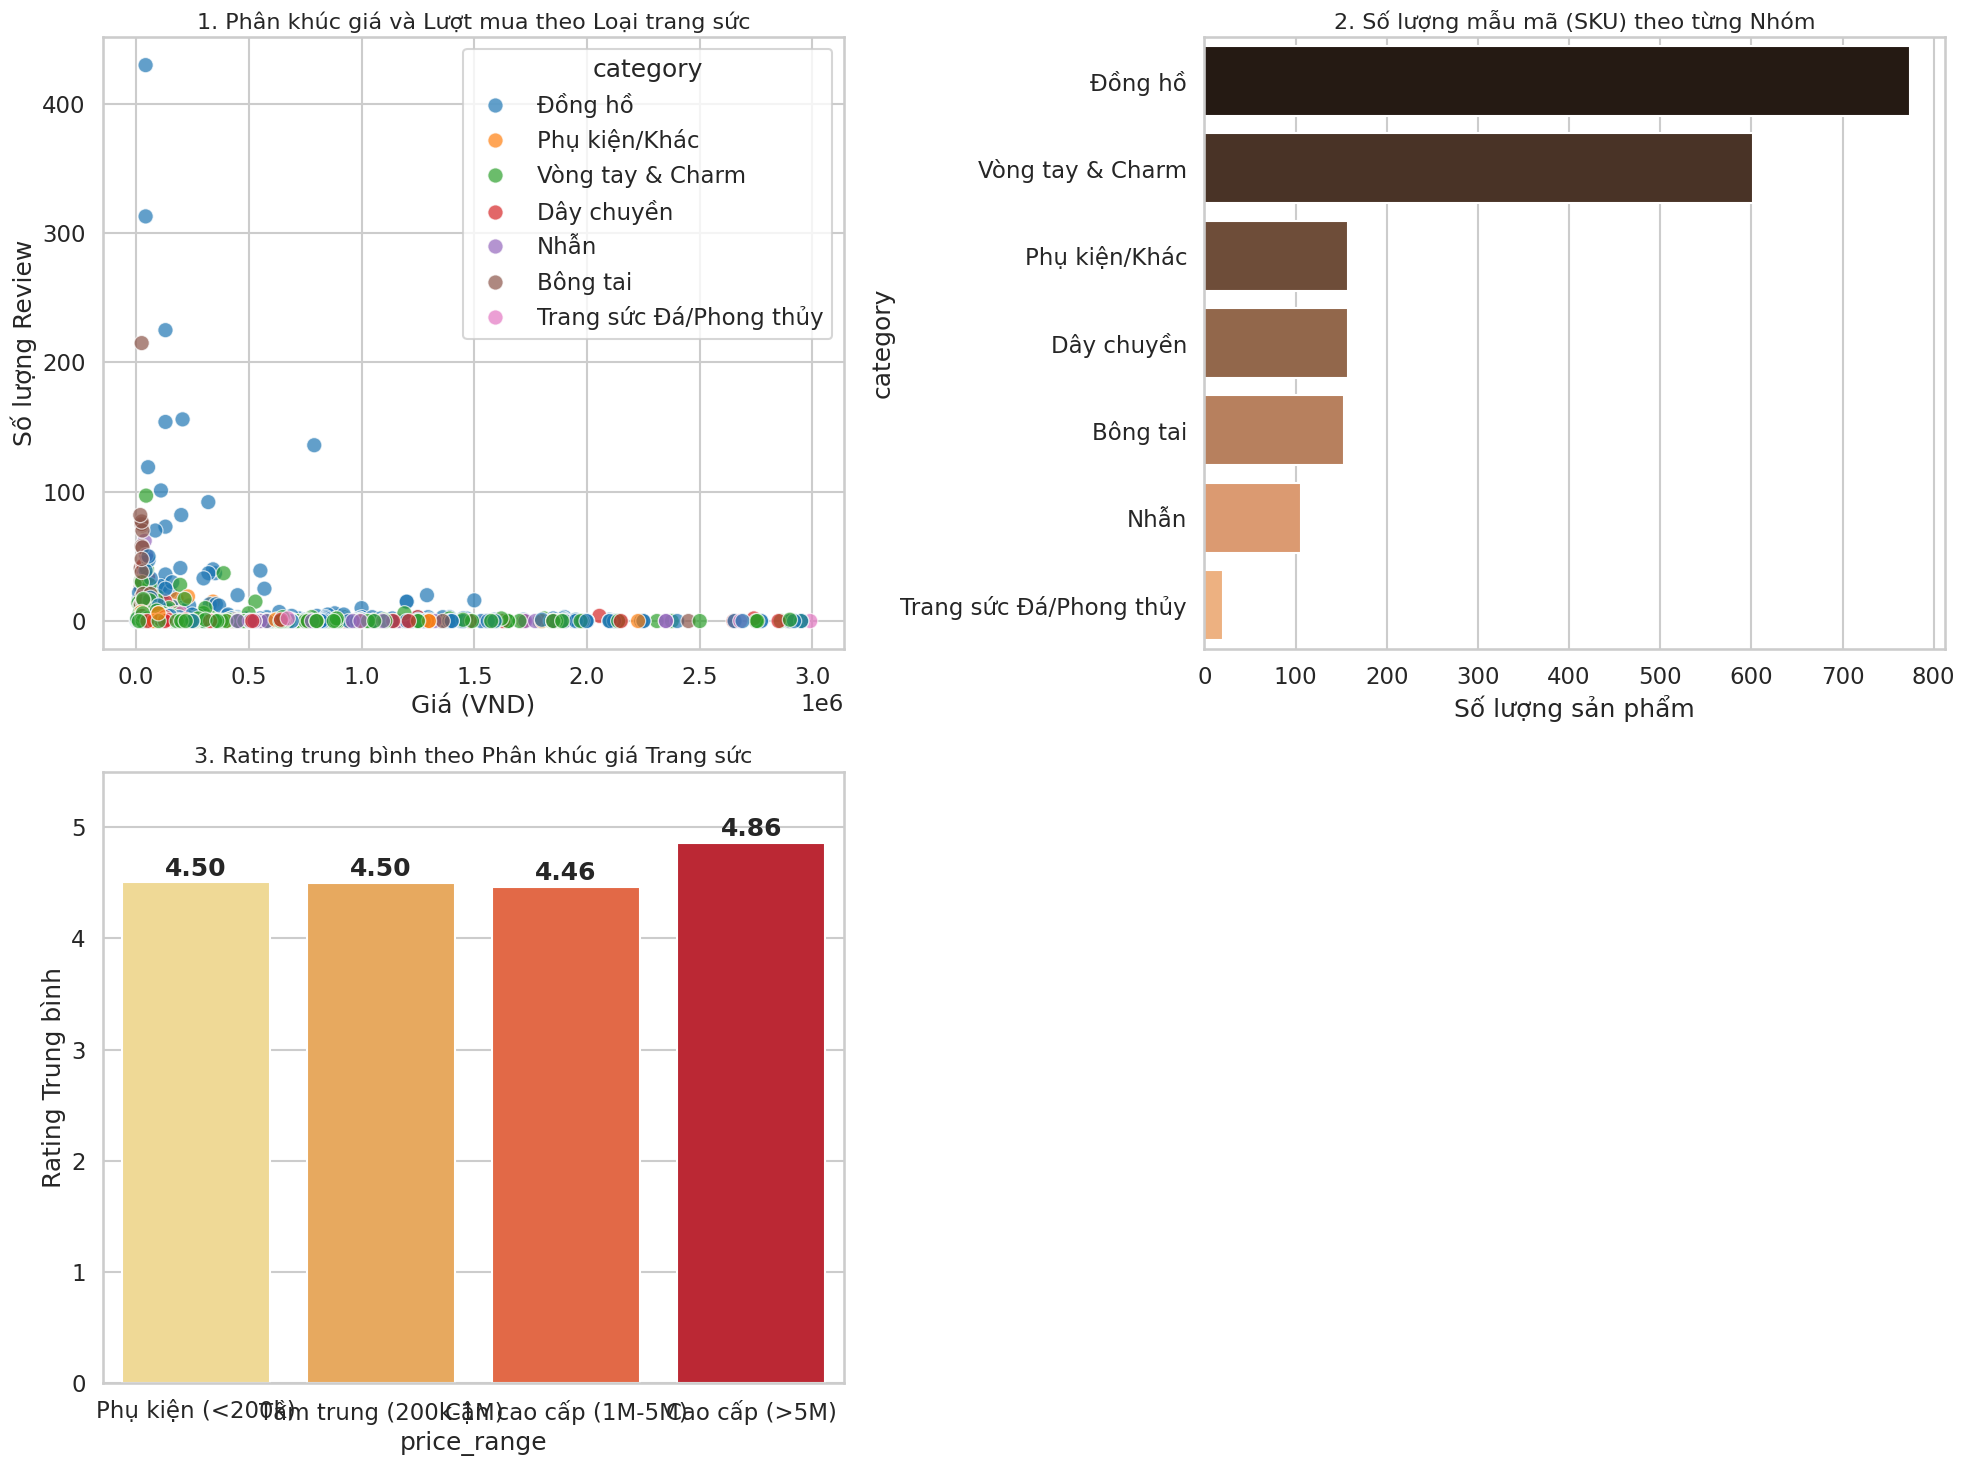

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_dong_ho_trang_suc_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH ĐỒNG HỒ & TRANG SỨC ---
def categorize_jewelry(name):
    name = str(name).lower()
    if any(k in name for k in ['đồng hồ', 'watch', 'casio', 'dây da']): return 'Đồng hồ'
    if any(k in name for k in ['vòng', 'chuỗi', 'charm', 'lắc']): return 'Vòng tay & Charm'
    if any(k in name for k in ['chuyền', 'mặt dây']): return 'Dây chuyền'
    if 'nhẫn' in name: return 'Nhẫn'
    if 'bông tai' in name or 'khuyên' in name: return 'Bông tai'
    if any(k in name for k in ['thạch', 'ngọc', 'phong thủy', 'cẩm thạch']): return 'Trang sức Đá/Phong thủy'
    return 'Phụ kiện/Khác'

df['category'] = df['name'].apply(categorize_jewelry)

# Phân khúc giá (Phù hợp với đặc thù đồ trang sức)
bins = [0, 200000, 1000000, 5000000, float('inf')]
labels = ['Phụ kiện (<200k)', 'Tầm trung (200k-1M)', 'Cận cao cấp (1M-5M)', 'Cao cấp (>5M)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df[df['price'] < 5000000]['price'], kde=True, color='goldenrod')
plt.title('Phân bổ giá (Dưới 5tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='peru')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='orange')
plt.title('Rating Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['log_review'], kde=True, color='brown')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='darkgoldenrod')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 5000000], alpha=0.3, color='goldenrod')
plt.title('Price vs Rating')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3, color='peru')
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='YlOrBr', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='YlOrBr_r')
plt.title('Top 10 Sản phẩm Trang sức phổ biến nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (HOÀN THIỆN DASHBOARD)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Nhóm (Xác định phân khúc chủ lực của từng loại)
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 3000000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Phân khúc giá và Lượt mua theo Loại trang sức', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu SKU (Độ đa dạng danh mục)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='copper')
plt.title('2. Số lượng mẫu mã (SKU) theo từng Nhóm', fontsize=16)
plt.xlabel('Số lượng sản phẩm')

# Biểu đồ 3: Chất lượng Rating trung bình theo Phân khúc giá
plt.subplot(2, 2, 3)
# Lọc bỏ các sản phẩm chưa có review để đảm bảo tính khách quan
valid_df = df[df['review_count'] > 0]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='YlOrRd')

# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá Trang sức', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

5. Giày dép nam

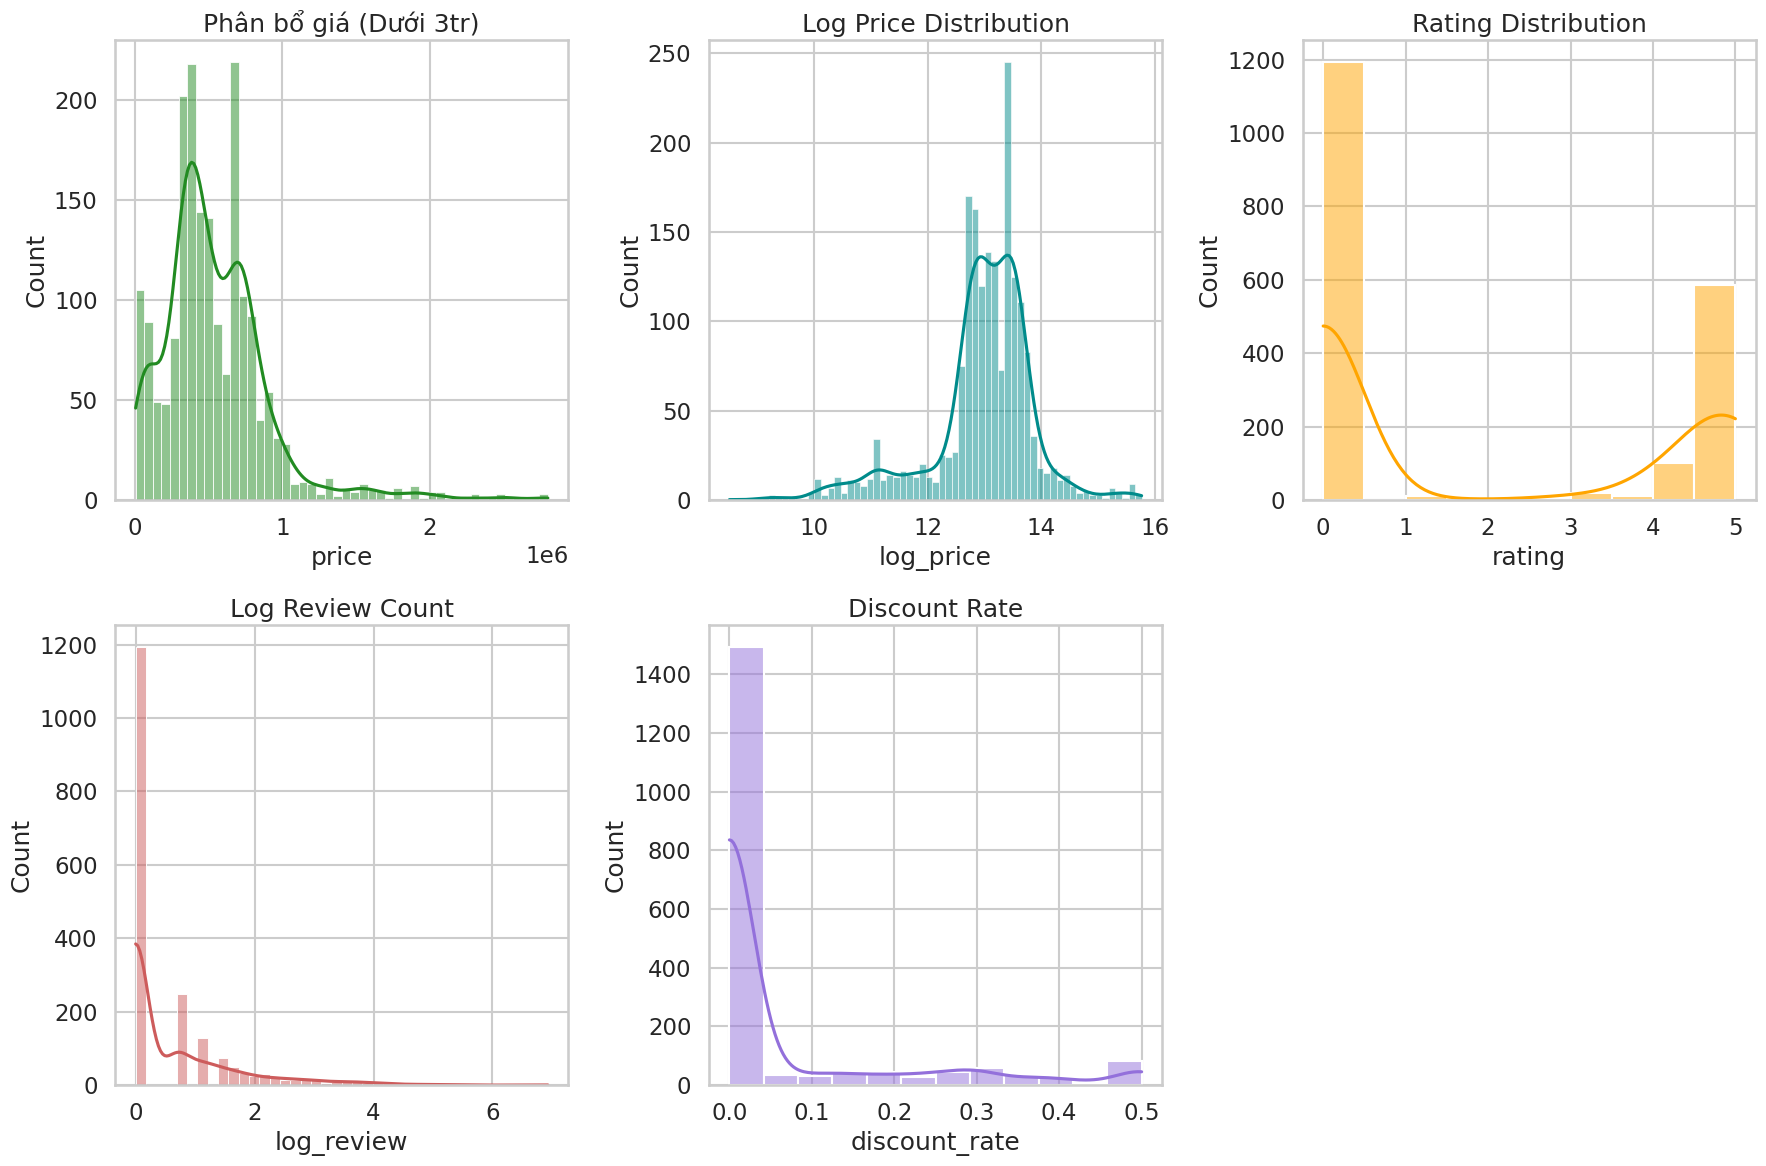

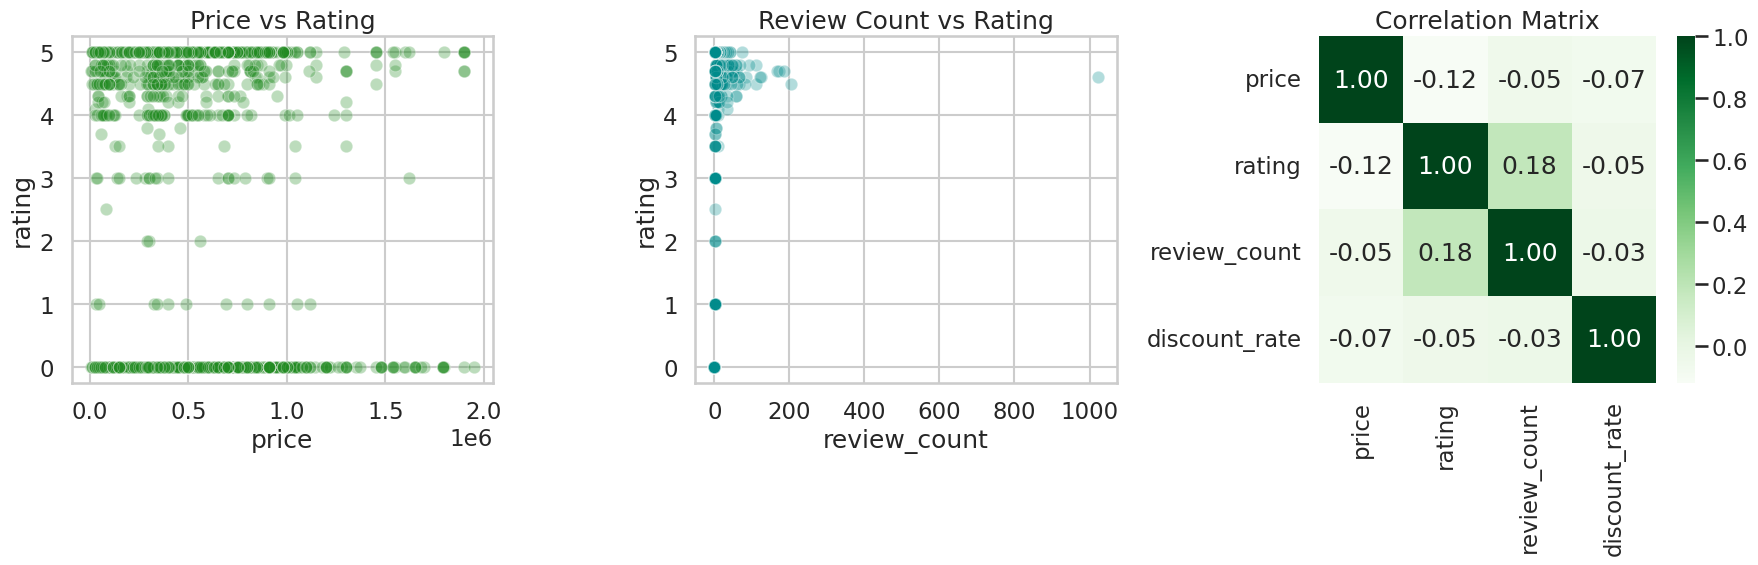

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3654099726.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='Greens_r')


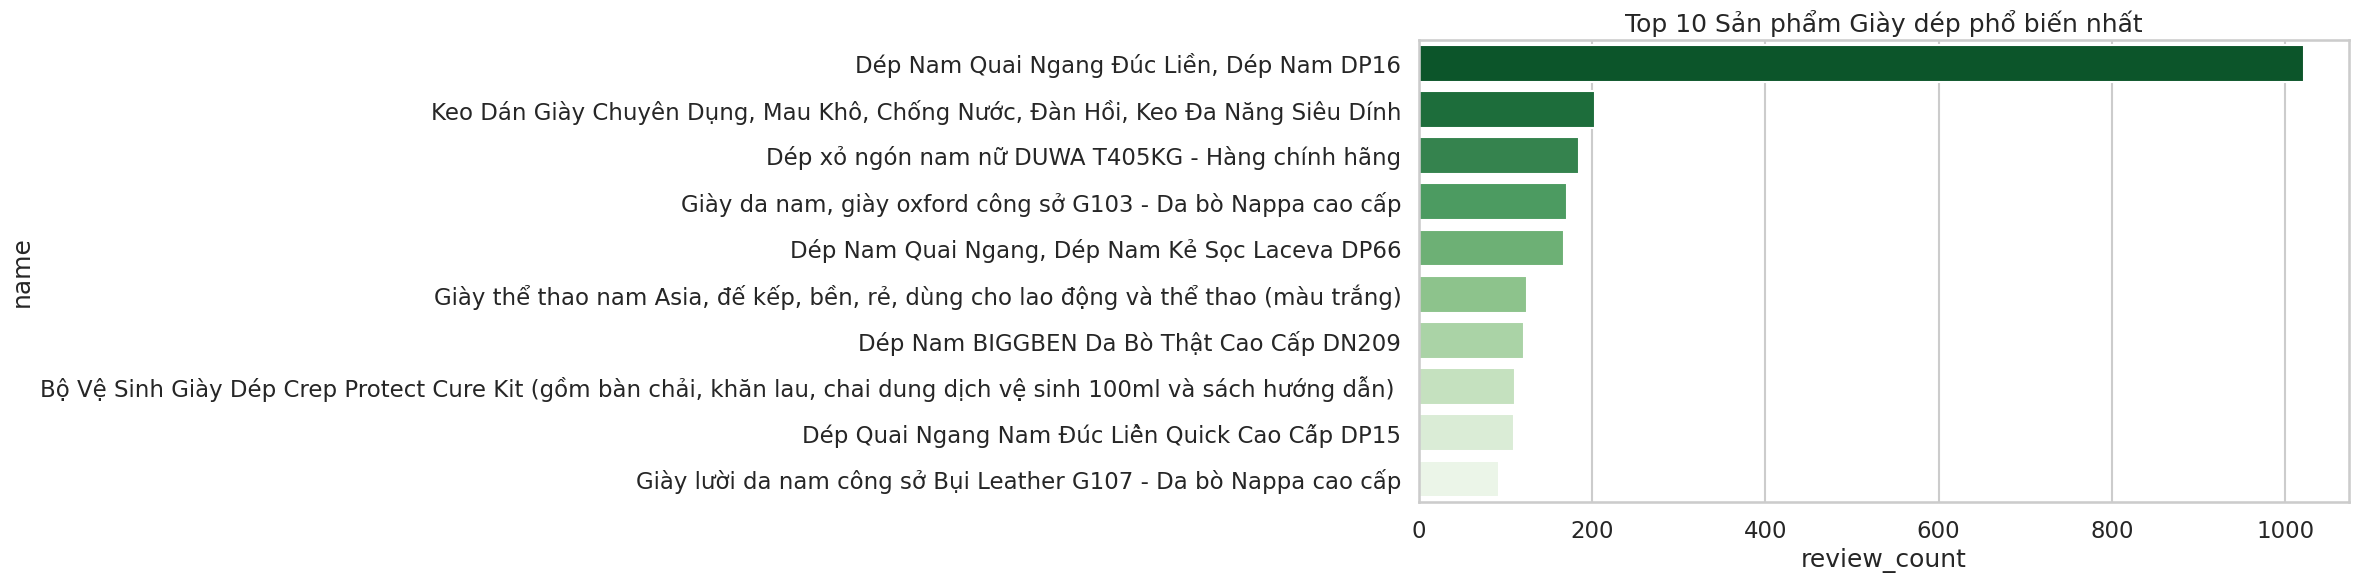

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3654099726.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='magma')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3654099726.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\3654099726.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_rati

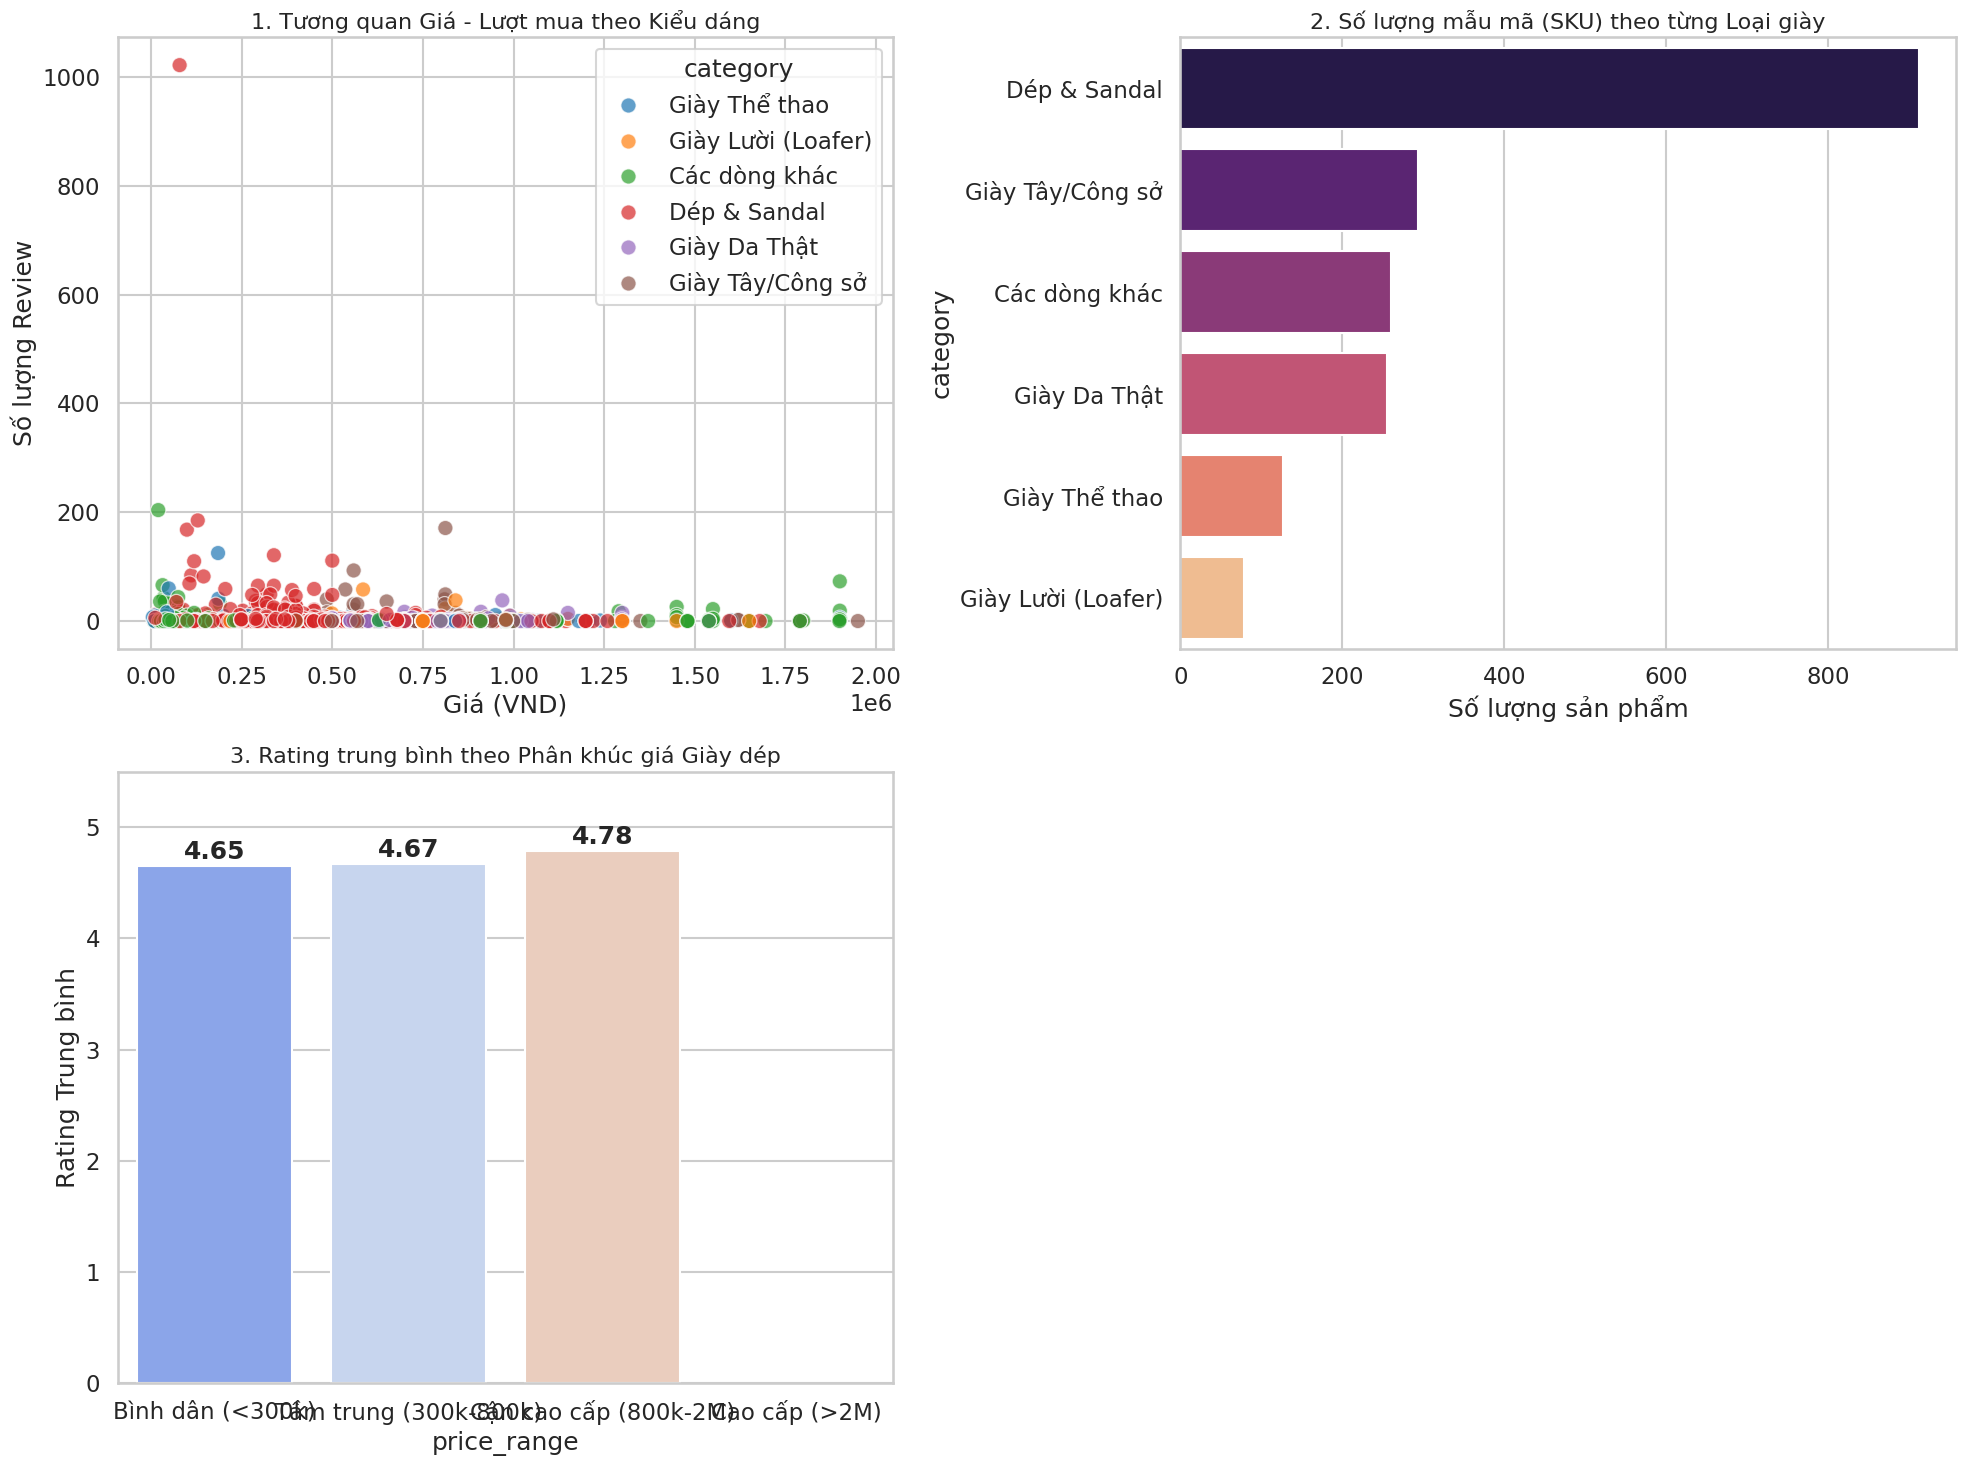

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện chuẩn Dashboard
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_giay_dep_nam_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH GIÀY DÉP NAM ---
def categorize_footwear(name):
    name = str(name).lower()
    if any(k in name for k in ['thao', 'sneaker', 'chạy bộ', 'gym']): return 'Giày Thể thao'
    if any(k in name for k in ['tây', 'công sở', 'oxford', 'derby']): return 'Giày Tây/Công sở'
    if any(k in name for k in ['lười', 'loafer', 'moca']): return 'Giày Lười (Loafer)'
    if any(k in name for k in ['dép', 'sandal', 'quai', 'xỏ ngón']): return 'Dép & Sandal'
    if any(k in name for k in ['da thật', 'da bò', 'da cá sấu']): return 'Giày Da Thật'
    return 'Các dòng khác'

df['category'] = df['name'].apply(categorize_footwear)

# Phân khúc giá thực tế cho Giày dép nam
bins = [0, 300000, 800000, 2000000, float('inf')]
labels = ['Bình dân (<300k)', 'Tầm trung (300k-800k)', 'Cận cao cấp (800k-2M)', 'Cao cấp (>2M)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df[df['price'] < 3000000]['price'], kde=True, color='forestgreen')
plt.title('Phân bổ giá (Dưới 3tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='darkcyan')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='orange')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='indianred')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='mediumpurple')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 2000000], alpha=0.3, color='forestgreen')
plt.title('Price vs Rating')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3, color='darkcyan')
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='Greens', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='Greens_r')
plt.title('Top 10 Sản phẩm Giày dép phổ biến nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (ĐÁNH GIÁ CHUYÊN SÂU)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Nhóm (Tìm "Phân khúc vàng" của từng kiểu giày)
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 2000000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Tương quan Giá - Lượt mua theo Kiểu dáng', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu SKU (Danh mục hàng hóa đang tập trung vào đâu?)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='magma')
plt.title('2. Số lượng mẫu mã (SKU) theo từng Loại giày', fontsize=16)
plt.xlabel('Số lượng sản phẩm')

# Biểu đồ 3: Sự hài lòng (Rating) theo Phân khúc giá
plt.subplot(2, 2, 3)
# Lọc các sản phẩm có dữ liệu đánh giá thực tế
valid_df = df[df['review_count'] > 2]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='coolwarm')

# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá Giày dép', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

6. Giày dép nữ

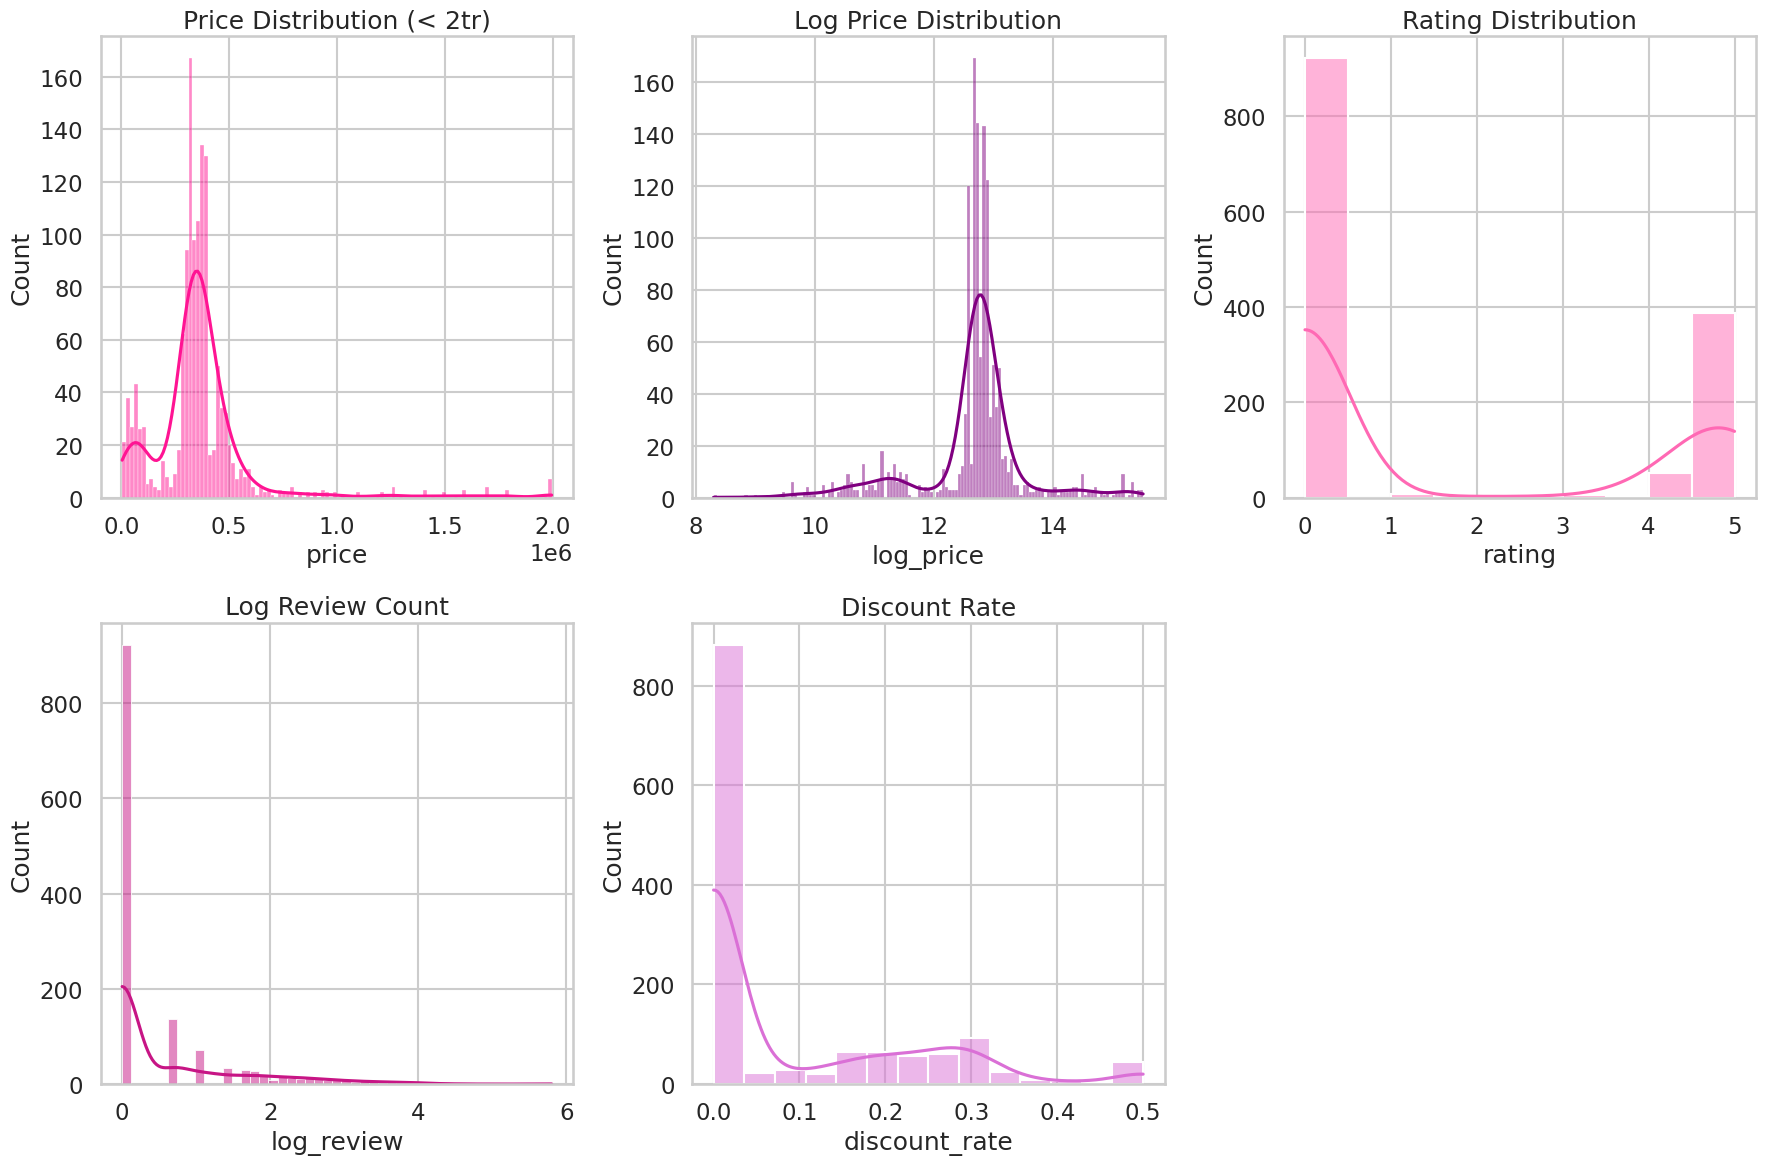

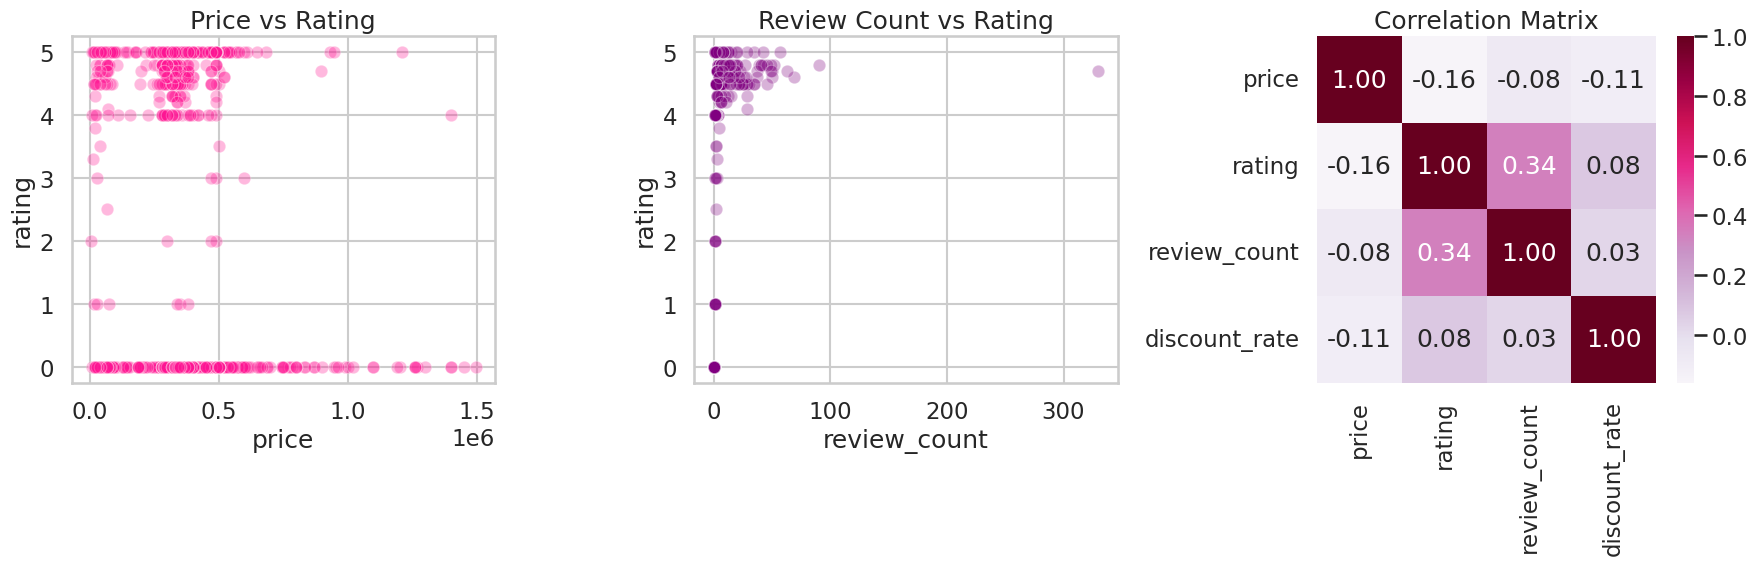

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1495283013.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='PuRd_r')


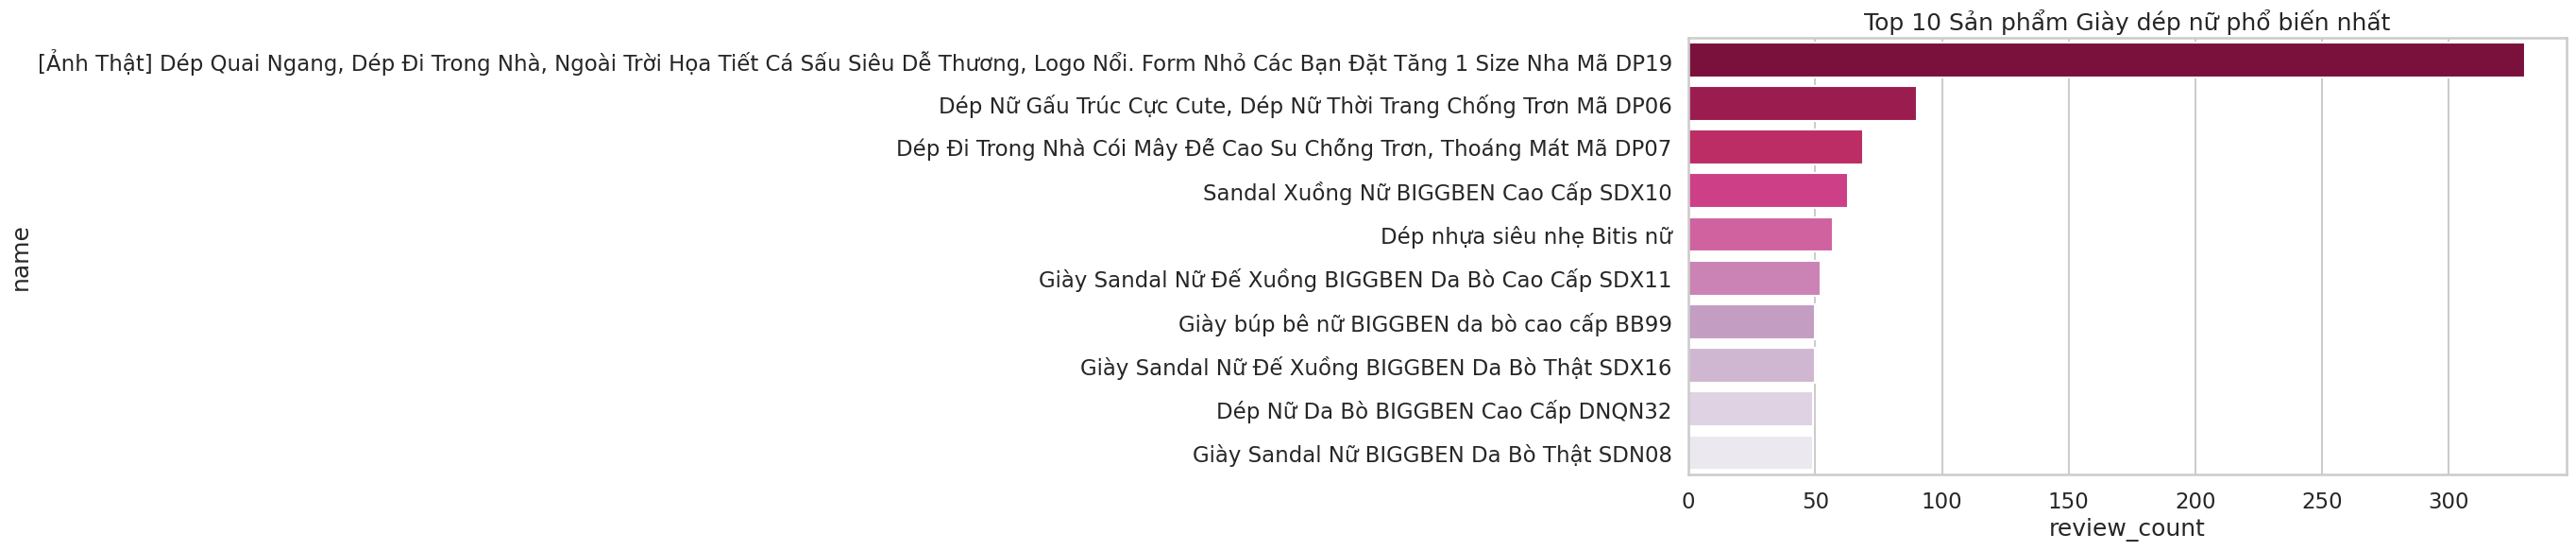

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1495283013.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='flare')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1495283013.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1495283013.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_rati

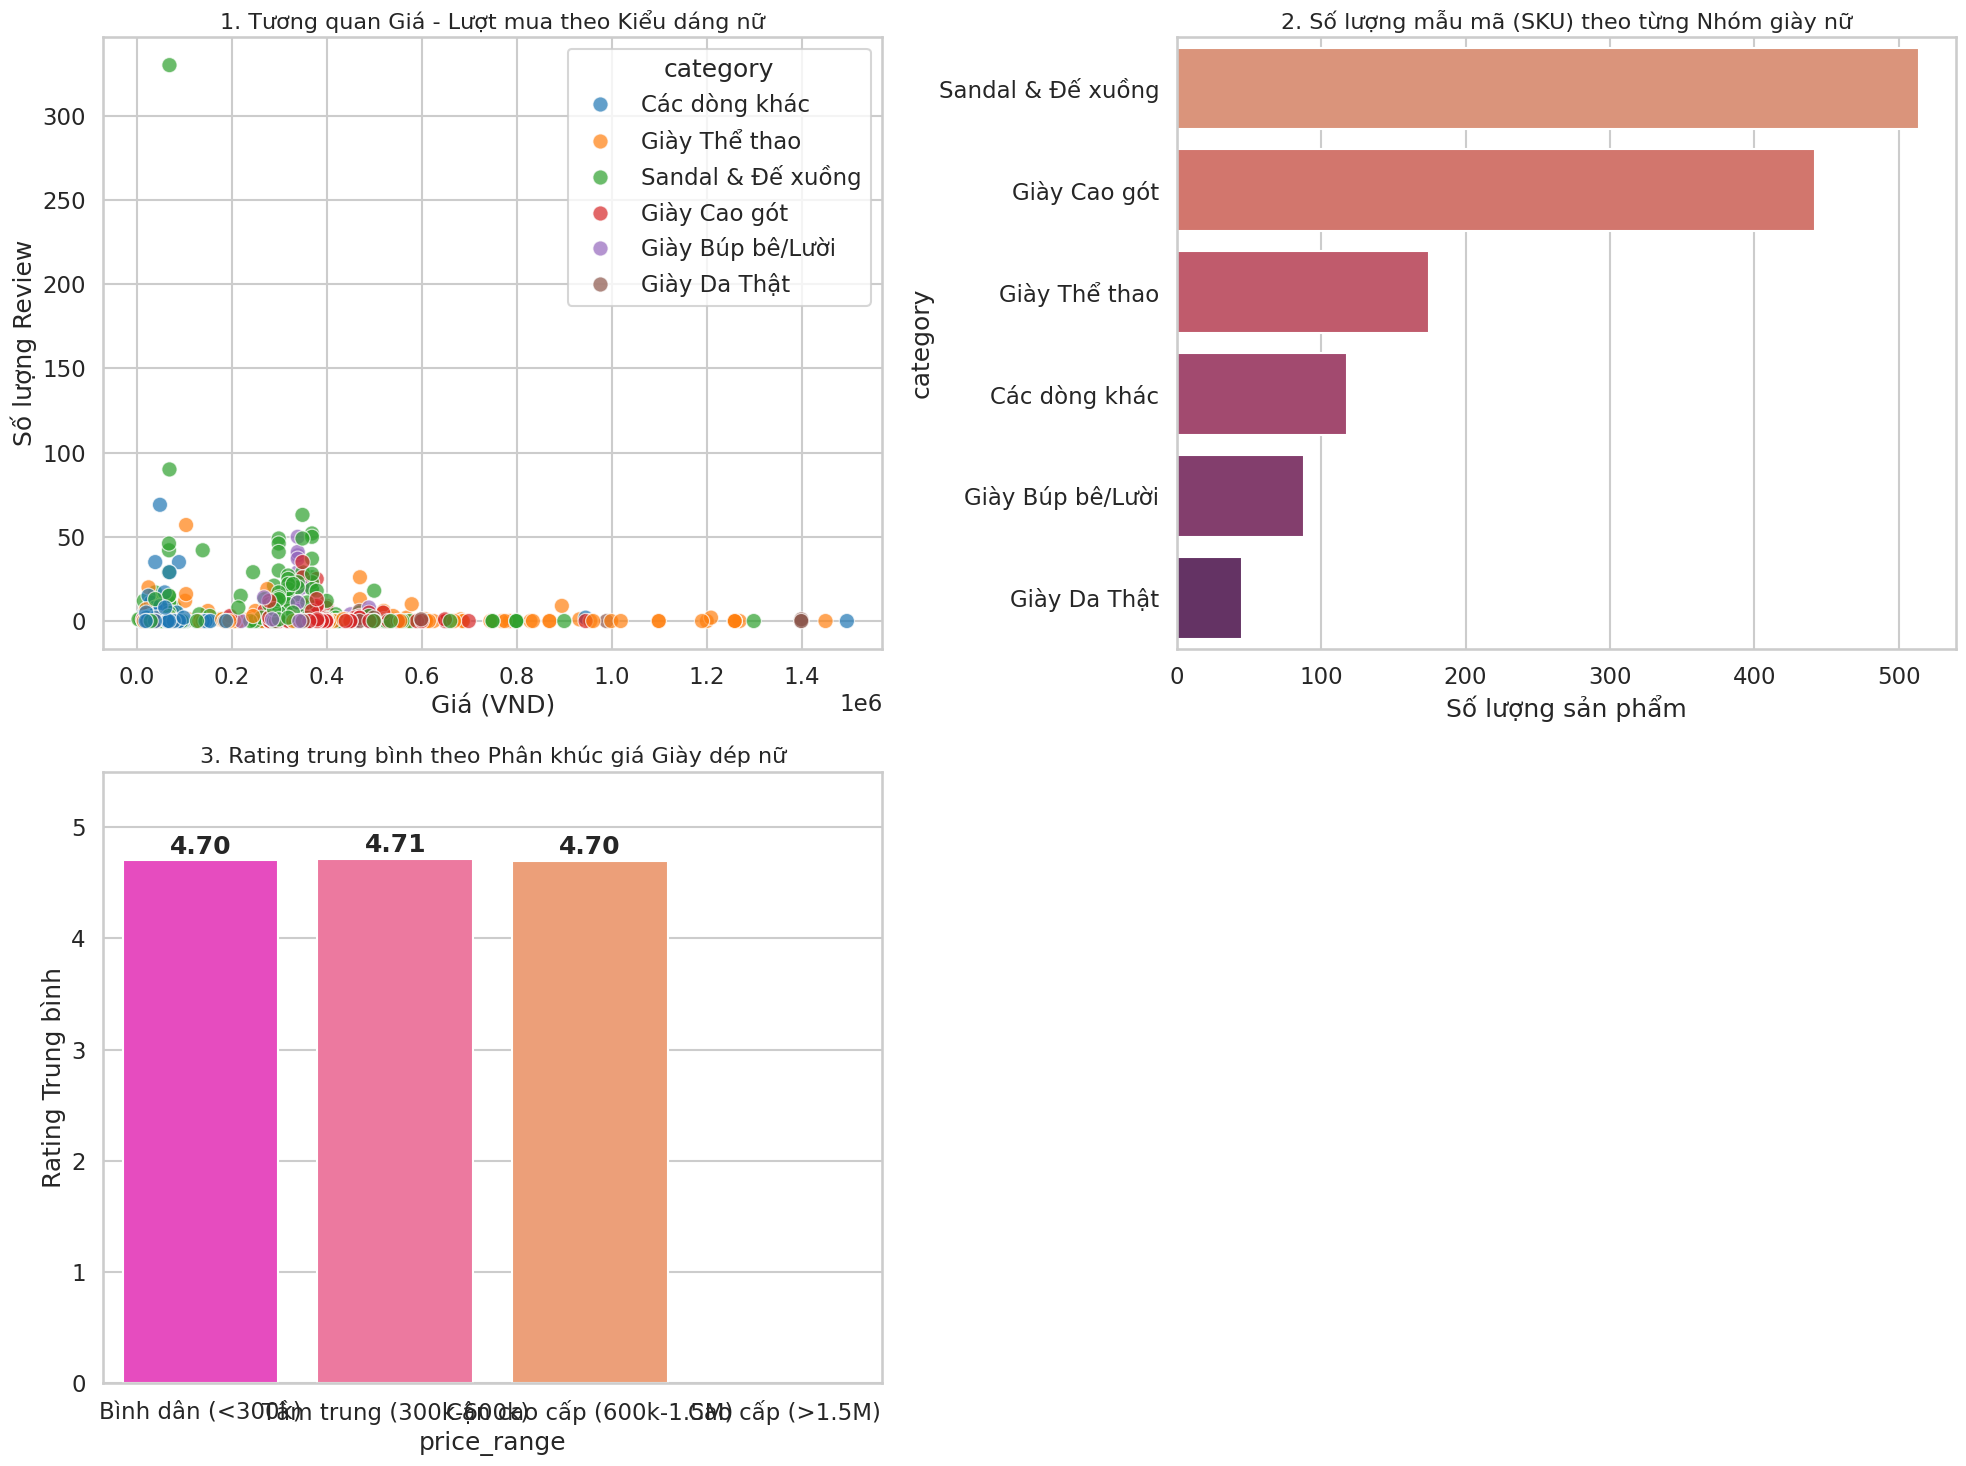

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện chuẩn Dashboard
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_giay_dep_nu_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH GIÀY DÉP NỮ ---
def categorize_women_footwear(name):
    name = str(name).lower()
    if any(k in name for k in ['cao gót', 'mũi nhọn', 'gót trụ', 'rosata', '5 phân']): return 'Giày Cao gót'
    if any(k in name for k in ['thao', 'sneaker', 'hunter', 'biti']): return 'Giày Thể thao'
    if any(k in name for k in ['sandal', 'đế xuồng', 'quai', 'xỏ ngón', 'dép']): return 'Sandal & Đế xuồng'
    if any(k in name for k in ['búp bê', 'lười', 'moca', 'flat']): return 'Giày Búp bê/Lười'
    if any(k in name for k in ['da bò', 'da thật', 'huy hoàng']): return 'Giày Da Thật'
    return 'Các dòng khác'

df['category'] = df['name'].apply(categorize_women_footwear)

# Phân khúc giá thực tế cho Giày dép nữ
bins = [0, 300000, 600000, 1500000, float('inf')]
labels = ['Bình dân (<300k)', 'Tầm trung (300k-600k)', 'Cận cao cấp (600k-1.5M)', 'Cao cấp (>1.5M)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df[df['price'] < 2000000]['price'], kde=True, color='deeppink')
plt.title('Price Distribution (< 2tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='purple')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='hotpink')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='mediumvioletred')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='orchid')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 1500000], alpha=0.3, color='deeppink')
plt.title('Price vs Rating')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3, color='purple')
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='PuRd', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='PuRd_r')
plt.title('Top 10 Sản phẩm Giày dép nữ phổ biến nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (ĐÁNH GIÁ CHUYÊN SÂU)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Loại (Tìm phân khúc "ăn khách" nhất)
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 1500000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Tương quan Giá - Lượt mua theo Kiểu dáng nữ', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: SKU Distribution (Sự đa dạng mẫu mã)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='flare')
plt.title('2. Số lượng mẫu mã (SKU) theo từng Nhóm giày nữ', fontsize=16)
plt.xlabel('Số lượng sản phẩm')

# Biểu đồ 3: Rating trung bình theo Phân khúc giá
plt.subplot(2, 2, 3)
valid_df = df[df['review_count'] > 2]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='spring')

# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá Giày dép nữ', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

7. Laptop-máy tính-linh kiện

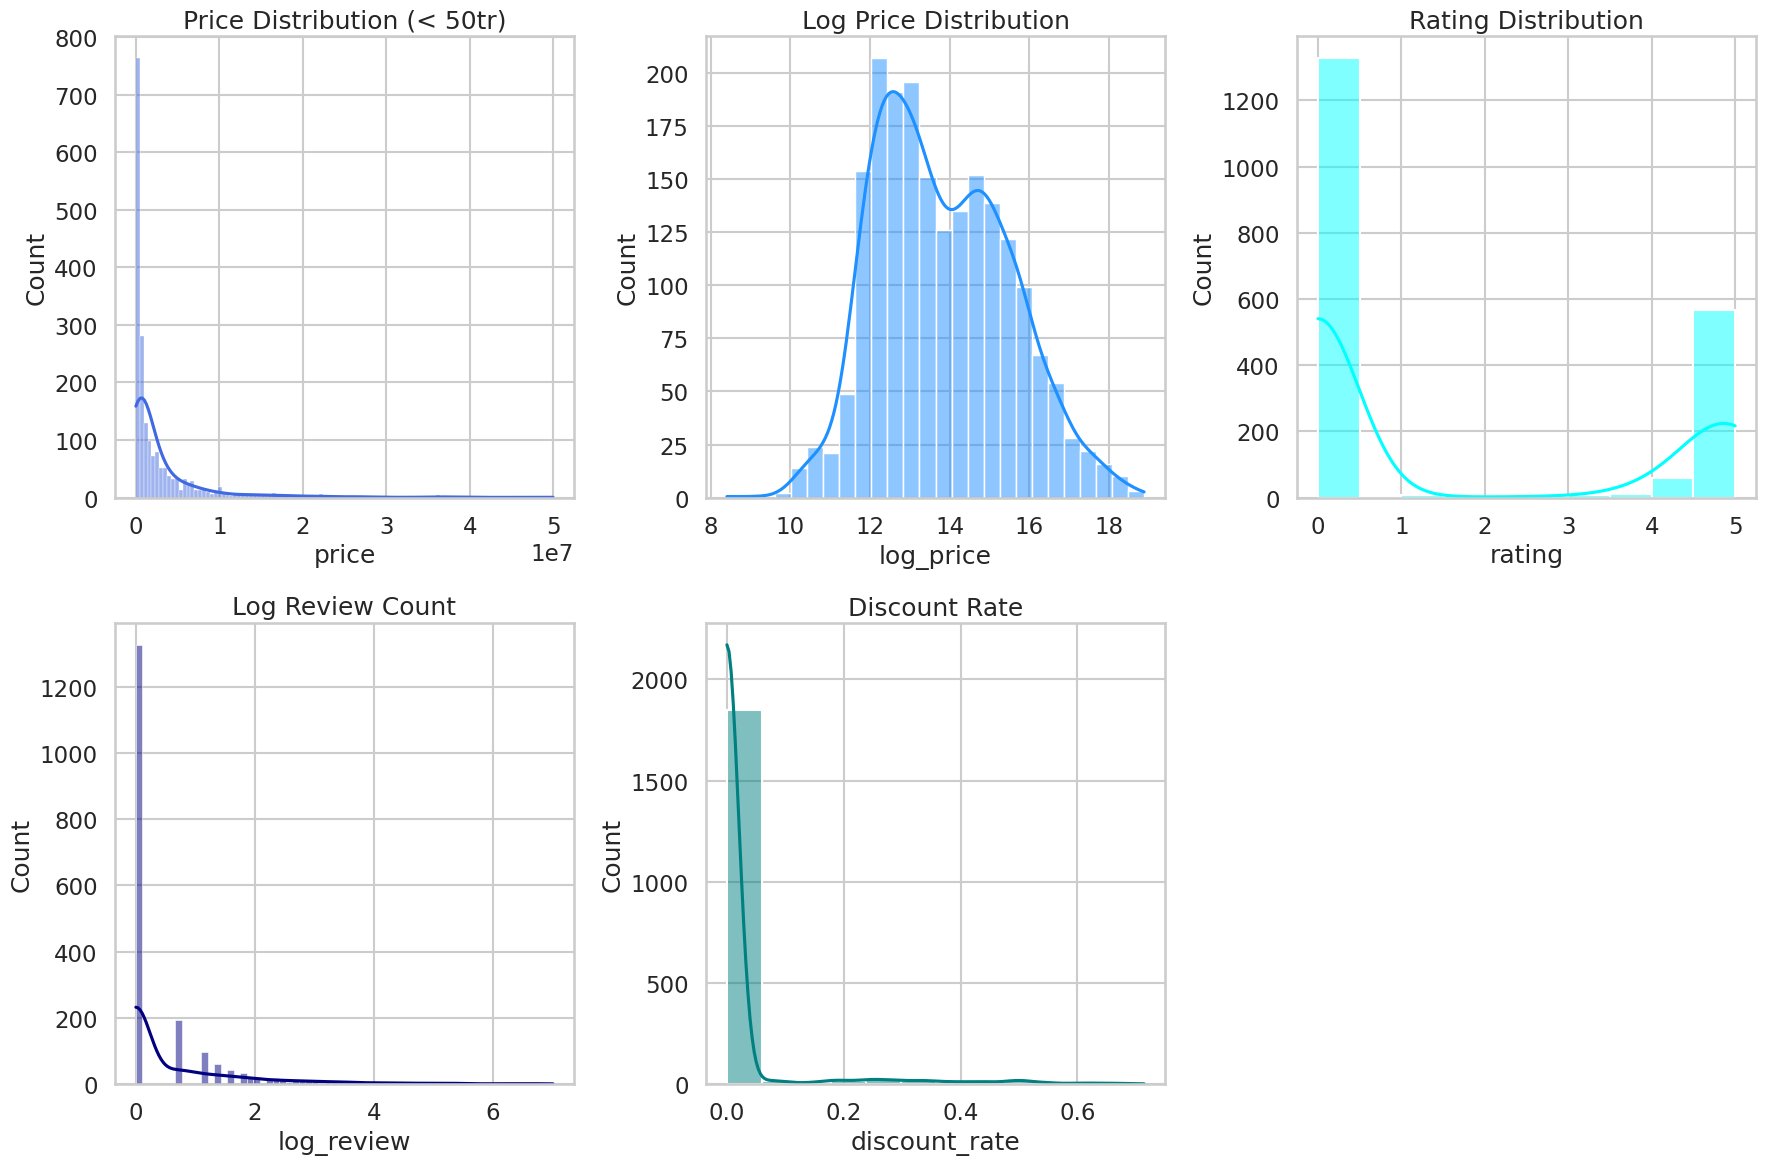

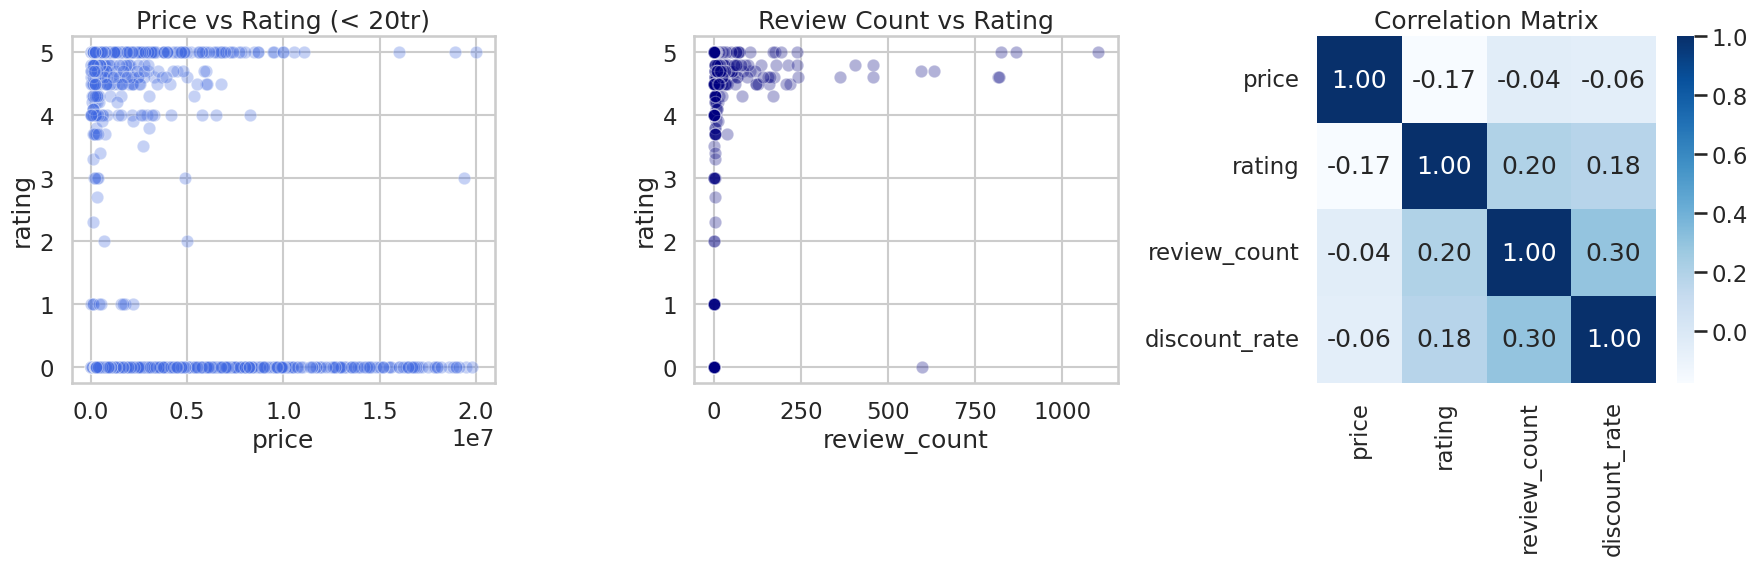

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2675231205.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='Blues_r')


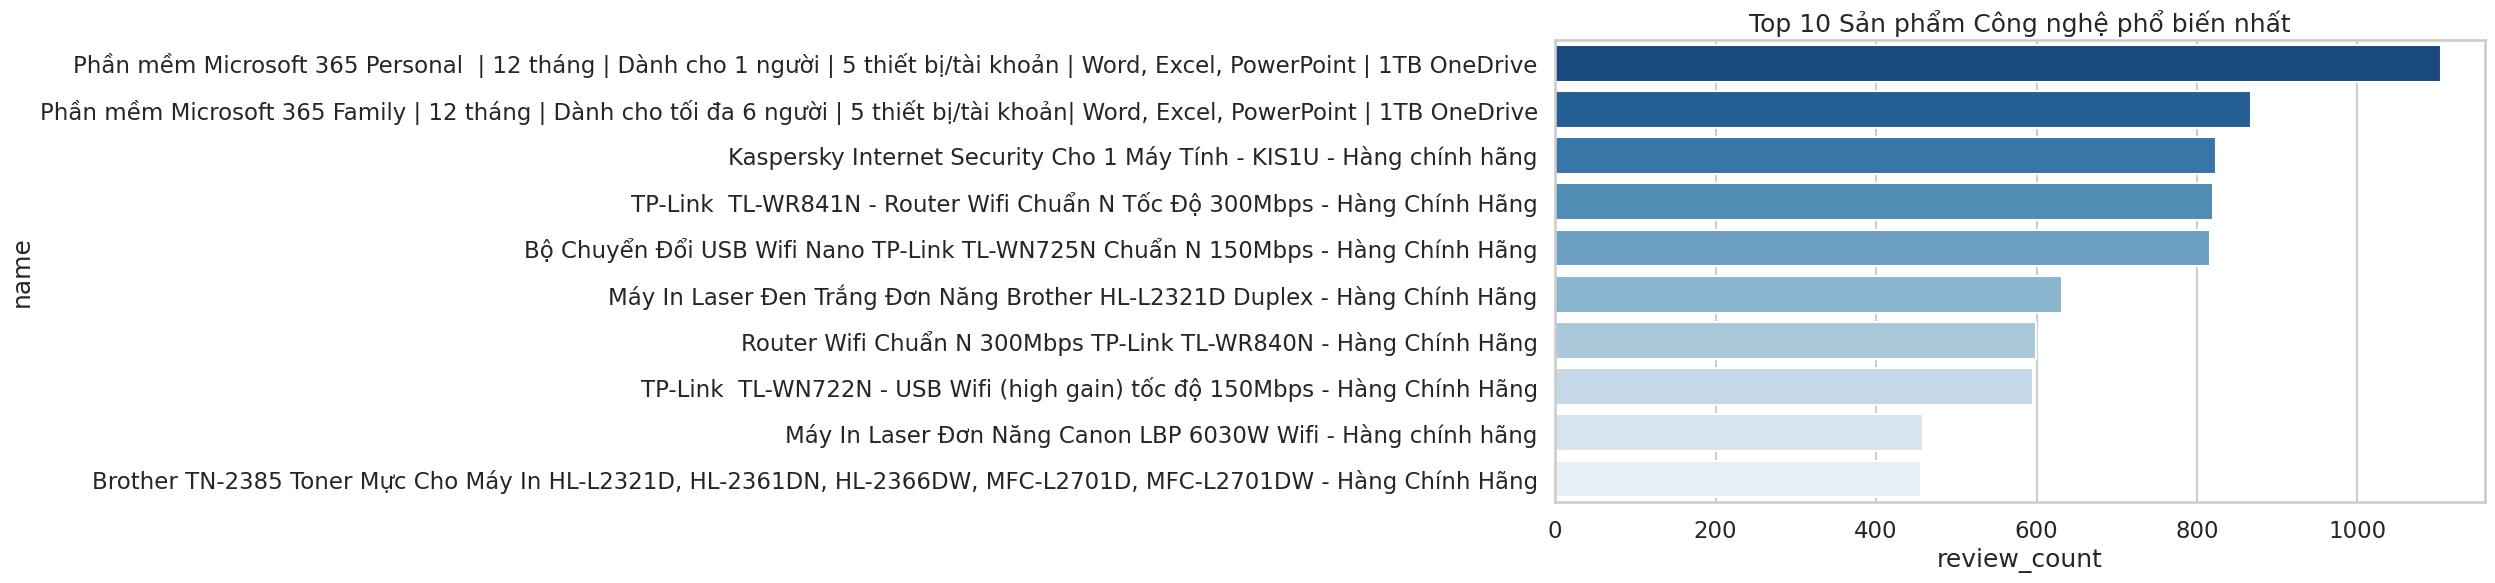

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2675231205.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='mako')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2675231205.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\2675231205.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_ratin

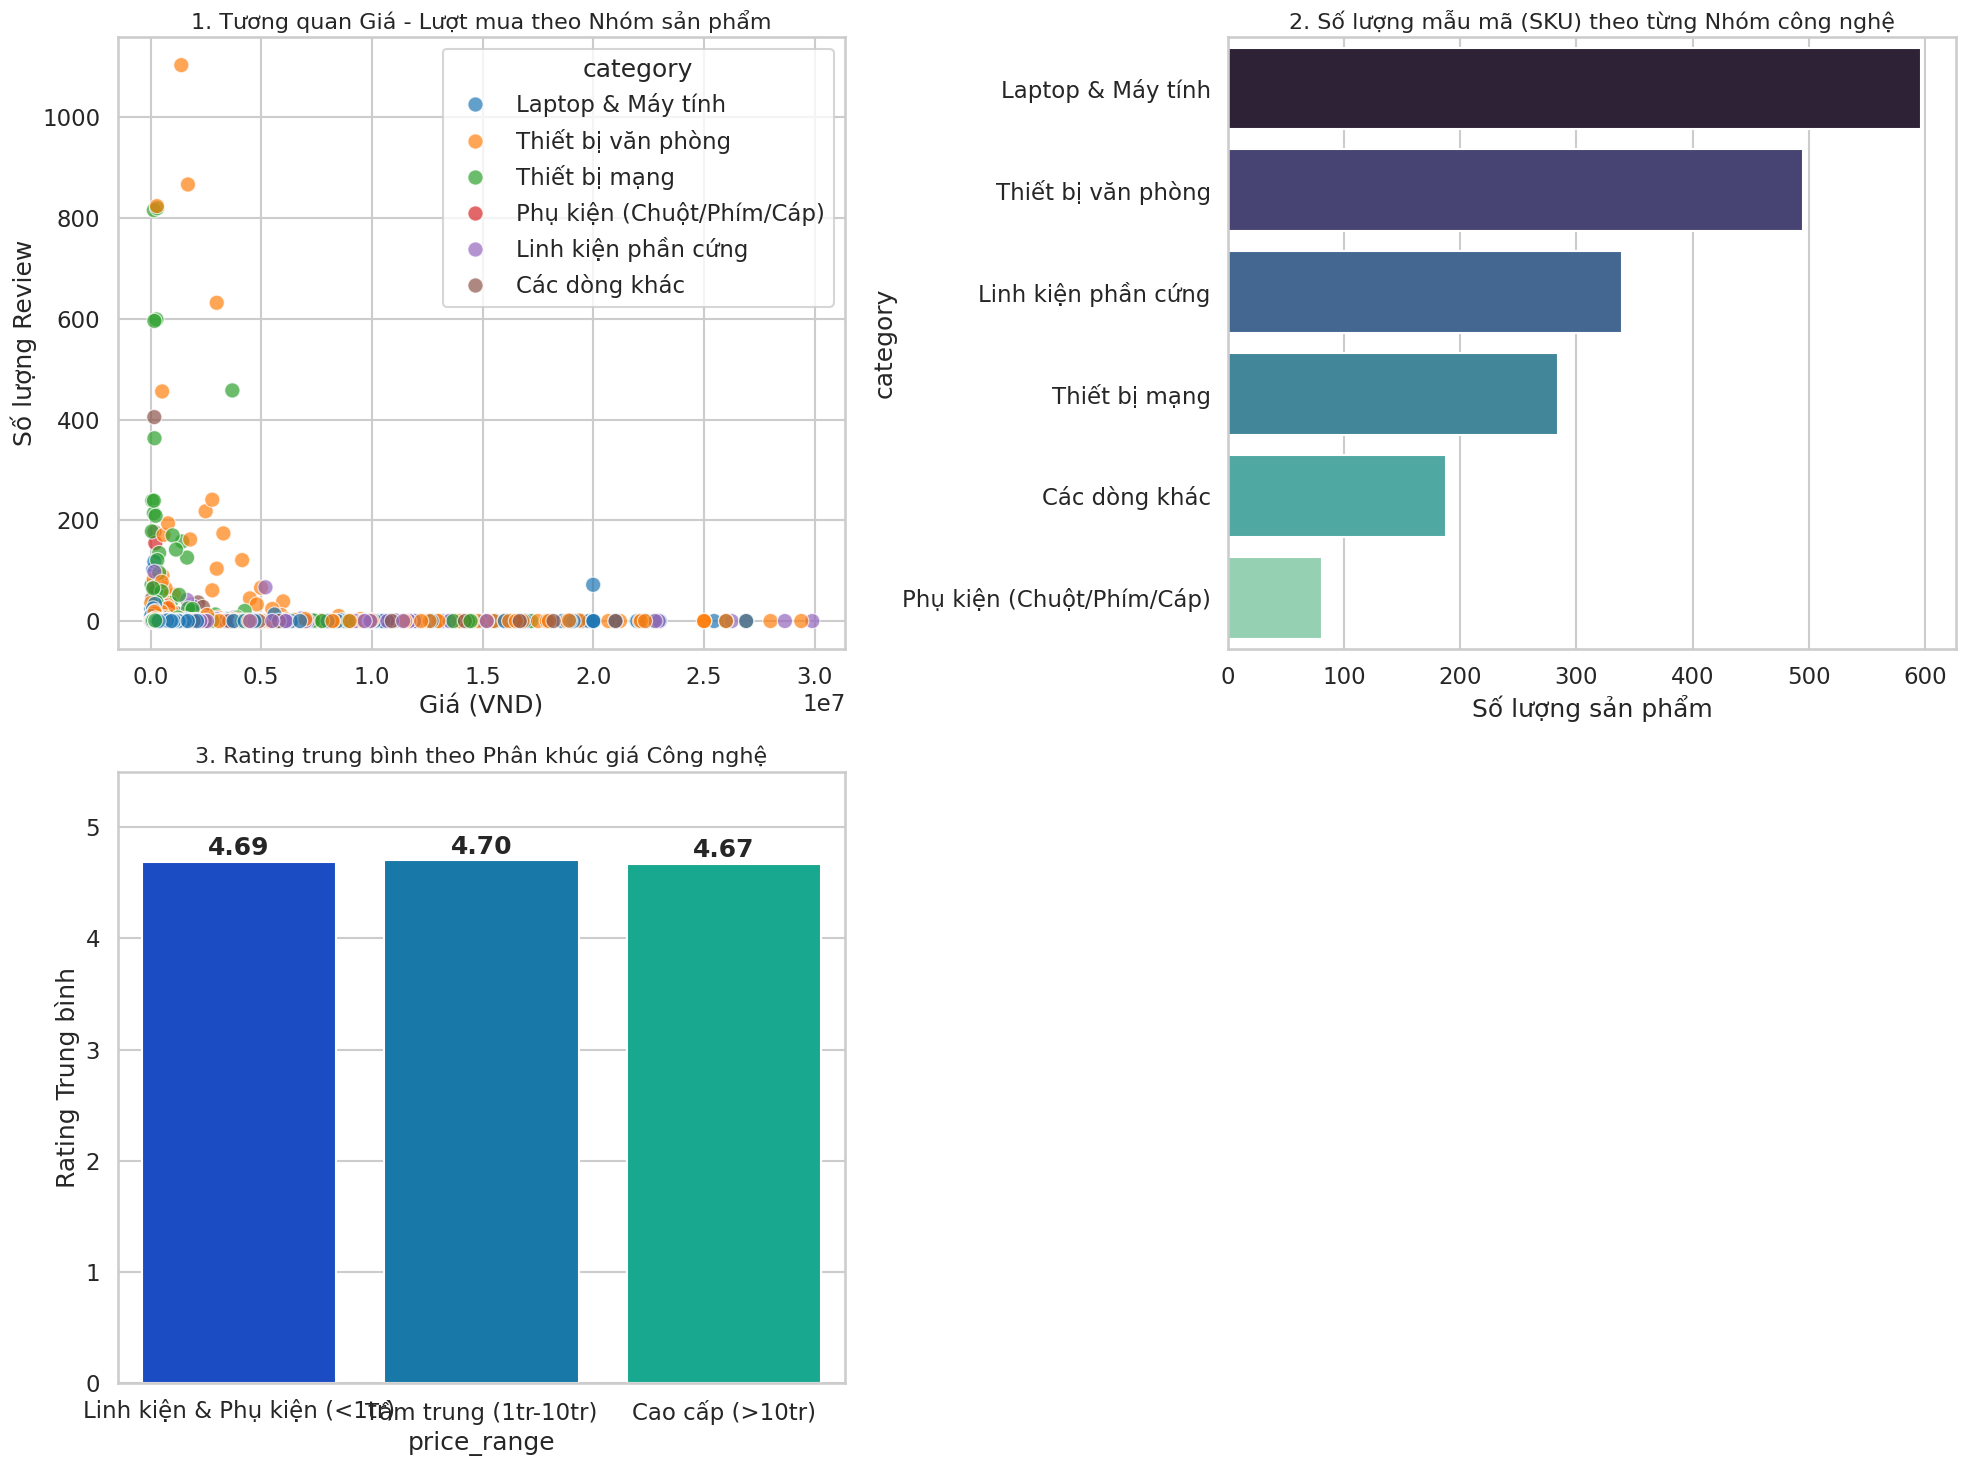

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện chuẩn Dashboard
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_laptop_may_tinh_linh_kien_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH CÔNG NGHỆ ---
def categorize_tech(name):
    name = str(name).lower()
    if any(k in name for k in ['laptop', 'macbook', 'dell', 'asus', 'hp', 'lenovo', 'core']): return 'Laptop & Máy tính'
    if any(k in name for k in ['cứng', 'ssd', 'ram', 'màn hình', 'card', 'mainboard']): return 'Linh kiện phần cứng'
    if any(k in name for k in ['wifi', 'router', 'tp-link', 'tenda', 'mạng']): return 'Thiết bị mạng'
    if any(k in name for k in ['in', 'canon', 'brother', 'máy chiếu', 'mực']): return 'Thiết bị văn phòng'
    if any(k in name for k in ['chuột', 'bàn phím', 'mouse', 'keyboard', 'cáp', 'usb', 'sạc']): return 'Phụ kiện (Chuột/Phím/Cáp)'
    return 'Các dòng khác'

df['category'] = df['name'].apply(categorize_tech)

# Phân khúc giá thực tế cho đồ Công nghệ
bins = [0, 1000000, 10000000, float('inf')]
labels = ['Linh kiện & Phụ kiện (<1tr)', 'Tầm trung (1tr-10tr)', 'Cao cấp (>10tr)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
# Giới hạn 50tr để nhìn rõ phân bổ (vì có laptop >100tr làm lệch biểu đồ)
sns.histplot(df[df['price'] < 50000000]['price'], kde=True, color='royalblue')
plt.title('Price Distribution (< 50tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='dodgerblue')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='cyan')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='navy')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='teal')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 20000000], alpha=0.3, color='royalblue')
plt.title('Price vs Rating (< 20tr)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3, color='navy')
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='Blues_r')
plt.title('Top 10 Sản phẩm Công nghệ phổ biến nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (ĐÁNH GIÁ CHUYÊN SÂU)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Nhóm (Xác định "Chủ lực doanh số" của từng mảng)
plt.subplot(2, 2, 1)
# Giới hạn giá 30tr để xem chi tiết các sản phẩm phổ thông
sns.scatterplot(data=df[df['price'] < 30000000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Tương quan Giá - Lượt mua theo Nhóm sản phẩm', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu danh mục (Độ đa dạng sản phẩm)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='mako')
plt.title('2. Số lượng mẫu mã (SKU) theo từng Nhóm công nghệ', fontsize=16)
plt.xlabel('Số lượng sản phẩm')

# Biểu đồ 3: Rating trung bình theo Phân khúc giá (Đo lường sự hài lòng)
plt.subplot(2, 2, 3)
# Lọc bỏ các sản phẩm chưa có review
valid_df = df[df['review_count'] > 0]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='winter')

# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá Công nghệ', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

8. Nhà sách

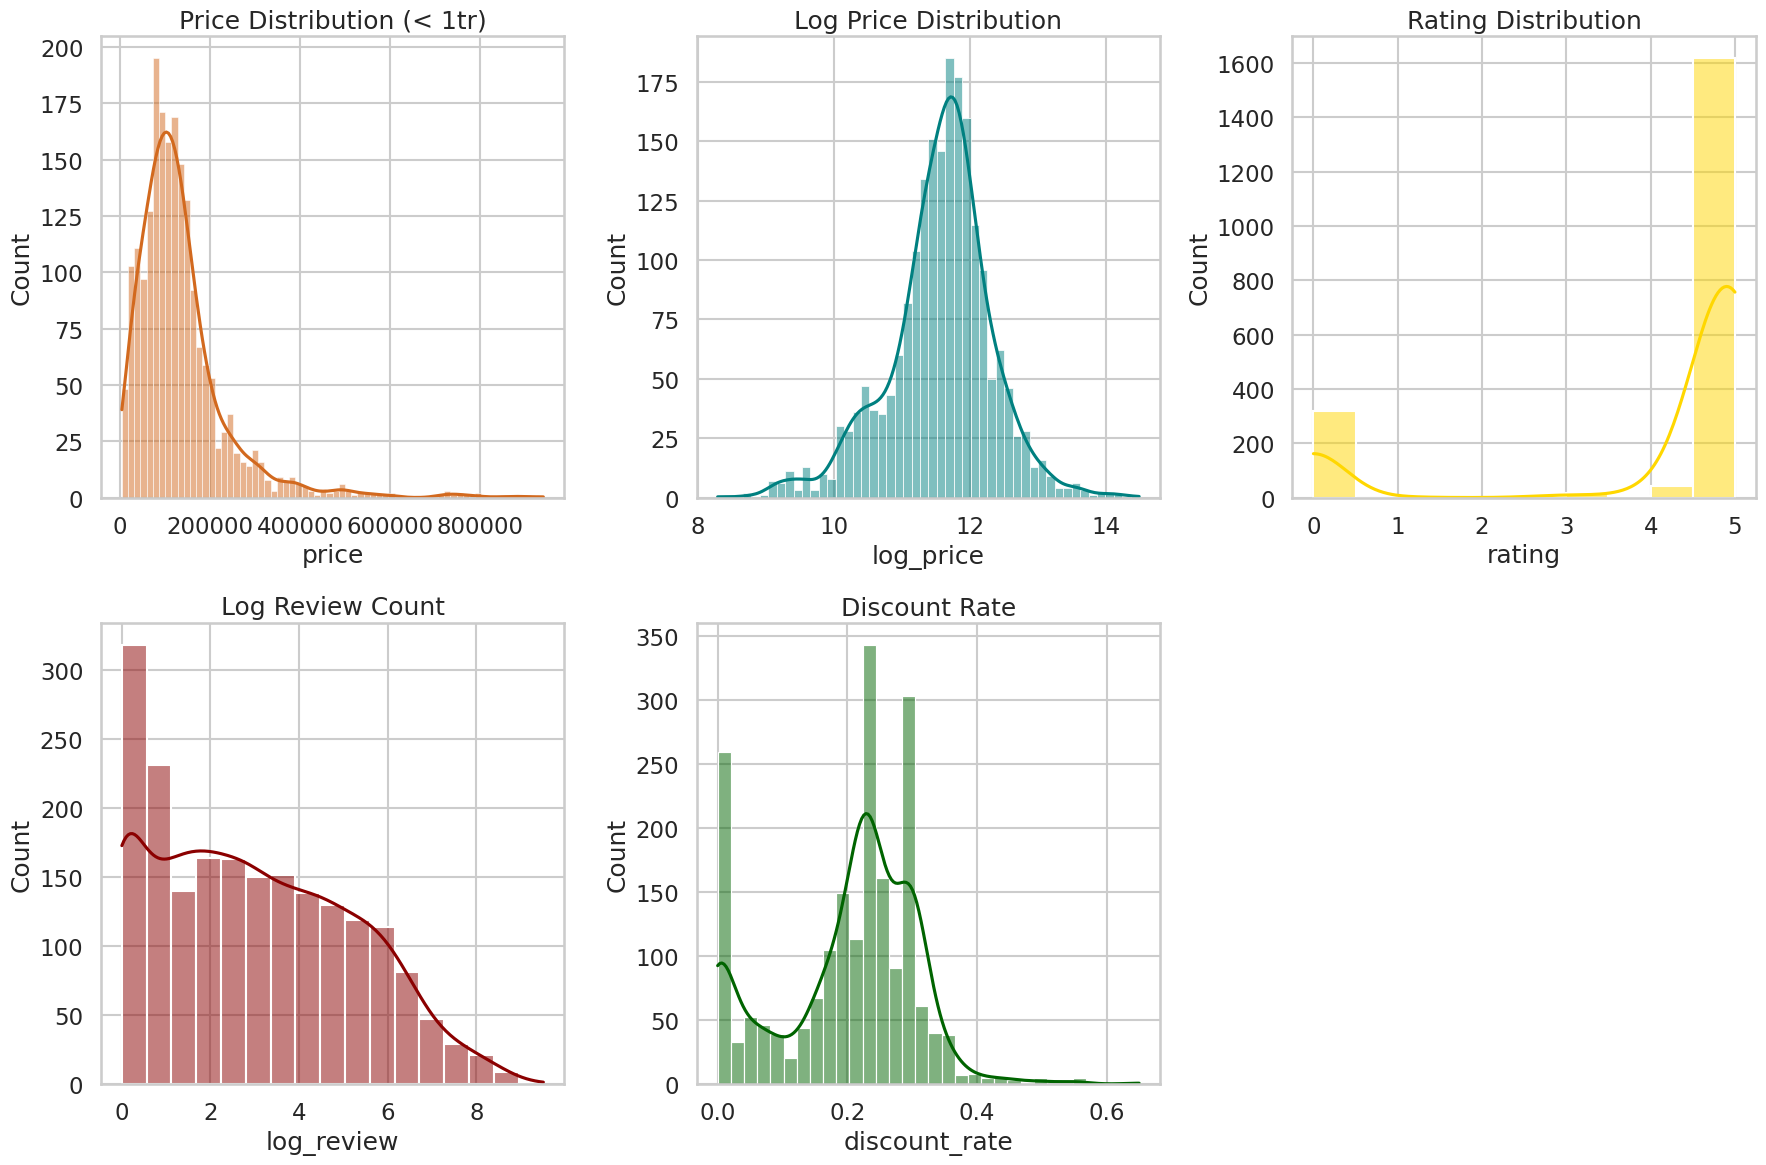

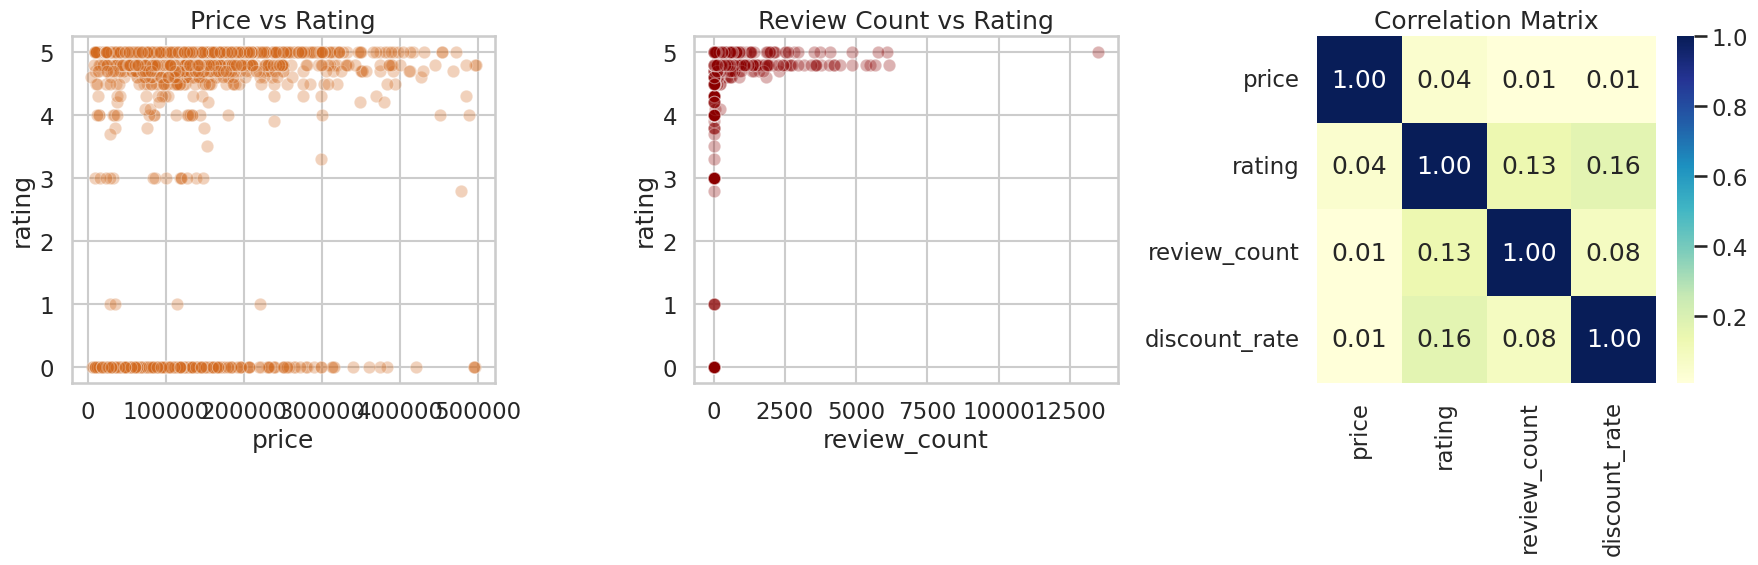

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\864511115.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='YlOrBr_r')


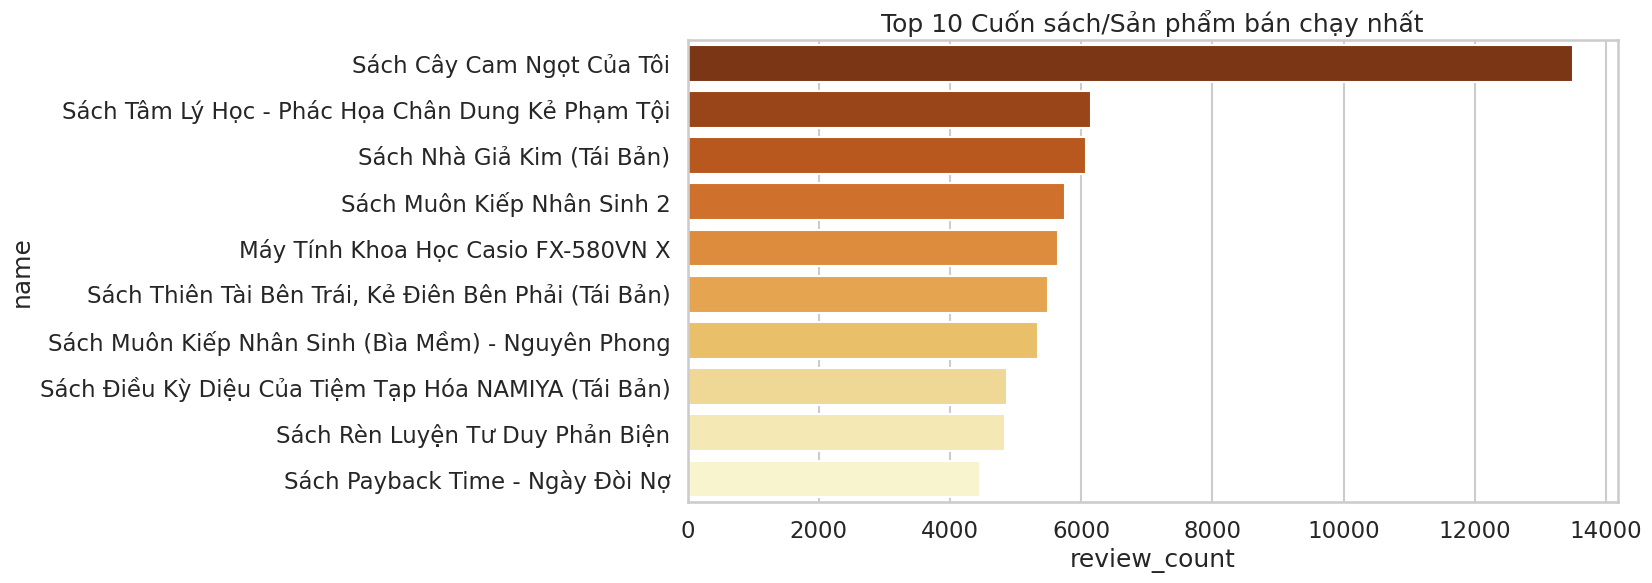

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\864511115.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='rocket')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\864511115.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\864511115.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_rating

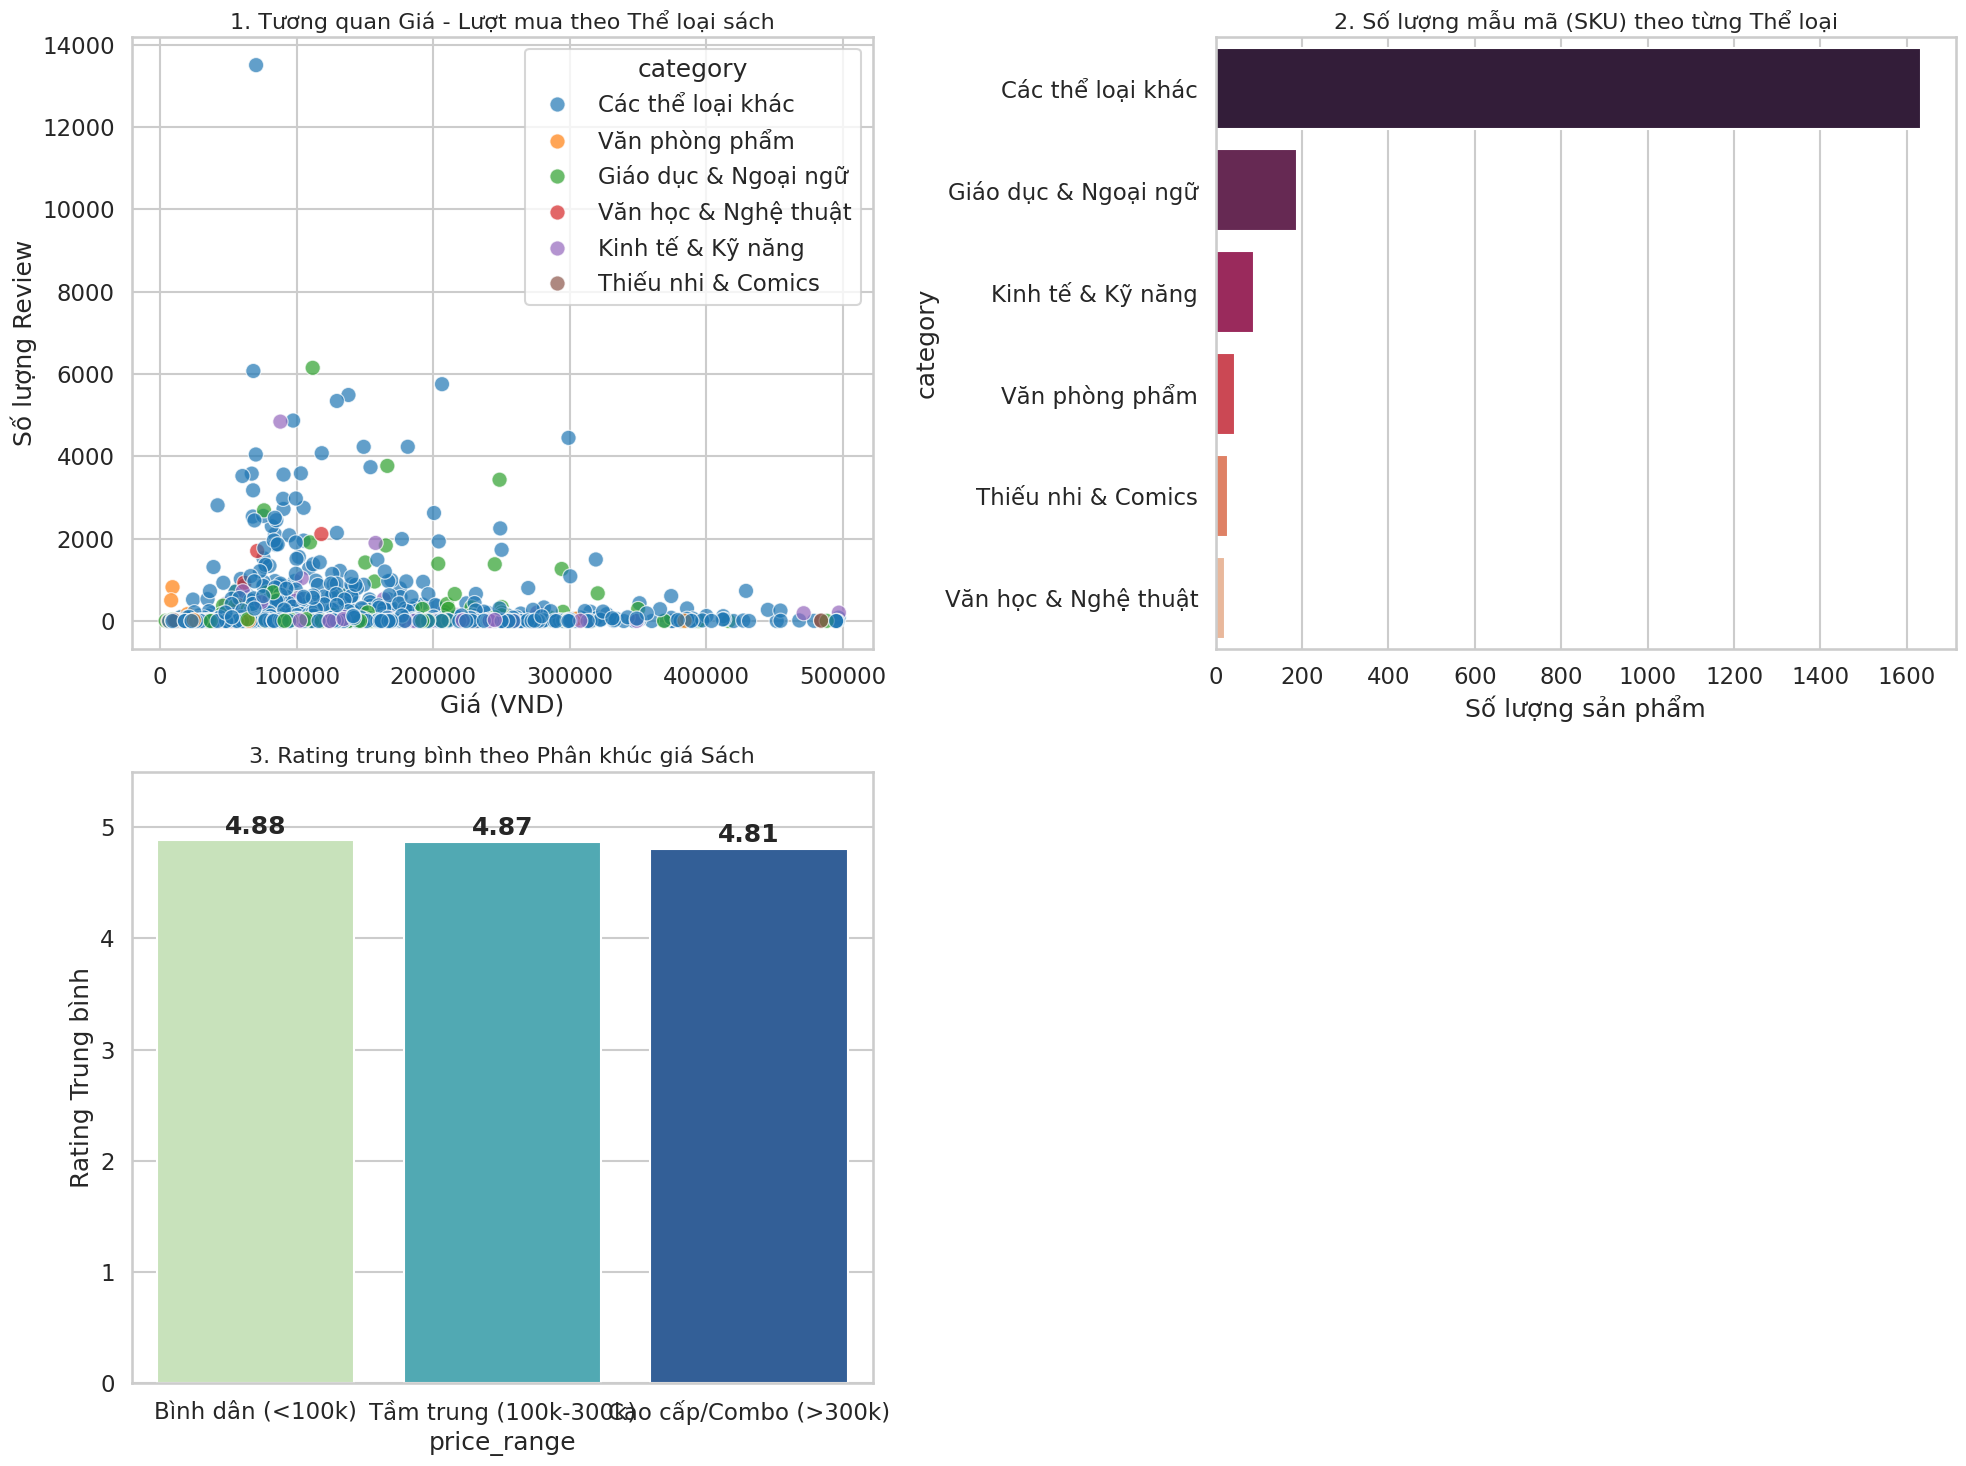

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện chuẩn Dashboard
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_nha_sach_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH NHÀ SÁCH ---
def categorize_books(name):
    name = str(name).lower()
    if any(k in name for k in ['kinh tế', 'kinh doanh', 'kỹ năng', 'tư duy', 'lãnh đạo']): return 'Kinh tế & Kỹ năng'
    if any(k in name for k in ['thiếu nhi', 'truyện tranh', 'manga', 'thần đồng', 'trẻ em']): return 'Thiếu nhi & Comics'
    if any(k in name for k in ['tiếng anh', 'ngoại ngữ', 'giáo trình', 'học', 'từ điển']): return 'Giáo dục & Ngoại ngữ'
    if any(k in name for k in ['văn học', 'tiểu thuyết', 'ngôn tình', 'trinh thám', 'thơ']): return 'Văn học & Nghệ thuật'
    if any(k in name for k in ['bút', 'vở', 'giấy', 'dụng cụ', 'thiệp']): return 'Văn phòng phẩm'
    return 'Các thể loại khác'

df['category'] = df['name'].apply(categorize_books)

# Phân khúc giá thực tế cho Sách
bins = [0, 100000, 300000, float('inf')]
labels = ['Bình dân (<100k)', 'Tầm trung (100k-300k)', 'Cao cấp/Combo (>300k)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df[df['price'] < 1000000]['price'], kde=True, color='chocolate')
plt.title('Price Distribution (< 1tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='teal')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='gold')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='darkred')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='darkgreen')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 500000], alpha=0.3, color='chocolate')
plt.title('Price vs Rating')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3, color='darkred')
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='YlOrBr_r')
plt.title('Top 10 Cuốn sách/Sản phẩm bán chạy nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (HOÀN THIỆN DASHBOARD)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Nhóm (Xác định "Dòng sách thị trường")
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 500000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Tương quan Giá - Lượt mua theo Thể loại sách', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: Cơ cấu SKU (Danh mục sách đang tập trung vào đâu?)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='rocket')
plt.title('2. Số lượng mẫu mã (SKU) theo từng Thể loại', fontsize=16)
plt.xlabel('Số lượng sản phẩm')

# Biểu đồ 3: Sự hài lòng (Rating) theo Phân khúc giá sách
plt.subplot(2, 2, 3)
# Lọc các sản phẩm có dữ liệu đánh giá thực tế (review > 5 để tránh nhiễu)
valid_df = df[df['review_count'] > 5]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='YlGnBu')

# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá Sách', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()

9.thời trang nữ

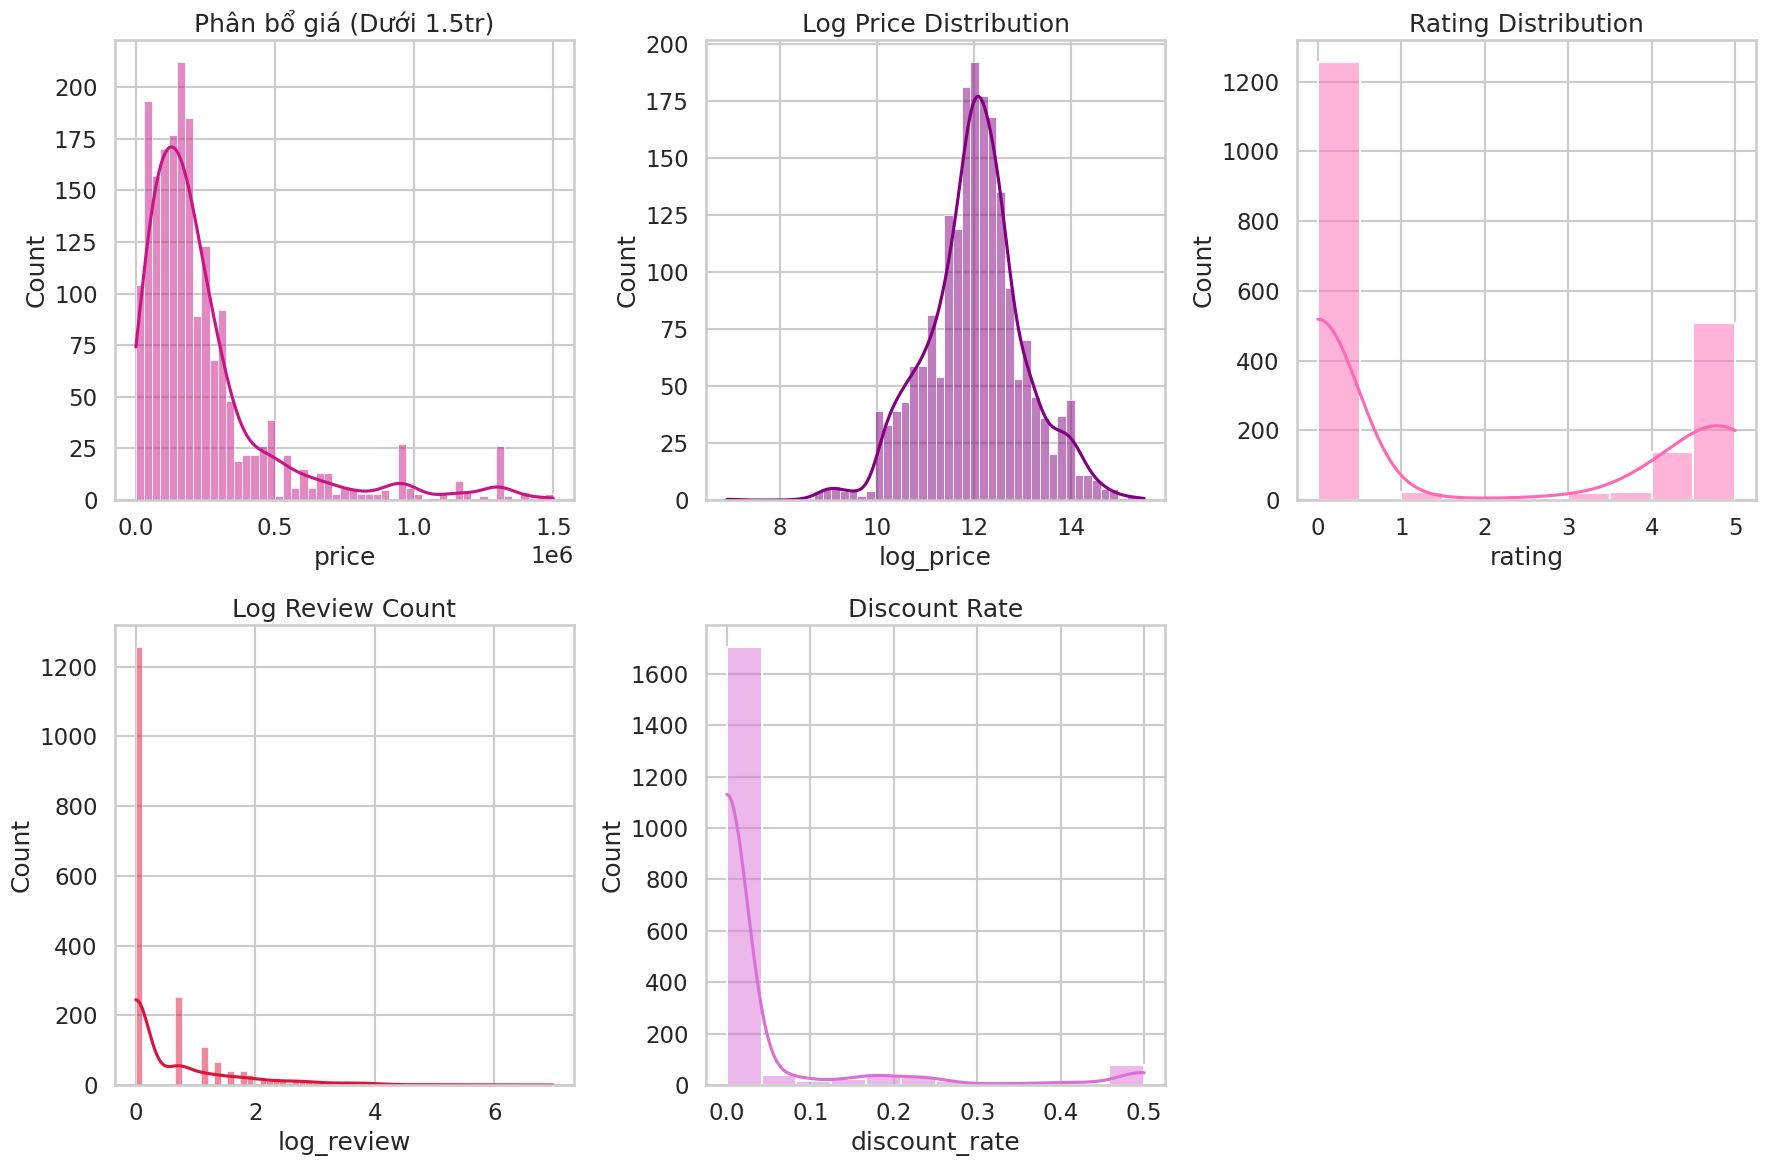

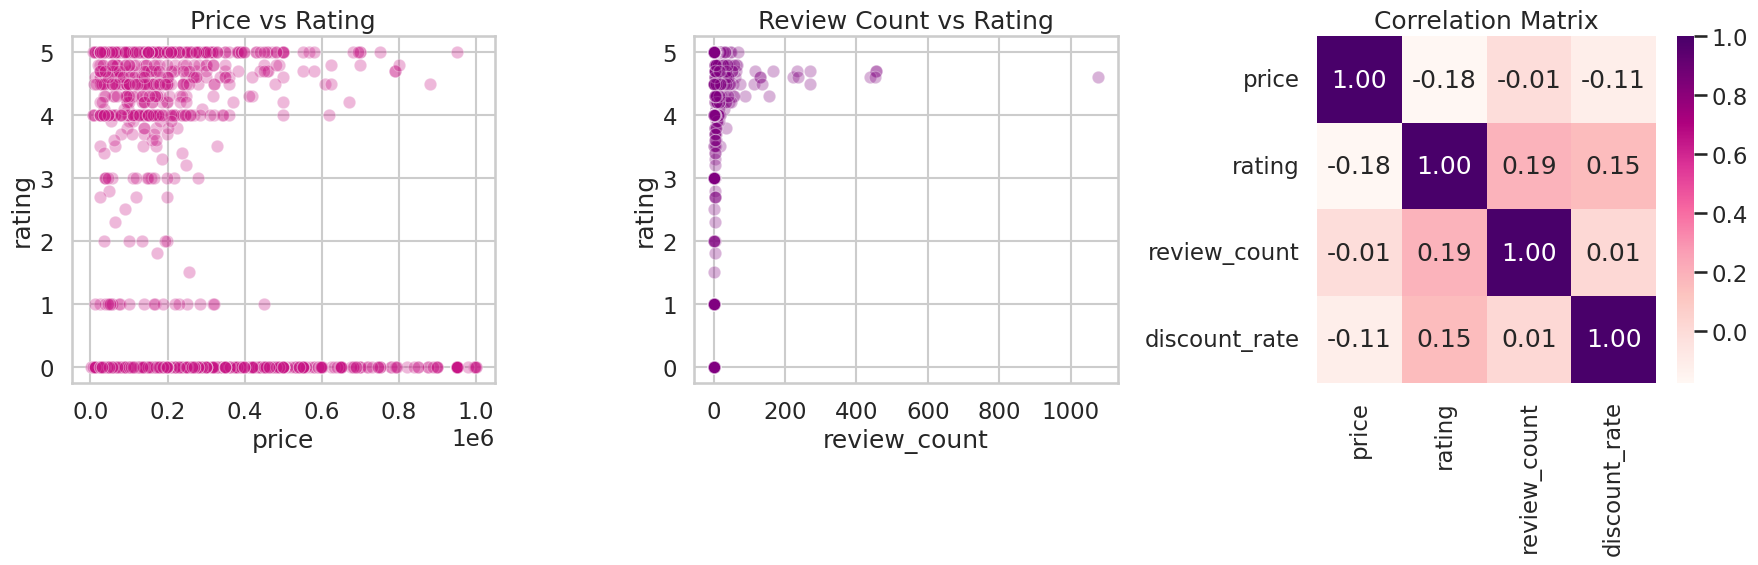

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1647474918.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_count', y='name', data=top_popular, palette='RdPu_r')


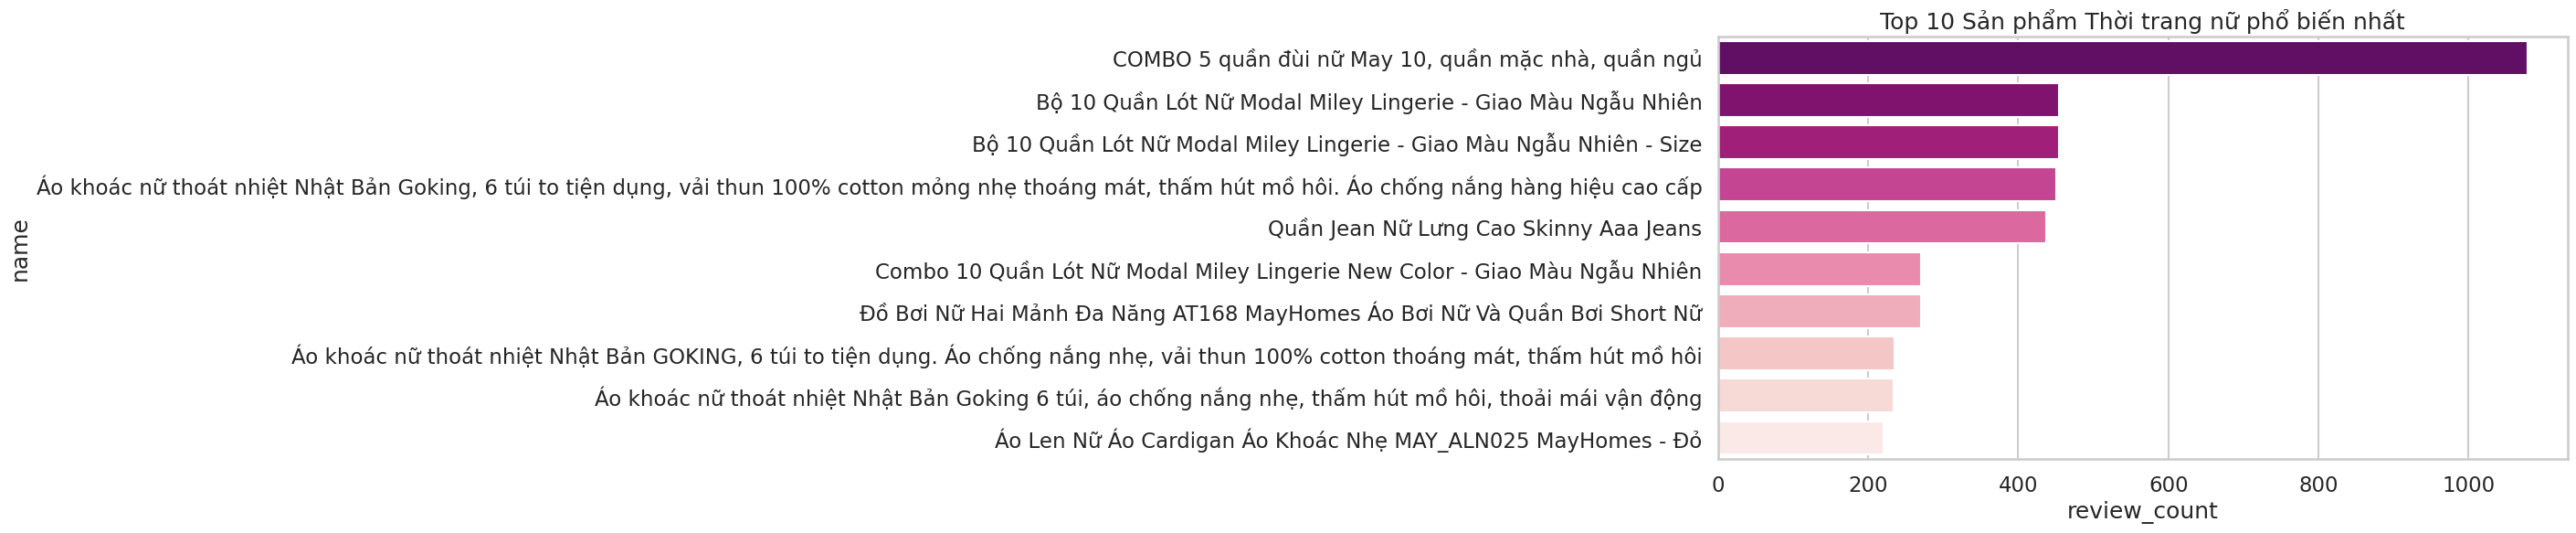

C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1647474918.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='spring')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1647474918.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17872\1647474918.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot3 = sns.barplot(data=avg_rat

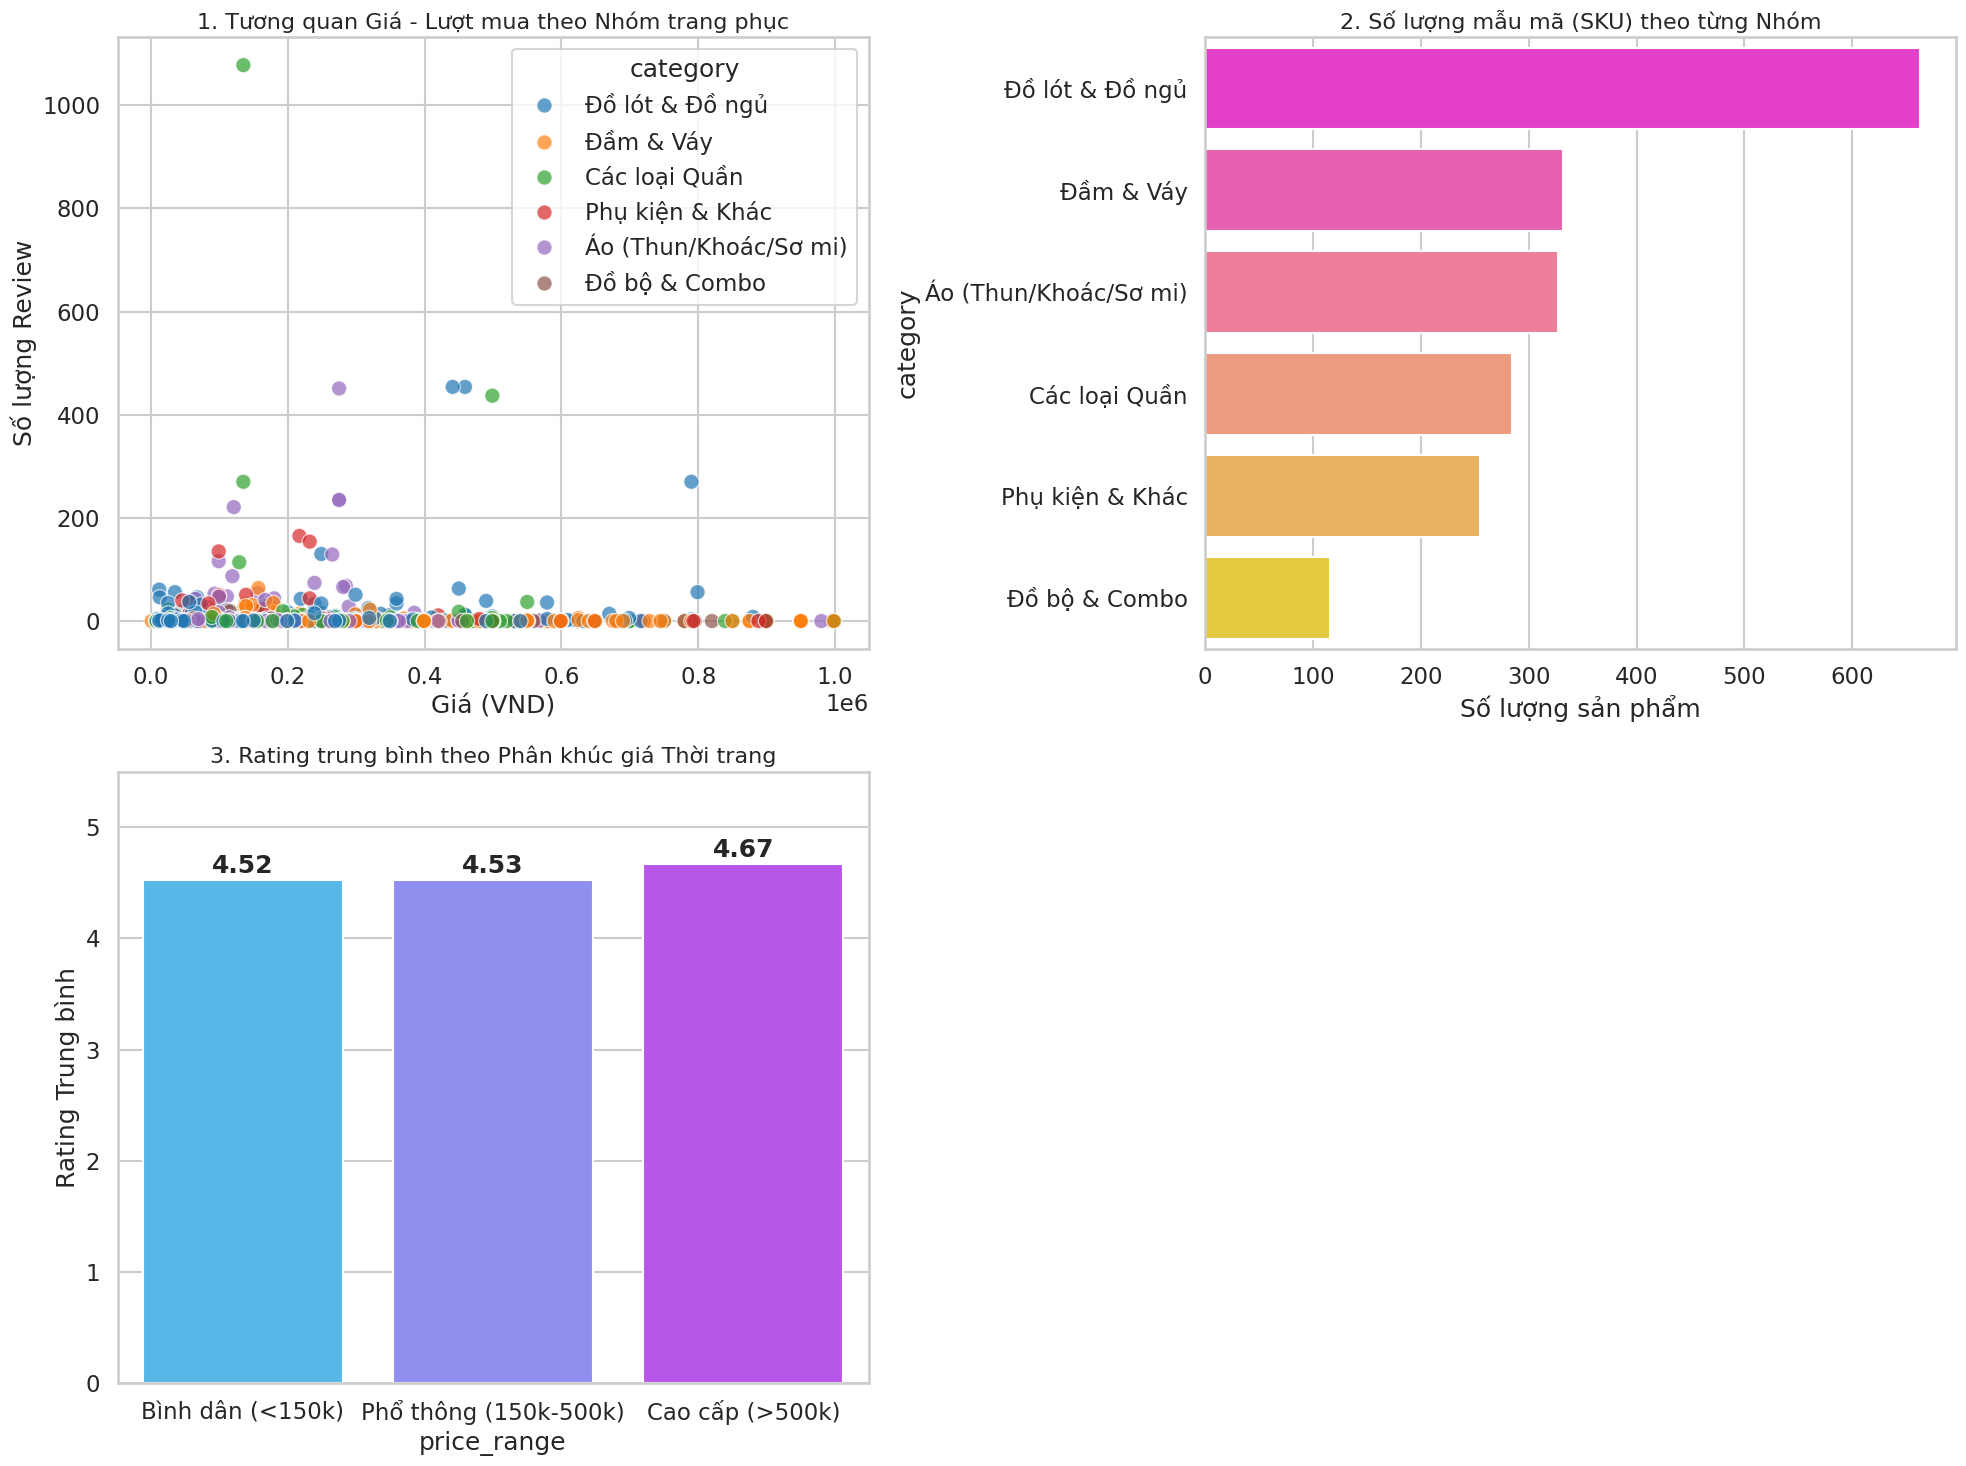

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện chuẩn Dashboard
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU
file_path = 'tiki_thoi_trang_nu_cleaned_final.csv'
df = pd.read_csv(file_path)

# Tính toán các chỉ số bổ sung
df['discount_rate'] = df['discount'] / df['original_price']
df['log_price'] = np.log1p(df['price'])
df['log_review'] = np.log1p(df['review_count'])

# --- PHÂN LOẠI CHIẾN LƯỢC CHO NGÀNH THỜI TRANG NỮ ---
def categorize_fashion(name):
    name = str(name).lower()
    if any(k in name for k in ['ngực', 'lót', 'lingerie', 'miley', 'bra', 'v-care']): return 'Đồ lót & Đồ ngủ'
    if any(k in name for k in ['quần', 'jeans', 'short', 'culottes']): return 'Các loại Quần'
    if any(k in name for k in ['áo thun', 'áo khoác', 'sơ mi', 't-shirt']): return 'Áo (Thun/Khoác/Sơ mi)'
    if any(k in name for k in ['đầm', 'váy', 'skirt', 'dress']): return 'Đầm & Váy'
    if any(k in name for k in ['combo', 'set', 'bộ']): return 'Đồ bộ & Combo'
    return 'Phụ kiện & Khác'

df['category'] = df['name'].apply(categorize_fashion)

# Phân khúc giá thực tế cho Thời trang nữ
bins = [0, 150000, 500000, float('inf')]
labels = ['Bình dân (<150k)', 'Phổ thông (150k-500k)', 'Cao cấp (>500k)']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

# ---------------------------------------------------------
# 2. CÁC BIỂU ĐỒ PHÂN BỔ (CƠ BẢN)
# ---------------------------------------------------------
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.histplot(df[df['price'] < 1500000]['price'], kde=True, color='mediumvioletred')
plt.title('Phân bổ giá (Dưới 1.5tr)')

plt.subplot(2, 3, 2)
sns.histplot(df['log_price'], kde=True, color='purple')
plt.title('Log Price Distribution')

plt.subplot(2, 3, 3)
sns.histplot(df['rating'], bins=10, kde=True, color='hotpink')
plt.title('Rating Distribution')

plt.subplot(2, 3, 4)
sns.histplot(df['log_review'], kde=True, color='crimson')
plt.title('Log Review Count')

plt.subplot(2, 3, 5)
sns.histplot(df['discount_rate'].dropna(), kde=True, color='orchid')
plt.title('Discount Rate')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BIỂU ĐỒ TƯƠNG QUAN & TOP SẢN PHẨM
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='price', y='rating', data=df[df['price'] < 1000000], alpha=0.3, color='mediumvioletred')
plt.title('Price vs Rating')

plt.subplot(1, 3, 2)
sns.scatterplot(x='review_count', y='rating', data=df, alpha=0.3, color='purple')
plt.title('Review Count vs Rating')

plt.subplot(1, 3, 3)
sns.heatmap(df[['price', 'rating', 'review_count', 'discount_rate']].corr(), annot=True, cmap='RdPu', fmt=".2f")
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Top 10 Popular
top_popular = df.sort_values('review_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='review_count', y='name', data=top_popular, palette='RdPu_r')
plt.title('Top 10 Sản phẩm Thời trang nữ phổ biến nhất')
plt.show()

# ---------------------------------------------------------
# 4. BA BIỂU ĐỒ CHIẾN LƯỢC (ĐÁNH GIÁ CHUYÊN SÂU)
# ---------------------------------------------------------
plt.figure(figsize=(20, 15))

# Biểu đồ 1: Price vs Review theo Nhóm (Tìm "Vùng giá hái ra tiền" của từng loại)
plt.subplot(2, 2, 1)
sns.scatterplot(data=df[df['price'] < 1000000], x='price', y='review_count', hue='category', alpha=0.7, s=120)
plt.title('1. Tương quan Giá - Lượt mua theo Nhóm trang phục', fontsize=16)
plt.xlabel('Giá (VND)')
plt.ylabel('Số lượng Review')

# Biểu đồ 2: SKU Distribution (Sự đa dạng của danh mục)
plt.subplot(2, 2, 2)
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='spring')
plt.title('2. Số lượng mẫu mã (SKU) theo từng Nhóm', fontsize=16)
plt.xlabel('Số lượng sản phẩm')

# Biểu đồ 3: Rating trung bình theo Phân khúc giá
plt.subplot(2, 2, 3)
# Lọc bỏ sản phẩm chưa có review để số liệu Rating chuẩn hơn
valid_df = df[df['review_count'] > 3]
avg_rating_price = valid_df.groupby('price_range')['rating'].mean().reset_index()
plot3 = sns.barplot(data=avg_rating_price, x='price_range', y='rating', palette='cool')

# Hiển thị số liệu trực tiếp
for p in plot3.patches:
    plot3.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 10), 
                   textcoords = 'offset points',
                   fontweight='bold')
plt.ylim(0, 5.5)
plt.title('3. Rating trung bình theo Phân khúc giá Thời trang', fontsize=16)
plt.ylabel('Rating Trung bình')

plt.tight_layout()
plt.show()